# The Simplex Method — Documented Implementation & Visual Companion
*Companion notebook to the lecture **“Simplex Method”** (Dr. Islam Ali)*

This notebook documents **every concept in the lecture** and implements it in Python, with visualisations wherever they help and a **PDF report exporter** for every solved problem.

| § | Lecture topic | What the notebook does |
|---|---|---|
| 1 | Introduction — why the graphical method is not enough | Growth of the number of basic solutions with problem size |
| 2 | LP terminologies (feasible / infeasible / basic solution, extreme point, optimum) | Enumerates **all basic solutions**, plots them on the feasible region |
| 3 | Steps of the simplex process | Decision diagram, run-time narration |
| 4 | Standard LP form: Type I / Type II inequalities, slack, surplus, artificial variables, Big-M objective, minimisation | `standardize()` + LaTeX rendering + coefficient-matrix chart |
| 5 | Example 1 — converting a model | Conversion step by step (and solved in 3-D as an extension) |
| 6 | Example 2 — tabular simplex | Every tableau of slides 18–57: entering variable, ratio test, pivot, scaling, elimination, optimality check |
| 7 | Example 3 — Big-M with an artificial variable | The Big-M preparation step and the iterations of slides 62–75 |
| 8 | Summary — optimal / unbounded / infeasible | One data file per branch of the diagram (+ minimisation and alternative optima) |
| 9 | Practice problems & batch processing | 3- and 4-variable models, all reports exported in one go |

**Folder layout**
```
Simplex_Method.ipynb
data/      ← input problems (.json, and a .csv example)
reports/   ← PDF reports written by export_pdf_report()
```

**Input file format (JSON)** — one file per problem:
```json
{
  "name": "Lecture Example 2 - Tabular Simplex",
  "sense": "max",
  "variables": ["X1", "X2"],
  "objective": [20, 10],
  "constraints": [
    {"name": "C1", "coefficients": [1, -1], "type": "<=", "rhs": 1},
    {"name": "C2", "coefficients": [3,  1], "type": "<=", "rhs": 7}
  ]
}
```
`type` accepts `<=`, `>=` or `=`. The **CSV format** (handy from Excel) has the header `row, X1, X2, …, type, rhs`; its first data row is `objective, c1, c2, …, max|min,` — see `data/ex2_tabular_simplex.csv`.

> Run the notebook top-to-bottom (*Kernel → Restart & Run All*). Requirements: `numpy pandas matplotlib scipy` (Jupyter provides `IPython`).

## 0. Setup
Imports, output folders and a shared colour code used by **every** chart and table:
<span style='color:#2563eb'>■ decision</span> &nbsp; <span style='color:#16a34a'>■ slack</span> &nbsp; <span style='color:#d97706'>■ surplus</span> &nbsp; <span style='color:#dc2626'>■ artificial</span>. In tableaux the <span style='background:#fff4c2'>pivot column</span>, <span style='background:#e0ecff'>pivot row</span> and <span style='background:#f59e0b;color:white'>pivot number</span> are highlighted and negative row-0 entries are red.

In [1]:
%matplotlib inline
import os, re, json, csv, math, itertools, textwrap, datetime, warnings
from fractions import Fraction
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Patch, Rectangle
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection
from scipy.spatial import ConvexHull
from scipy.optimize import linprog
from IPython.display import display, Markdown, HTML

warnings.filterwarnings("ignore", category=UserWarning)

DATA_DIR = "data"          # input problem files (.json / .csv)
REPORT_DIR = "reports"     # PDF reports are written here
os.makedirs(REPORT_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})

# One colour per variable *kind* - reused by every chart and table
KIND_COLORS = {"decision": "#2563eb", "slack": "#16a34a", "surplus": "#d97706", "artificial": "#dc2626"}
KIND_TINTS  = {"decision": "#dbeafe", "slack": "#dcfce7", "surplus": "#fef3c7", "artificial": "#fee2e2"}
PIVOT_COL, PIVOT_ROW, PIVOT_CELL = "#fff4c2", "#e0ecff", "#f59e0b"
INK, MUTED, GOOD, BAD = "#1f2937", "#6b7280", "#16a34a", "#dc2626"
PAGE = (11.69, 8.27)       # A4 landscape (inches) for PDF pages

### 0.1 Exact arithmetic and Big-M numbers
Tableau work by hand uses fractions (¼, −¾…). To reproduce the slides exactly the solver uses Python `Fraction`s — no rounding error.

In the Big-M method some row-0 entries look like **−4 − 2M**. We store every such value as a pair *(constant, M-part)*. Because M is “arbitrarily large”, two values are compared by their **M-part first**, then by the constant (`mkey`).

In [2]:
def to_frac(v):
    """Exact rational conversion (0.1 -> 1/10, not the binary float)."""
    if isinstance(v, Fraction):
        return v
    if isinstance(v, (int, np.integer)):
        return Fraction(int(v))
    return Fraction(str(v))

def fnum(x, digits=4):
    """Format a number the way the lecture tables do (7, 0.25, -2.5, 0.3333)."""
    x = Fraction(x)
    if x.denominator == 1:
        return str(x.numerator)
    s = f"{float(x):.{digits}f}".rstrip("0").rstrip(".")
    return "0" if s in ("-0", "") else s

def fM(c, m, digits=4):
    """Format a Big-M value  c + m*M  (e.g. -4-2M, 2+M, -6M)."""
    c, m = Fraction(c), Fraction(m)
    if m == 0:
        return fnum(c, digits)
    mp = "M" if m == 1 else "-M" if m == -1 else fnum(m, digits) + "M"
    if c == 0:
        return mp
    return fnum(c, digits) + (mp if mp.startswith("-") else "+" + mp)

def mkey(c, m):
    """Ordering key for c + m*M with M arbitrarily large: compare M-part first."""
    return (Fraction(m), Fraction(c))

In [3]:
print(fnum(Fraction(-3, 4)), fnum(Fraction(1, 3)), fM(-4, -2), fM(2, 1), fM(0, -6))
# ordering: -4-2M is 'more negative' than -3-M because its M-part is smaller
print(mkey(-4, -2) < mkey(-3, -1))

-0.75 0.3333 -4-2M 2+M -6M
True


## 1. Introduction — why the Simplex method?

* The **graphical method** only works for models with **at most two decision variables** (three with difficulty).
* Practical models have many variables, so we need an **analytical, algebraic** method.
* The **Simplex method** is an algorithm (a sequence of steps) developed by **George Dantzig in the late 1940s**; most computer LP packages use it — but it is **not the only method** (interior-point methods are another family).

**Why not simply check every corner?** With *n* decision variables and *m* constraints, the standard form has *n + m* variables and every choice of *m* basic variables is a candidate *basic solution*: up to $\binom{n+m}{m}$ of them. The chart in §2.13 shows how fast that number explodes, compared with the handful of tableaux the simplex method actually visits on the lecture's examples.

## 2. The library (defined once, used everywhere)
The next cells define the full toolkit. Each block is documented; the following sections *use* it to walk through the lecture.

### 2.1 Problem model and input files
`LPProblem` stores a model exactly as written; `load_problem()` reads `.json` or `.csv` files from `data/`.

In [4]:
_TYPE_MAP = {"<=": "<=", "<": "<=", "≤": "<=", "=<": "<=",
             ">=": ">=", ">": ">=", "≥": ">=", "=>": ">=",
             "=": "=", "==": "="}

@dataclass
class LPProblem:
    """A linear program exactly as the modeller writes it."""
    name: str
    sense: str                 # 'max' or 'min'
    variables: list            # decision-variable names, e.g. ['X1','X2']
    c: list                    # objective coefficients
    A: list                    # constraint coefficient rows
    types: list                # '<=', '>=', '='
    b: list                    # right-hand sides
    constraint_names: list = None
    description: str = ""
    source: str = ""

    def __post_init__(self):
        self.sense = self.sense.strip().lower()[:3]
        assert self.sense in ("max", "min"), "sense must be 'max' or 'min'"
        self.c = [to_frac(v) for v in self.c]
        self.A = [[to_frac(v) for v in row] for row in self.A]
        self.b = [to_frac(v) for v in self.b]
        self.types = [_TYPE_MAP[t.strip()] for t in self.types]
        if not self.constraint_names:
            self.constraint_names = [f"C{i+1}" for i in range(len(self.b))]
        assert all(len(r) == len(self.c) for r in self.A), "every row needs one coefficient per variable"
        assert len(self.A) == len(self.b) == len(self.types)

    @property
    def n(self): return len(self.c)
    @property
    def m(self): return len(self.b)

    def c_float(self): return np.array([float(v) for v in self.c])
    def A_float(self): return np.array([[float(v) for v in r] for r in self.A])
    def b_float(self): return np.array([float(v) for v in self.b])


def problem_from_dict(d, source=""):
    cons = d["constraints"]
    return LPProblem(name=d.get("name", "LP model"), sense=d.get("sense", "max"),
                     variables=d["variables"], c=d["objective"],
                     A=[k["coefficients"] for k in cons], types=[k["type"] for k in cons],
                     b=[k["rhs"] for k in cons],
                     constraint_names=[k.get("name", f"C{i+1}") for i, k in enumerate(cons)],
                     description=d.get("description", ""), source=source)

def load_problem_json(path):
    with open(path, encoding="utf-8") as f:
        return problem_from_dict(json.load(f), source=path)

def load_problem_csv(path):
    """CSV layout:  row, <var1>, <var2>, ..., type, rhs
       first data row = 'objective' with type 'max'/'min'; each further row is a constraint."""
    with open(path, newline="", encoding="utf-8") as f:
        rows = [r for r in csv.reader(f) if r and any(x.strip() for x in r)]
    header = [h.strip() for h in rows[0]]
    variables = header[1:-2]
    obj = rows[1]
    d = {"name": os.path.splitext(os.path.basename(path))[0].replace("_", " ").title(),
         "sense": obj[-2].strip(), "variables": variables,
         "objective": [x.strip() or "0" for x in obj[1:-2]], "constraints": []}
    for r in rows[2:]:
        d["constraints"].append({"name": r[0].strip(), "coefficients": [x.strip() or "0" for x in r[1:-2]],
                                 "type": r[-2].strip(), "rhs": r[-1].strip()})
    return problem_from_dict(d, source=path)

def load_problem(path):
    ext = os.path.splitext(path)[1].lower()
    if ext == ".json":
        return load_problem_json(path)
    if ext == ".csv":
        return load_problem_csv(path)
    raise ValueError(f"Unsupported file type: {ext}")

# ---------- pretty printing of linear expressions ----------
def _latex_var(name):
    m = re.fullmatch(r"([A-Za-z]+)(\d+)", name)
    return f"{m.group(1)}_{{{m.group(2)}}}" if m else r"\text{" + name + "}"

def lin_expr(coefs, names, latex=False, mcoefs=None):
    """Build '20X1 + 10X2 - MX6' style text (or LaTeX)."""
    terms = []
    mcoefs = mcoefs if mcoefs is not None else [0] * len(coefs)
    for a, am, v in zip(coefs, mcoefs, names):
        a, am = Fraction(a), Fraction(am)
        if a == 0 and am == 0:
            continue
        vv = _latex_var(v) if latex else v
        if am != 0:        # Big-M term
            sign = "-" if am < 0 else "+"
            mag = abs(am)
            coef = ("" if mag == 1 else fnum(mag)) + "M"
            terms.append((sign, coef + (r"\," if latex else "") + vv))
            continue
        sign = "-" if a < 0 else "+"
        mag = abs(a)
        coef = "" if mag == 1 else fnum(mag)
        terms.append((sign, coef + vv))
    if not terms:
        return "0"
    out = ("-" if terms[0][0] == "-" else "") + terms[0][1]
    for s, t in terms[1:]:
        out += f" {s} {t}"
    return out

_LATEX_REL = {"<=": r"\le", ">=": r"\ge", "=": "="}
_TEXT_REL = {"<=": "≤", ">=": "≥", "=": "="}

def problem_latex(p):
    lines = [rf"\text{{{'Maximize' if p.sense == 'max' else 'Minimize'}}}\quad & Z = {lin_expr(p.c, p.variables, True)} \\",
             r"\text{subject to}\quad & \\"]
    for row, t, b, nm in zip(p.A, p.types, p.b, p.constraint_names):
        lines.append(rf"& {lin_expr(row, p.variables, True)} {_LATEX_REL[t]} {fnum(b)} \qquad (\text{{{nm}}}) \\")
    lines.append(r"& " + ", ".join(_latex_var(v) for v in p.variables) + r" \ge 0")
    return r"$$\begin{aligned}" + "\n".join(lines) + r"\end{aligned}$$"

def problem_text(p):
    s = [f"{'Maximize' if p.sense == 'max' else 'Minimize'}  Z = {lin_expr(p.c, p.variables)}", "subject to"]
    w = max(len(n) for n in p.constraint_names)
    for row, t, b, nm in zip(p.A, p.types, p.b, p.constraint_names):
        s.append(f"   [{nm:<{w}}]  {lin_expr(row, p.variables)} {_TEXT_REL[t]} {fnum(b)}")
    s.append("   " + ", ".join(p.variables) + " ≥ 0")
    return "\n".join(s)

def show_problem(p):
    display(Markdown(f"**{p.name}**" + (f"  \n*{p.description}*" if p.description else "")))
    display(Markdown(problem_latex(p)))

### 2.2 Standard LP form (lecture slides 6–13)
Properties of the standard form: **all constraints are equations**, **all variables are non-negative**, objective max or min (we always **maximise**; a minimisation is multiplied by −1).

| Constraint | Lecture name | Conversion | Starting basic variable |
|---|---|---|---|
| $\sum a_jx_j \le b$ | **Type I** | $+\,S$ (slack: unused resource, cost 0) | the slack |
| $\sum a_jx_j \ge b$ | **Type II** | $-\,S$ (surplus, cost 0) $+\,R$ (artificial) | the artificial |
| $\sum a_jx_j = b$ | equation | $+\,R$ (artificial) | the artificial |

A surplus variable enters with coefficient −1, so setting the decision variables to 0 would make it negative — the **artificial variable** is “a truly artificial device employed to drive an immediately recognisable basic feasible solution”. It has **no physical meaning** and must be driven to zero, so it is penalised in the objective:

$$\text{Maximize } z=\underbrace{\sum_{j=1}^{n}c_jx_j}_{\text{original objective}}+\underbrace{\sum_{k=1}^{r}c_ks_k}_{c_k=0\ \text{(slack / surplus)}}+\underbrace{\sum_{p=1}^{t}c_pR_p}_{c_p=-M\ \text{(artificial)}}$$

**Naming.** Slide 12 uses $S$ and $R$; slide 13 renames everything as $X$'s. `naming="indexed"` (default) produces $X_{n+1}, X_{n+2},\dots$ with slack/surplus variables numbered in constraint order and artificials last (the convention of Examples 2 and 3); `naming="typed"` produces $S_1, S_2, R_1,\dots$.

In [5]:
@dataclass
class StandardForm:
    problem: LPProblem
    names: list        # all column names (decision + slack/surplus + artificial)
    kinds: list        # 'decision' | 'slack' | 'surplus' | 'artificial'
    roles: list        # human description, e.g. 'surplus of C1'
    A: np.ndarray      # m x N (Fractions)
    b: np.ndarray      # m     (Fractions, all >= 0)
    c: np.ndarray      # N objective coefficients in MAX form (constant part)
    cM: np.ndarray     # N objective coefficients multiplying M (-1 for artificials)
    basis: list        # initial basic column for each row
    obj_sign: int      # +1: original max ; -1: original min (we maximise -Z)
    steps: list        # explanation of every transformation (markdown)
    types: list        # constraint types after any RHS sign flip

    @property
    def m(self): return self.A.shape[0]
    @property
    def N(self): return self.A.shape[1]
    @property
    def n_dec(self): return self.problem.n
    def idx(self, kind): return [j for j, k in enumerate(self.kinds) if k == kind]


def standardize(p, naming="indexed"):
    """Convert an LPProblem into the Simplex standard form of the lecture.

    * every constraint -> equation     (slack for <=, surplus + artificial for >=, artificial for =)
    * every variable   -> non-negative
    * objective        -> maximisation (min Z  ==  max -Z), slack/surplus cost 0, artificial cost -M
    naming='indexed' continues X1..Xn as X(n+1), X(n+2)... (lecture slide 13);
    naming='typed' uses S1, S2 (slack/surplus) and R1, R2 (artificial) as on slide 12.
    """
    steps = []
    A = [list(r) for r in p.A]; b = list(p.b); types = list(p.types)
    for i in range(p.m):
        if b[i] < 0:
            A[i] = [-a for a in A[i]]; b[i] = -b[i]
            types[i] = {"<=": ">=", ">=": "<=", "=": "="}[types[i]]
            steps.append(f"Row **{p.constraint_names[i]}** had a negative RHS: multiplied by −1 "
                         f"(the inequality direction flips) so that every RHS is ≥ 0.")
    obj_sign = 1 if p.sense == "max" else -1
    if obj_sign == -1:
        steps.append("The objective is **minimisation** → multiply by −1 and **maximise** "
                     "Z′ = −Z (lecture slide 9). The final answer is converted back with Z = −Z′.")

    names = list(p.variables); kinds = ["decision"] * p.n; roles = ["decision variable"] * p.n
    m_ = re.fullmatch(r"([A-Za-z]+)(\d+)", p.variables[-1])
    use_idx = naming == "indexed" and m_ is not None and all(
        re.fullmatch(rf"{m_.group(1)}\d+", v) for v in p.variables)
    prefix = m_.group(1) if use_idx else None
    counter = [int(m_.group(2)) if use_idx else 0]
    s_cnt, r_cnt = [0], [0]

    def new_name(kind):
        if use_idx:
            counter[0] += 1
            return f"{prefix}{counter[0]}"
        if kind == "artificial":
            r_cnt[0] += 1; return f"R{r_cnt[0]}"
        s_cnt[0] += 1; return f"S{s_cnt[0]}"

    cols = [[A[i][j] for i in range(p.m)] for j in range(p.n)]
    basis = [None] * p.m
    art_rows = []
    # pass 1: slack / surplus in constraint order
    for i, t in enumerate(types):
        cname = p.constraint_names[i]
        if t == "<=":
            names.append(new_name("slack")); kinds.append("slack"); roles.append(f"slack of {cname}")
            cols.append([Fraction(int(k == i)) for k in range(p.m)]); basis[i] = len(names) - 1
            steps.append(f"**{cname}** (Type I, ≤): add slack **{names[-1]}** ≥ 0 (unused resource, cost 0) "
                         f"→ {names[-1]} is the starting basic variable of this row.")
        elif t == ">=":
            names.append(new_name("surplus")); kinds.append("surplus"); roles.append(f"surplus of {cname}")
            cols.append([Fraction(-int(k == i)) for k in range(p.m)]); art_rows.append(i)
            steps.append(f"**{cname}** (Type II, ≥): subtract surplus **{names[-1]}** ≥ 0 (cost 0). "
                         f"Its column is −1, so it cannot start in the basis → an artificial variable is needed.")
        else:
            art_rows.append(i)
            steps.append(f"**{cname}** (=): already an equation, but it has no obvious basic variable → an artificial variable is needed.")
    # pass 2: artificials (numbered after all slack/surplus variables, as in Example 3)
    for i in art_rows:
        cname = p.constraint_names[i]
        names.append(new_name("artificial")); kinds.append("artificial"); roles.append(f"artificial of {cname}")
        cols.append([Fraction(int(k == i)) for k in range(p.m)]); basis[i] = len(names) - 1
        steps.append(f"**{cname}**: add artificial **{names[-1]}** ≥ 0 with objective coefficient **−M** "
                     f"(huge penalty) → it provides an immediately recognisable starting basic variable.")

    N = len(names)
    Am = np.array([[cols[j][i] for j in range(N)] for i in range(p.m)], dtype=object)
    bm = np.array(b, dtype=object)
    c = np.array([obj_sign * p.c[j] if j < p.n else Fraction(0) for j in range(N)], dtype=object)
    cM = np.array([Fraction(-1) if k == "artificial" else Fraction(0) for k in kinds], dtype=object)
    return StandardForm(p, names, kinds, roles, Am, bm, c, cM, basis, obj_sign, steps, types)


def standard_form_latex(sf):
    p = sf.problem
    zname = "Z" if sf.obj_sign == 1 else "Z'"
    lines = [rf"\text{{Maximize}}\quad & {zname} = {lin_expr(sf.c, sf.names, True, sf.cM)} \\",
             r"\text{subject to}\quad & \\"]
    for i in range(sf.m):
        lines.append(rf"& {lin_expr(sf.A[i], sf.names, True)} = {fnum(sf.b[i])} \qquad (\text{{{p.constraint_names[i]}}}) \\")
    lines.append(r"& " + ", ".join(_latex_var(v) for v in sf.names) + r" \ge 0")
    return r"$$\begin{aligned}" + "\n".join(lines) + r"\end{aligned}$$"

def standard_form_text(sf):
    zname = "Z" if sf.obj_sign == 1 else "Z'"
    s = [f"Maximize  {zname} = {lin_expr(sf.c, sf.names, False, sf.cM)}", "subject to"]
    for i in range(sf.m):
        s.append(f"   {lin_expr(sf.A[i], sf.names)} = {fnum(sf.b[i])}")
    s.append("   " + ", ".join(sf.names) + " ≥ 0")
    return "\n".join(s)

def variable_table(sf):
    return pd.DataFrame({"Variable": sf.names, "Kind": sf.kinds, "Role": sf.roles,
                         "Objective coef.": [fM(c, m) for c, m in zip(sf.c, sf.cM)],
                         "Starts basic?": ["yes" if j in sf.basis else "" for j in range(sf.N)]})

def show_standard_form(sf):
    display(Markdown("#### Transformation steps\n" + "\n".join(f"{i+1}. {s}" for i, s in enumerate(sf.steps))))
    display(Markdown("#### Standard form" + standard_form_latex(sf)))
    styled = variable_table(sf).style.apply(
        lambda col: [f"background-color:{KIND_TINTS[k]}" for k in sf.kinds], subset=["Variable", "Kind"]).hide(axis="index")
    display(styled)

### 2.3 The tabular Simplex (Big-M) solver
Row 0 of the tableau is the objective written as an equation, $Z-\sum_j c_jx_j=0$. One iteration (slides 18–57):

1. **Optimality check** — if row 0 has **no negative coefficient**, stop.
2. **Entering basic variable** — the variable with the **largest (in absolute value) negative coefficient** in row 0 (Dantzig's rule).
3. **Leaving basic variable** — **minimum ratio test**: RHS ÷ the *positive* entries of the pivot column (negative → “−ve”, zero → “∞”, both excluded).
4. **Pivot** — scale the pivot row so the pivot number becomes 1, then **eliminate** the entering variable from every other row (including row 0) with row operations.

Big-M extra step: artificial basic variables start with coefficient **M** in row 0; subtracting *M × their row* zeroes them (slide 62–63) *before* the first optimality test.

Every intermediate tableau is stored as a `Snapshot` so it can be displayed, plotted and exported. `rule="bland"` switches to Bland's lowest-index rule, a standard safeguard against cycling in degenerate problems.

In [6]:
@dataclass
class Snapshot:
    """A frozen copy of the tableau at one moment of the algorithm."""
    stage: str            # initial | bigM | select | scaled | pivoted | final
    iteration: int
    T: np.ndarray         # constraint rows (m x N)
    rhs: np.ndarray
    r0c: np.ndarray       # row-0 coefficients, constant part
    r0m: np.ndarray       # row-0 coefficients, M part
    z0c: Fraction         # row-0 RHS (= current Z), constant part
    z0m: Fraction         # row-0 RHS, M part
    basis: list
    entering: int = None
    leaving_row: int = None
    ratios: list = None
    ops: list = field(default_factory=list)
    note: str = ""

    def x(self, N):
        v = np.array([Fraction(0)] * N, dtype=object)
        for i, j in enumerate(self.basis):
            v[j] = self.rhs[i]
        return v


@dataclass
class SimplexResult:
    problem: LPProblem
    sf: StandardForm
    status: str                   # optimal | unbounded | infeasible | iteration_limit
    snapshots: list
    iterations: int
    rule: str
    x: dict = None                # all variables -> value
    z: Fraction = None            # objective value in the ORIGINAL sense
    alt_optima: list = None
    unbounded_var: str = None
    messages: list = field(default_factory=list)

    @property
    def x_decision(self):
        return {v: self.x[v] for v in self.problem.variables}

    def bfs_history(self):
        """Basic feasible solutions visited: list of (label, snapshot)."""
        out = []
        for s in self.snapshots:
            if s.stage in ("pivoted",) or (s.stage == "bigM") or (s.stage == "initial" and not any(t.stage == "bigM" for t in self.snapshots)):
                out.append(s)
        return out

    def summary(self):
        p = self.problem
        d = {"Problem": p.name, "Status": self.status.upper(), "Iterations": self.iterations}
        if self.status == "optimal":
            d["Z*"] = fnum(self.z)
            d.update({v: fnum(val) for v, val in self.x_decision.items()})
        return d


def simplex(problem, rule="dantzig", max_iter=50, naming="indexed", verbose=False):
    """Tabular (Big-M) Simplex exactly as in the lecture.

    rule='dantzig' : entering = most negative row-0 coefficient (lecture rule), ties -> lowest index
    rule='bland'   : entering = lowest-index negative coefficient (anti-cycling safeguard)
    Arithmetic uses exact fractions, so tableaux match hand calculations.
    """
    sf = problem if isinstance(problem, StandardForm) else standardize(problem, naming)
    p = sf.problem
    m, N = sf.A.shape
    T = sf.A.copy(); rhs = sf.b.copy()
    r0c = np.array([-v for v in sf.c], dtype=object)       # Z - sum c_j x_j = 0
    r0m = np.array([-v for v in sf.cM], dtype=object)      # artificial: -(-M) = +M
    z0c, z0m = Fraction(0), Fraction(0)
    basis = list(sf.basis)
    snaps = []

    def snap(stage, it, **kw):
        snaps.append(Snapshot(stage, it, T.copy(), rhs.copy(), r0c.copy(), r0m.copy(), z0c, z0m, list(basis), **kw))

    snap("initial", 0, note="Initial tableau: the slack (and artificial) variables form the starting basis; "
                            "decision variables are non-basic (= 0).")
    # ---- Big-M preparation: basic variables must have 0 in row 0 ----
    ops = []
    for i, bv in enumerate(basis):
        fc, fm = r0c[bv], r0m[bv]
        if fc != 0 or fm != 0:
            r0c = r0c - fc * T[i]; r0m = r0m - fm * T[i]
            z0c -= fc * rhs[i]; z0m -= fm * rhs[i]
            ops.append(f"Subtract {fM(fc, fm)} × R{i+1} from R0  (make the coefficient of basic {sf.names[bv]} zero)")
    if ops:
        snap("bigM", 0, ops=ops, note="Big-M preparation: the artificial basic variable(s) had coefficient M in row 0. "
                                       "Subtracting M × their rows makes those coefficients zero, so row 0 is ready for the optimality test.")

    it, status, unb = 0, None, None
    while True:
        neg = [j for j in range(N) if mkey(r0c[j], r0m[j]) < (0, 0)]
        if not neg:
            art = [basis[i] for i in range(m) if sf.kinds[basis[i]] == "artificial" and rhs[i] > 0]
            status = "infeasible" if art else "optimal"
            break
        if it >= max_iter:
            status = "iteration_limit"; break
        e = min(neg) if rule == "bland" else min(neg, key=lambda j: (mkey(r0c[j], r0m[j]), j))
        ratios = [rhs[i] / T[i, e] if T[i, e] > 0 else None for i in range(m)]
        cand = [i for i in range(m) if ratios[i] is not None]
        if not cand:
            status, unb = "unbounded", e
            snap("select", it + 1, entering=e, ratios=ratios,
                 note=f"{sf.names[e]} could enter, but no coefficient in its column is positive → no ratio limits it.")
            break
        mr = min(ratios[i] for i in cand)
        ties = [i for i in cand if ratios[i] == mr]
        r = min(ties, key=lambda i: basis[i]) if rule == "bland" else ties[0]
        it += 1
        snap("select", it, entering=e, leaving_row=r, ratios=ratios)
        piv = T[r, e]
        T[r] = T[r] / piv; rhs[r] = rhs[r] / piv
        snap("scaled", it, entering=e, leaving_row=r, ratios=ratios,
             ops=[f"Divide R{r+1} by the pivot number {fnum(piv)}"] if piv != 1 else
                 ["Pivot number is already 1 - scaling not needed (normally divide the pivot row by the pivot number)"])
        ops = []
        fc, fm = r0c[e], r0m[e]
        if fc != 0 or fm != 0:
            neg_f = mkey(fc, fm) < (0, 0)
            txt = fM(-fc, -fm) if neg_f else fM(fc, fm)
            txt = f"({txt})" if (fm != 0 and fc != 0) else txt
            ops.append(f"{'Add' if neg_f else 'Subtract'} {txt} × R{r+1} {'to' if neg_f else 'from'} R0")
            r0c = r0c - fc * T[r]; r0m = r0m - fm * T[r]
            z0c -= fc * rhs[r]; z0m -= fm * rhs[r]
        for i in range(m):
            f = T[i, e]
            if i == r or f == 0:
                continue
            ops.append(f"{'Add' if f < 0 else 'Subtract'} {fnum(abs(f))} × R{r+1} {'to' if f < 0 else 'from'} R{i+1}")
            T[i] = T[i] - f * T[r]; rhs[i] = rhs[i] - f * rhs[r]
        leaving = basis[r]
        basis[r] = e
        snap("pivoted", it, entering=e, leaving_row=r, ops=ops,
             note=f"{sf.names[e]} replaced {sf.names[leaving]} in the basis.")
        if verbose:
            print(f"iter {it}: {sf.names[e]} enters, {sf.names[leaving]} leaves, Z = {fM(z0c, z0m)}")

    res = SimplexResult(p, sf, status, snaps, it, rule, unbounded_var=sf.names[unb] if unb is not None else None)
    last = snaps[-1]
    xv = last.x(N) if status != "unbounded" else Snapshot("x", 0, T, rhs, r0c, r0m, z0c, z0m, basis).x(N)
    res.x = {sf.names[j]: xv[j] for j in range(N)}
    zmax = sum(sf.c[j] * xv[j] for j in range(N))
    res.z = sf.obj_sign * zmax
    snaps.append(Snapshot("final", it, T.copy(), rhs.copy(), r0c.copy(), r0m.copy(), z0c, z0m, list(basis),
                          entering=unb, ratios=snaps[-1].ratios if status == "unbounded" else None))
    if status == "optimal":
        res.alt_optima = [sf.names[j] for j in range(N) if j not in basis and sf.kinds[j] != "artificial"
                          and r0c[j] == 0 and r0m[j] == 0]
        res.messages.append(f"Optimal: row 0 has no negative coefficients. Z* = {fnum(res.z)}"
                            + (" (converted back: Z = −Z′)" if sf.obj_sign == -1 else ""))
        if res.alt_optima:
            res.messages.append("Alternative optima: non-basic " + ", ".join(res.alt_optima) +
                                " has a zero coefficient in row 0 - bringing it in changes the solution but not Z.")
    elif status == "unbounded":
        res.messages.append(f"Unbounded: {res.unbounded_var} has a negative row-0 coefficient but every entry of its column is ≤ 0, "
                            "so it can increase forever while Z keeps improving.")
    elif status == "infeasible":
        arts = [sf.names[basis[i]] for i in range(m) if sf.kinds[basis[i]] == "artificial" and rhs[i] > 0]
        res.messages.append("Infeasible: row 0 has no negative values but artificial variable(s) "
                            + ", ".join(arts) + " remain in the basis at a positive level.")
    else:
        res.messages.append("Iteration limit reached (possible cycling - try rule='bland').")
    return res

### 2.4 Enumerating basic solutions (LP terminology, slide 4)
Choose *m* of the (non-artificial) standard-form variables as basic, set the others to 0 and solve the *m × m* system. Each nonsingular choice is a **basic solution**; it is a **basic feasible solution** — an **extreme point** — when all values are ≥ 0.

In [7]:
def _solve_exact(B, rhs):
    """Gauss-Jordan elimination with Fractions. Returns None if B is singular."""
    n = len(B)
    M = [list(B[i]) + [rhs[i]] for i in range(n)]
    for col in range(n):
        piv = next((r for r in range(col, n) if M[r][col] != 0), None)
        if piv is None:
            return None
        M[col], M[piv] = M[piv], M[col]
        pv = M[col][col]
        M[col] = [v / pv for v in M[col]]
        for r in range(n):
            if r != col and M[r][col] != 0:
                f = M[r][col]
                M[r] = [a - f * b for a, b in zip(M[r], M[col])]
    return [M[i][n] for i in range(n)]


def enumerate_basic_solutions(sf, limit=5000):
    """Every basic solution of the standard-form system (artificials excluded):
    choose m basic columns, set the rest to 0, solve.  Feasible ones = extreme points."""
    cols = [j for j in range(sf.N) if sf.kinds[j] != "artificial"]
    rows = []
    for count, combo in enumerate(itertools.combinations(cols, sf.m)):
        if count >= limit:
            break
        B = [[sf.A[i][j] for j in combo] for i in range(sf.m)]
        sol = _solve_exact(B, list(sf.b))
        if sol is None:
            continue
        x = {sf.names[j]: Fraction(0) for j in cols}
        for j, v in zip(combo, sol):
            x[sf.names[j]] = v
        feas = all(v >= 0 for v in sol)
        z = sf.obj_sign * sum(sf.c[j] * x[sf.names[j]] for j in cols)
        rows.append({"Basic variables": ", ".join(sf.names[j] for j in combo),
                     **{v: x[v] for v in sf.problem.variables},
                     "Feasible?": feas, "Z": z,
                     **{sf.names[j]: x[sf.names[j]] for j in cols if sf.kinds[j] != "decision"}})
    df = pd.DataFrame(rows)
    if len(df):
        feas = df[df["Feasible?"]]
        if len(feas):
            best = feas["Z"].max() if sf.problem.sense == "max" else feas["Z"].min()
            df["Optimal?"] = df["Feasible?"] & (df["Z"] == best)
        else:
            df["Optimal?"] = False
    return df

def show_basic_solutions(sf):
    df = enumerate_basic_solutions(sf)
    view = df.copy()
    for col in view.columns:
        if col not in ("Basic variables", "Feasible?", "Optimal?"):
            view[col] = view[col].map(fnum)
    def colour(row):
        c = "#dcfce7" if row["Optimal?"] else ("#f0fdf4" if row["Feasible?"] else "#fef2f2")
        return [f"background-color:{c}"] * len(row)
    display(view.style.apply(colour, axis=1).hide(axis="index"))
    return df

### 2.5 Tableau display (notebook)

In [8]:
def _ratio_text(s, i):
    if s.ratios is None or s.entering is None:
        return ""
    if s.ratios[i] is None:
        return "-ve" if s.T[i, s.entering] < 0 else "∞"
    return fnum(s.ratios[i])

def tableau_frame(s, sf, show_ratio=True):
    """The lecture's tableau layout as a DataFrame of strings."""
    cols = ["Basic", "Eq.", "Z"] + sf.names + ["RHS"]
    data = [["Z", 0, 1] + [fM(s.r0c[j], s.r0m[j]) for j in range(sf.N)] + [fM(s.z0c, s.z0m)]]
    for i in range(sf.m):
        data.append([sf.names[s.basis[i]], i + 1, 0] + [fnum(v) for v in s.T[i]] + [fnum(s.rhs[i])])
    df = pd.DataFrame(data, columns=cols)
    if show_ratio and s.ratios is not None:
        df["Ratio"] = [""] + [_ratio_text(s, i) for i in range(sf.m)]
    return df

def show_tableau(s, sf, caption=None):
    df = tableau_frame(s, sf)
    e, r = s.entering, s.leaving_row
    show_pivot = s.stage in ("select", "scaled") and e is not None

    def style(data):
        st = pd.DataFrame("", index=data.index, columns=data.columns)
        for j, name in enumerate(sf.names):
            st.loc[0, name] += "font-weight:bold;" if mkey(s.r0c[j], s.r0m[j]) < (0, 0) else ""
            st.loc[0, name] += "color:#dc2626;" if mkey(s.r0c[j], s.r0m[j]) < (0, 0) else ""
        st.loc[0, :] += "border-bottom:2px solid #555;"
        for i in range(sf.m):
            st.loc[i + 1, "Basic"] += f"background-color:{KIND_TINTS[sf.kinds[s.basis[i]]]};font-weight:bold;"
        if show_pivot:
            st[sf.names[e]] += f"background-color:{PIVOT_COL};"
            if r is not None:
                st.loc[r + 1, :] += f"background-color:{PIVOT_ROW};"
                st.loc[r + 1, sf.names[e]] = f"background-color:{PIVOT_CELL};font-weight:bold;color:white;"
                if "Ratio" in data.columns:
                    st.loc[r + 1, "Ratio"] += "font-weight:bold;color:#b45309;"
        return st

    sty = df.style.apply(style, axis=None).hide(axis="index")
    sty = sty.set_table_styles([{"selector": "th", "props": "background:#f3f4f6;text-align:center;"},
                                {"selector": "td", "props": "text-align:center;padding:4px 10px;"}])
    if caption:
        sty = sty.set_caption(caption)
    display(sty)

### 2.6 Tableau charts — row 0, ratio test

In [9]:
def draw_tableau(ax, s, sf, title=None, fontsize=None):
    """Render a tableau onto a matplotlib axis with lecture-style highlights."""
    df = tableau_frame(s, sf)
    ax.axis("off")
    ncol = df.shape[1]
    fs = fontsize or max(6.5, min(11, 120 / ncol))
    tb = ax.table(cellText=df.values.tolist(), colLabels=list(df.columns), loc="center", cellLoc="center")
    tb.auto_set_font_size(False); tb.set_fontsize(fs); tb.scale(1, 1.55)
    e, r = s.entering, s.leaving_row
    show_pivot = s.stage in ("select", "scaled", "final") and e is not None
    cols = list(df.columns)
    for (ri, ci), cell in tb.get_celld().items():
        cell.set_edgecolor("#c7cbd1"); cell.set_linewidth(0.6)
        name = cols[ci]
        if ri == 0:
            cell.set_text_props(weight="bold", color=INK)
            j = sf.names.index(name) if name in sf.names else None
            cell.set_facecolor(KIND_TINTS[sf.kinds[j]] if j is not None else "#eef0f3")
            continue
        row = ri - 1
        if row == 0:
            cell.set_facecolor("#f7f7f9")
            if name in sf.names:
                j = sf.names.index(name)
                if mkey(s.r0c[j], s.r0m[j]) < (0, 0):
                    cell.set_text_props(color=BAD, weight="bold")
        elif name == "Basic":
            cell.set_facecolor(KIND_TINTS[sf.kinds[s.basis[row - 1]]]); cell.set_text_props(weight="bold")
        if show_pivot and name in sf.names and sf.names.index(name) == e and row > 0:
            cell.set_facecolor(PIVOT_COL)
        if show_pivot and r is not None and row - 1 == r:
            if not (name == "Basic"):
                cell.set_facecolor(PIVOT_ROW)
            if name in sf.names and sf.names.index(name) == e:
                cell.set_facecolor(PIVOT_CELL); cell.set_text_props(color="white", weight="bold")
            if name == "Ratio":
                cell.set_text_props(color="#b45309", weight="bold")
    if title:
        ax.set_title(title, loc="left", fontsize=11)
    return tb


def plot_row0(ax, s, sf):
    """Bar chart of row-0 coefficients: the entering variable is the most negative one."""
    x = np.arange(sf.N)
    cvals = np.array([float(v) for v in s.r0c]); mvals = np.array([float(v) for v in s.r0m])
    has_m = np.any(mvals != 0)
    colors = [KIND_COLORS[k] for k in sf.kinds]
    if has_m:
        w = 0.38
        ax.bar(x - w / 2, mvals, w, color=colors, alpha=0.95, label="M part (dominant)")
        ax.bar(x + w / 2, cvals, w, color=colors, alpha=0.35, hatch="//", edgecolor="white", label="constant part")
        vals_for_label = list(zip(mvals, cvals))
    else:
        ax.bar(x, cvals, 0.6, color=colors)
    ax.axhline(0, color=INK, lw=0.8)
    for j in range(sf.N):
        y = float(s.r0m[j]) if (has_m and s.r0m[j] != 0) else float(s.r0c[j])
        ax.text(j + (0.19 if has_m else 0), y, fM(s.r0c[j], s.r0m[j]), ha="center", va="bottom" if y >= 0 else "top",
                fontsize=8, color=INK, weight="bold")
    lo_, hi_ = ax.get_ylim(); pad = 0.15 * (hi_ - lo_)
    ax.set_ylim(lo_ - pad, hi_ + pad)
    if s.entering is not None:
        ax.axvspan(s.entering - 0.45, s.entering + 0.45, color=PIVOT_COL, zorder=0)
    ax.set_xticks(x); ax.set_xticklabels([n + ("\n(entering)" if j == s.entering else "") for j, n in enumerate(sf.names)])
    if s.entering is not None:
        ax.get_xticklabels()[s.entering].set_color("#b45309"); ax.get_xticklabels()[s.entering].set_fontweight("bold")
    ax.set_title("Row 0 coefficients  (most negative → entering)", fontsize=10)
    if has_m:
        ax.legend(fontsize=7, loc="best")
    ax.grid(axis="x", visible=False)


def plot_ratios(ax, s, sf):
    """Minimum-ratio test: RHS / (positive pivot-column entry)."""
    labels = [f"R{i+1}: {sf.names[s.basis[i]]}" for i in range(sf.m)]
    vals, cols = [], []
    for i in range(sf.m):
        rv = s.ratios[i] if s.ratios else None
        vals.append(float(rv) if rv is not None else 0)
        cols.append(PIVOT_CELL if (s.leaving_row == i) else ("#9ca3af" if rv is not None else "#e5e7eb"))
    y = np.arange(sf.m)
    ax.barh(y, vals, color=cols, height=0.55)
    top = max(vals) if max(vals) > 0 else 1
    for i in range(sf.m):
        txt = _ratio_text(s, i)
        if s.ratios and s.ratios[i] is None:
            txt += "  (excluded)"
        elif s.leaving_row == i:
            txt += "  ← minimum → leaves"
        ax.text(vals[i] + top * 0.02, i, txt, va="center", fontsize=8,
                color="#b45309" if s.leaving_row == i else INK, weight="bold" if s.leaving_row == i else None)
    ax.set_yticks(y); ax.set_yticklabels(labels); ax.invert_yaxis()
    ax.set_xlim(0, top * 1.7)
    ent = sf.names[s.entering] if s.entering is not None else "-"
    ax.set_title(f"Minimum ratio test  (RHS ÷ {ent}-column)", fontsize=10)
    ax.grid(axis="y", visible=False)

### 2.7 Geometry — feasible region / polytope and the simplex path
For 2 variables: constraint lines (arrows point to the allowed side), feasible region, every basic solution, objective contours at each visited point and the path. For 3 variables: the feasible polytope and the path along its edges.

In [10]:
def _halfspaces(p):
    """Original constraints + non-negativity as rows  a·x ≤ b  (equalities kept separately)."""
    A, b = p.A_float(), p.b_float()
    H, E = [], []
    for i, t in enumerate(p.types):
        if t == "<=":
            H.append((A[i], b[i], i))
        elif t == ">=":
            H.append((-A[i], -b[i], i))
        else:
            H.append((A[i], b[i], i)); H.append((-A[i], -b[i], i)); E.append(i)
    for j in range(p.n):
        a = np.zeros(p.n); a[j] = -1
        H.append((a, 0.0, f"x{j}"))
    return H, E


def _vertices(p, box=None, tol=1e-9):
    """Enumerate vertices of {x : constraints, x>=0, x<=box}. Returns list of (point, active-set)."""
    d = p.n
    H, _ = _halfspaces(p)
    if box is not None:
        for j in range(d):
            a = np.zeros(d); a[j] = 1
            H.append((a, box[j], f"box{j}"))
    planes = [(a, bb, tag) for a, bb, tag in H]
    pts = []
    for combo in itertools.combinations(range(len(planes)), d):
        M = np.array([planes[k][0] for k in combo]); rhs = np.array([planes[k][1] for k in combo])
        if abs(np.linalg.det(M)) < 1e-10:
            continue
        x = np.linalg.solve(M, rhs)
        if all(np.dot(a, x) <= bb + 1e-7 for a, bb, _ in planes):
            active = frozenset(planes[k][2] for k in range(len(planes)) if abs(np.dot(planes[k][0], x) - planes[k][1]) < 1e-7)
            if not any(np.allclose(x, q, atol=1e-7) for q, _ in pts):
                pts.append((x, active))
    return pts


def _display_box(res, include_basic=True):
    """A viewing box that contains every vertex, basic solution and visited point."""
    p = res.problem
    cand = []
    for v, _ in _vertices(p, box=[1e6] * p.n):
        if np.all(np.abs(v) < 1e5):
            cand.append(v)
    try:
        if not include_basic:
            raise RuntimeError
        bs = enumerate_basic_solutions(res.sf)
        for _, row in bs.iterrows():
            cand.append(np.array([float(row[v]) for v in p.variables]))
    except Exception:
        pass
    for s in res.bfs_history():
        xv = s.x(res.sf.N)
        cand.append(np.array([float(xv[j]) for j in range(p.n)]))
    cand = np.array(cand) if cand else np.ones((1, p.n))
    hi = np.maximum(cand.max(axis=0), 1.0)
    lo = np.minimum(cand.min(axis=0), 0.0)
    return lo, hi


def plot_region_2d(ax, res, show_basic=True, show_path=True, show_iso=True):
    """Feasible region, constraint lines, all basic solutions, objective contours and the simplex path."""
    p, sf = res.problem, res.sf
    assert p.n == 2
    lo, hi = _display_box(res)
    span = hi - lo
    unb = res.status == "unbounded"
    box = hi + span * (0.6 if unb else 0.25)
    xmin, ymin = lo - span * 0.12
    xmax, ymax = box
    # feasible polygon (clipped by the display box)
    V = _vertices(p, box=box)
    if len(V) >= 3:
        P = np.array([v for v, _ in V]); ctr = P.mean(axis=0)
        P = P[np.argsort(np.arctan2(P[:, 1] - ctr[1], P[:, 0] - ctr[0]))]
        ax.fill(P[:, 0], P[:, 1], color="#93c5fd", alpha=0.35, zorder=1,
                label="feasible region" + (" (clipped)" if unb else ""))
        ax.plot(np.r_[P[:, 0], P[0, 0]], np.r_[P[:, 1], P[0, 1]], color="#1d4ed8", lw=1.3, zorder=2)
    elif len(V) == 2:
        P = np.array([v for v, _ in V])
        ax.plot(P[:, 0], P[:, 1], color="#1d4ed8", lw=4, alpha=0.5, zorder=2, label="feasible segment")
    # constraint lines
    A, b = p.A_float(), p.b_float()
    cmap = plt.get_cmap("tab10")
    xs = np.linspace(xmin, xmax, 400)
    for i in range(p.m):
        a1, a2 = A[i]; col = cmap(i % 10)
        lab = f"{p.constraint_names[i]}: {lin_expr(p.A[i], p.variables)} {_TEXT_REL[p.types[i]]} {fnum(p.b[i])}"
        if abs(a2) > 1e-12:
            ys = (b[i] - a1 * xs) / a2
            ax.plot(xs, ys, color=col, lw=1.6, label=lab, zorder=3)
            # arrow showing the feasible side
            if p.types[i] != "=":
                k = len(xs) // 3; x0, y0 = xs[k], ys[k]
                nvec = np.array([a1, a2]) * (1 if p.types[i] == ">=" else -1)
                nvec = nvec / np.linalg.norm(nvec) * 0.06 * np.linalg.norm(span)
                if ymin <= y0 <= ymax:
                    ax.annotate("", xy=(x0 + nvec[0], y0 + nvec[1]), xytext=(x0, y0),
                                arrowprops=dict(arrowstyle="-|>", color=col, lw=1.2))
        else:
            ax.axvline(b[i] / a1, color=col, lw=1.6, label=lab, zorder=3)
        if res.status == "infeasible" and p.types[i] != "=":
            # shade the side each constraint allows so the empty overlap is visible
            XX, YY = np.meshgrid(np.linspace(xmin, xmax, 200), np.linspace(ymin, ymax, 200))
            val = a1 * XX + a2 * YY
            mask = (val <= b[i]) if p.types[i] == "<=" else (val >= b[i])
            ax.contourf(XX, YY, mask & (XX >= 0) & (YY >= 0), levels=[0.5, 1.5], colors=[col], alpha=0.12, zorder=0)
    ax.axhline(0, color=INK, lw=0.9); ax.axvline(0, color=INK, lw=0.9)
    # basic solutions
    if show_basic:
        bs = enumerate_basic_solutions(sf)
        for _, row in bs.iterrows():
            x, y = float(row[p.variables[0]]), float(row[p.variables[1]])
            if row["Feasible?"]:
                ax.scatter(x, y, s=70, color=GOOD, edgecolor="white", zorder=6)
            else:
                ax.scatter(x, y, s=55, marker="X", color=BAD, zorder=6, alpha=0.8)
        ax.scatter([], [], s=70, color=GOOD, label="basic feasible solution (extreme point)")
        ax.scatter([], [], s=55, marker="X", color=BAD, label="basic infeasible solution")
    # objective contours
    c = p.c_float()
    hist = res.bfs_history()
    pts = [np.array([float(s.x(sf.N)[j]) for j in range(2)]) for s in hist]
    if show_iso and np.linalg.norm(c) > 0:
        zs = sorted(set(round(float(np.dot(c, q)), 9) for q in pts))
        for zval in zs:
            final = res.status == "optimal" and abs(zval - float(res.z)) < 1e-9
            if abs(c[1]) > 1e-12:
                ax.plot(xs, (zval - c[0] * xs) / c[1], ls="-" if final else ":", color="#7c3aed",
                        lw=2.2 if final else 1, alpha=0.9 if final else 0.6, zorder=4)
            else:
                ax.axvline(zval / c[0], ls="-" if final else ":", color="#7c3aed", lw=2.2 if final else 1)
        ax.plot([], [], ls=":", color="#7c3aed", label="Z contour at each visited point")
        if res.status == "optimal":
            ax.plot([], [], ls="-", lw=2.2, color="#7c3aed", label=f"optimal Z = {fnum(res.z)}")
        g = c / np.linalg.norm(c) * 0.12 * np.linalg.norm(span) * (1 if p.sense == "max" else -1)
        o = np.array([xmin + 0.12 * (xmax - xmin), ymax - 0.12 * (ymax - ymin)])
        ax.annotate("", xy=o + g, xytext=o, arrowprops=dict(arrowstyle="-|>", color="#7c3aed", lw=2))
        ax.text(*(o + g * 1.25), "improving Z", color="#7c3aed", fontsize=8)
    # simplex path
    if show_path and pts:
        for k in range(len(pts) - 1):
            if np.allclose(pts[k], pts[k + 1]):
                continue
            ax.annotate("", xy=pts[k + 1], xytext=pts[k],
                        arrowprops=dict(arrowstyle="-|>", color="#111827", lw=2.2, shrinkA=6, shrinkB=6), zorder=7)
        seen = {}
        for k, q in enumerate(pts):
            key = (round(q[0], 7), round(q[1], 7))
            seen.setdefault(key, []).append(str(k))
        for (qx, qy), ks in seen.items():
            ax.scatter(qx, qy, s=150, facecolor="white", edgecolor="#111827", lw=2, zorder=8)
            ax.annotate("it " + ",".join(ks), (qx, qy), xytext=(8, 8), textcoords="offset points",
                        fontsize=8.5, weight="bold", zorder=9,
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#111827", lw=0.6))
        ax.plot([], [], color="#111827", lw=2.2, marker="o", mfc="white", label="simplex path (iteration no.)")
        if res.status == "optimal":
            q = pts[-1]
            ax.scatter(*q, s=380, marker="*", color="#facc15", edgecolor="#111827", zorder=10, label="optimum")
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
    ax.set_xlabel(p.variables[0]); ax.set_ylabel(p.variables[1])
    ax.set_title(f"Geometry of the simplex path - {res.status}")
    ax.legend(fontsize=7.2, loc="upper left", bbox_to_anchor=(1.01, 1.0))


def plot_region_3d(ax, res, elev=22, azim=38):
    """3-D feasible polytope with the vertex-to-vertex simplex path."""
    p, sf = res.problem, res.sf
    assert p.n == 3
    lo, hi = _display_box(res, include_basic=False)
    unb = res.status == "unbounded"
    box = hi * (1.6 if unb else 1.15)
    V = _vertices(p, box=box)
    if len(V) >= 4:
        P = np.array([v for v, _ in V])
        try:
            hull = ConvexHull(P)
            tris = [P[s] for s in hull.simplices]
            ax.add_collection3d(Poly3DCollection(tris, facecolor="#93c5fd", alpha=0.28, edgecolor="none"))
        except Exception:
            pass
        # true edges: vertex pairs sharing >= 2 active planes
        edges = []
        for (a, sa), (bq, sb) in itertools.combinations(V, 2):
            if len(sa & sb) >= 2:
                edges.append([a, bq])
        ax.add_collection3d(Line3DCollection(edges, colors="#1d4ed8", linewidths=1.0, alpha=0.8))
        ax.scatter(P[:, 0], P[:, 1], P[:, 2], s=30, color=GOOD, depthshade=False, label="extreme points")
    elif V:
        P = np.array([v for v, _ in V])
        ax.scatter(P[:, 0], P[:, 1], P[:, 2], s=30, color=GOOD)
    hist = res.bfs_history()
    pts = np.array([[float(s.x(sf.N)[j]) for j in range(3)] for s in hist])
    ax.plot(pts[:, 0], pts[:, 1], pts[:, 2], color="#111827", lw=2.5, marker="o", mfc="white", ms=8, label="simplex path")
    for k, q in enumerate(pts):
        ax.text(q[0], q[1], q[2], f"  it {k}", fontsize=9, weight="bold")
    if res.status == "optimal":
        ax.scatter(*pts[-1], s=320, marker="*", color="#facc15", edgecolor="#111827", depthshade=False, label="optimum")
    ax.set_xlabel(p.variables[0]); ax.set_ylabel(p.variables[1]); ax.set_zlabel(p.variables[2])
    ax.set_xlim(min(0, lo[0]), box[0]); ax.set_ylim(min(0, lo[1]), box[1]); ax.set_zlim(min(0, lo[2]), box[2])
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f"Feasible polytope & simplex path - {res.status}")
    ax.legend(fontsize=8, loc="upper left")


def plot_geometry(res, figsize=(12, 6.5)):
    n = res.problem.n
    if n == 2:
        fig, ax = plt.subplots(figsize=figsize)
        plot_region_2d(ax, res)
    elif n == 3:
        fig = plt.figure(figsize=(figsize[0], figsize[1] * 1.05))
        ax1 = fig.add_subplot(1, 2, 1, projection="3d"); plot_region_3d(ax1, res, 22, 38)
        ax2 = fig.add_subplot(1, 2, 2, projection="3d"); plot_region_3d(ax2, res, 18, 128)
        ax2.set_title("…same polytope, rotated view")
    else:
        return None
    fig.tight_layout()
    return fig

### 2.8 Summary charts — objective progress, basis evolution, final solution, constraint usage, decision diagram

In [11]:
def plot_objective_progress(ax, res):
    """Original objective value at each basic solution (+ total artificial value when Big-M is used)."""
    sf, p = res.sf, res.problem
    hist = res.bfs_history()
    zs, arts = [], []
    for s in hist:
        xv = s.x(sf.N)
        zs.append(float(sum(p.c[j] * xv[j] for j in range(p.n))))
        arts.append(float(sum(xv[j] for j in sf.idx("artificial"))))
    k = np.arange(len(hist))
    ax.plot(k, zs, marker="o", color="#2563eb", lw=2.2, label=f"Z ({p.sense}) = {lin_expr(p.c, p.variables)}")
    for kk, zz in zip(k, zs):
        ax.annotate(fnum(Fraction(zz).limit_denominator(10000)), (kk, zz), xytext=(0, 7), textcoords="offset points",
                    ha="center", fontsize=8.5)
    ax.set_xlabel("iteration"); ax.set_ylabel("objective value Z")
    ax.set_xticks(k)
    if sf.idx("artificial"):
        ax2 = ax.twinx()
        ax2.bar(k, arts, color=KIND_COLORS["artificial"], alpha=0.25, width=0.5, label="sum of artificial variables")
        ax2.set_ylabel("artificial total (must reach 0)", color=KIND_COLORS["artificial"])
        ax2.spines["right"].set_visible(True); ax2.grid(False)
        h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="best")
    else:
        ax.legend(fontsize=8, loc="best")
    ax.set_title("Objective value along the simplex path")


def plot_basis_heatmap(ax, res):
    """Value of every variable at every iteration; outlined cells are basic."""
    sf = res.sf
    hist = res.bfs_history()
    M = np.array([[float(v) for v in s.x(sf.N)] for s in hist]).T
    im = ax.imshow(M, cmap="Blues", aspect="auto", vmin=0, vmax=max(M.max(), 1e-9))
    for k, s in enumerate(hist):
        for j in range(sf.N):
            basic = j in s.basis
            txt = fnum(Fraction(M[j, k]).limit_denominator(10000)) if basic else "·"
            ax.text(k, j, txt, ha="center", va="center", fontsize=8,
                    color="white" if M[j, k] > 0.6 * M.max() else INK)
            if basic:
                ax.add_patch(Rectangle((k - 0.5, j - 0.5), 1, 1, fill=False, ec=KIND_COLORS[sf.kinds[j]], lw=2))
    ax.set_yticks(range(sf.N)); ax.set_yticklabels(sf.names)
    for t, kd in zip(ax.get_yticklabels(), sf.kinds):
        t.set_color(KIND_COLORS[kd]); t.set_fontweight("bold")
    ax.set_xticks(range(len(hist))); ax.set_xticklabels([f"it {k}" for k in range(len(hist))])
    ax.grid(False)
    ax.set_title("Basis evolution (outlined = basic variable)")
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)


def plot_final_solution(ax, res):
    sf = res.sf
    vals = [float(res.x[v]) for v in sf.names]
    cols = [KIND_COLORS[k] for k in sf.kinds]
    ax.bar(sf.names, vals, color=cols)
    for i, v in enumerate(vals):
        ax.text(i, v, fnum(Fraction(v).limit_denominator(10000)), ha="center", va="bottom", fontsize=9, weight="bold")
    ax.set_title(f"Final values of all variables ({res.status})")
    ax.legend(handles=[Patch(color=KIND_COLORS[k], label=k) for k in KIND_COLORS if k in sf.kinds], fontsize=8)
    ax.grid(axis="x", visible=False)


def plot_constraint_usage(ax, res):
    """LHS at the final solution vs RHS for each original constraint (binding = no slack)."""
    p = res.problem
    x = np.array([float(res.x[v]) for v in p.variables])
    lhs = p.A_float() @ x; rhs = p.b_float()
    y = np.arange(p.m)
    ax.barh(y + 0.18, rhs, 0.36, color="#d1d5db", label="RHS (limit / requirement)")
    ax.barh(y - 0.18, lhs, 0.36, color="#2563eb", label="LHS at solution")
    for i in range(p.m):
        gap = rhs[i] - lhs[i]
        tag = "binding" if abs(gap) < 1e-9 else (f"slack {fnum(Fraction(gap).limit_denominator(10000))}" if p.types[i] == "<="
                                                 else f"surplus {fnum(Fraction(-gap).limit_denominator(10000))}" if p.types[i] == ">=" else "violated")
        ax.text(max(lhs[i], rhs[i]) * 1.02 + 1e-9, i, f"{_TEXT_REL[p.types[i]]}  {tag}", va="center", fontsize=8.5,
                color=GOOD if tag == "binding" else INK, weight="bold" if tag == "binding" else None)
    ax.set_yticks(y); ax.set_yticklabels(p.constraint_names); ax.invert_yaxis()
    ax.set_xlim(0, max(max(lhs.max(), rhs.max()) * 1.45, 1))
    ax.set_title("Constraint usage at the final solution")
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(axis="y", visible=False)


def plot_standard_matrix(ax, sf):
    """Coefficient matrix of the standard form, columns coloured by variable kind."""
    ax.axis("off")
    header = [""] + sf.names + ["", "RHS"]
    rows = [["max Z" if sf.obj_sign == 1 else "max Z'"] + [fM(c, m) for c, m in zip(sf.c, sf.cM)] + ["", ""]]
    for i in range(sf.m):
        rows.append([sf.problem.constraint_names[i]] + [fnum(v) for v in sf.A[i]] + ["=", fnum(sf.b[i])])
    tb = ax.table(cellText=rows, colLabels=header, loc="center", cellLoc="center")
    tb.auto_set_font_size(False); tb.set_fontsize(max(7, min(11, 110 / len(header)))); tb.scale(1, 1.6)
    for (ri, ci), cell in tb.get_celld().items():
        cell.set_edgecolor("#d1d5db")
        if 1 <= ci <= sf.N:
            kd = sf.kinds[ci - 1]
            cell.set_facecolor(KIND_TINTS[kd] if ri != 0 else KIND_COLORS[kd])
            if ri == 0:
                cell.set_text_props(color="white", weight="bold")
        elif ri == 0:
            cell.set_facecolor("#eef0f3"); cell.set_text_props(weight="bold")
        if ri == 1:
            cell.set_text_props(weight="bold")
    ax.legend(handles=[Patch(color=KIND_COLORS[k], label=k) for k in KIND_COLORS if k in sf.kinds],
              loc="upper center", ncol=4, bbox_to_anchor=(0.5, 0.02), fontsize=8)
    ax.set_title("Standard form - coefficient matrix", loc="left")


def draw_flowchart(ax, outcome=None):
    """The lecture's summary diagram (slide 78). The branch that was reached is highlighted."""
    ax.axis("off"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    hl = {"optimal": "opt", "unbounded": "unb", "infeasible": "inf", "improve": "imp"}.get(outcome)

    def box(x, y, text, key=None, w=0.2, h=0.13, base="#f3f4f6"):
        on = key is not None and key == hl
        fc = {"opt": "#dcfce7", "unb": "#fef3c7", "inf": "#fee2e2", "imp": "#dbeafe"}.get(key, base) if on else base
        ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h, boxstyle="round,pad=0.012",
                                    fc=fc, ec="#111827" if on else "#9ca3af", lw=2.4 if on else 1))
        ax.text(x, y, text, ha="center", va="center", fontsize=8.6, weight="bold" if on else None, wrap=True)

    def arrow(p1, p2, lab=None):
        ax.annotate("", xy=p2, xytext=p1, arrowprops=dict(arrowstyle="-|>", color="#4b5563", lw=1.2))
        if lab:
            ax.text((p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2, lab, fontsize=7.5, color=MUTED, ha="center",
                    bbox=dict(fc="white", ec="none", pad=0.5))

    box(0.5, 0.88, "Check indicator row\n(row 0,  zj − cj)", w=0.26)
    box(0.27, 0.6, "There ARE negative values\n→ do not stop", w=0.27)
    box(0.73, 0.6, "NO negative values\n→ stop", w=0.25)
    box(0.12, 0.25, "Positive ratios exist\n→ pivot: solution\ncan be improved", key="imp", w=0.21, h=0.17)
    box(0.38, 0.25, "No positive ratios\n→ UNBOUNDED", key="unb", w=0.2, h=0.17)
    box(0.62, 0.25, "Artificial variable in\nbasis (> 0)\n→ INFEASIBLE", key="inf", w=0.2, h=0.17)
    box(0.88, 0.25, "No artificial in basis\n→ OPTIMAL", key="opt", w=0.21, h=0.17)
    arrow((0.45, 0.815), (0.3, 0.665)); arrow((0.55, 0.815), (0.7, 0.665))
    arrow((0.22, 0.535), (0.14, 0.335)); arrow((0.31, 0.535), (0.37, 0.335))
    arrow((0.69, 0.535), (0.63, 0.335)); arrow((0.78, 0.535), (0.86, 0.335))
    ax.annotate("", xy=(0.36, 0.86), xytext=(0.06, 0.335),
                arrowprops=dict(arrowstyle="-|>", color="#2563eb", lw=1.2, ls="--", connectionstyle="arc3,rad=-0.35"))
    ax.text(0.03, 0.62, "next\niteration", fontsize=7.5, color="#2563eb")
    ax.set_title("Simplex decision diagram" + (f"  -  outcome: {outcome.upper()}" if outcome else ""), loc="left")


def dashboard(res):
    """One figure summarising the whole run."""
    fig = plt.figure(figsize=(14, 9))
    gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.28)
    plot_objective_progress(fig.add_subplot(gs[0, 0]), res)
    plot_basis_heatmap(fig.add_subplot(gs[0, 1]), res)
    plot_final_solution(fig.add_subplot(gs[1, 0]), res)
    plot_constraint_usage(fig.add_subplot(gs[1, 1]), res)
    fig.suptitle(f"{res.problem.name} - {res.status.upper()}"
                 + (f",  Z* = {fnum(res.z)}" if res.status == "optimal" else ""), fontsize=14, weight="bold")
    return fig

### 2.9 Lecture-style walkthrough

In [12]:
def explain(s, sf, res=None):
    """Lecture-style narration for one snapshot."""
    nm = sf.names
    if s.stage == "initial":
        bas = ", ".join(f"{nm[j]} = {fnum(s.rhs[i])}" for i, j in enumerate(s.basis))
        nb = ", ".join(nm[j] for j in range(sf.N) if j not in s.basis)
        return (f"**Initial tableau.** Basic variables: {bas}. Non-basic (set to 0): {nb}. "
                f"The values of the basic variables are read directly from the RHS column.")
    if s.stage == "bigM":
        return s.note.replace("Big-M preparation:", "**Big-M preparation.**") + "  \n" + "  \n".join("• " + o for o in s.ops)
    if s.stage == "select":
        e = nm[s.entering]
        txt = (f"**Iteration {s.iteration} - selecting variables.**  \n"
               f"• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  \n"
               f"• **Entering basic variable: {e}** - it has the largest (in absolute value) negative "
               f"coefficient in row 0 ({fM(s.r0c[s.entering], s.r0m[s.entering])}).  \n")
        if s.leaving_row is None:
            return txt + "• **No positive entry in the pivot column → no ratio → the problem is UNBOUNDED.**"
        rt = ", ".join(f"R{i+1}: {_ratio_text(s, i)}" for i in range(sf.m))
        return txt + (f"• Minimum ratio test (RHS ÷ positive entries of the {e}-column): {rt}.  \n"
                      f"• **Leaving basic variable: {nm[s.basis[s.leaving_row]]}** (row {s.leaving_row+1}, smallest ratio). "
                      f"Pivot number = {fnum(s.T[s.leaving_row, s.entering])}.")
    if s.stage == "scaled":
        return f"**Iteration {s.iteration} - scaling the pivot row.** " + "; ".join(s.ops) + " → the pivot number becomes 1."
    if s.stage == "pivoted":
        return (f"**Iteration {s.iteration} - eliminating {nm[s.entering]} from the other rows** "
                f"(to obtain 0 in every other row of the pivot column):  \n" + "  \n".join("• " + o for o in s.ops) +
                f"  \n{s.note}  Current Z = {fM(s.z0c, s.z0m)}.")
    if s.stage == "final":
        return "**Final check.**  \n" + "  \n".join("• " + m for m in (res.messages if res else []))
    return ""


def walkthrough(res, charts=True):
    """Replays the whole algorithm like the lecture slides: text + highlighted tableau + charts."""
    sf = res.sf
    for s in res.snapshots:
        display(Markdown(explain(s, sf, res)))
        show_tableau(s, sf)
        if charts and s.stage == "select":
            fig, axs = plt.subplots(1, 2, figsize=(12, 3.2), gridspec_kw={"width_ratios": [1.3, 1]})
            plot_row0(axs[0], s, sf)
            if s.ratios is not None:
                plot_ratios(axs[1], s, sf)
            else:
                axs[1].axis("off")
            fig.tight_layout(); plt.show()
    fig, ax = plt.subplots(figsize=(11, 4.2))
    draw_flowchart(ax, res.status); plt.show()

### 2.10 Independent verification (SciPy / HiGHS)

In [13]:
def verify_with_scipy(p):
    """Independent check with SciPy's HiGHS solver."""
    c = p.c_float() * (-1 if p.sense == "max" else 1)
    A, b = p.A_float(), p.b_float()
    Aub, bub, Aeq, beq = [], [], [], []
    for i, t in enumerate(p.types):
        if t == "<=":
            Aub.append(A[i]); bub.append(b[i])
        elif t == ">=":
            Aub.append(-A[i]); bub.append(-b[i])
        else:
            Aeq.append(A[i]); beq.append(b[i])
    r = linprog(c, A_ub=Aub or None, b_ub=bub or None, A_eq=Aeq or None, b_eq=beq or None,
                bounds=[(0, None)] * p.n, method="highs")
    status = {0: "optimal", 2: "infeasible", 3: "unbounded"}.get(r.status, r.message)
    z = (-r.fun if p.sense == "max" else r.fun) if r.status == 0 else None
    return {"status": status, "z": z, "x": r.x if r.status == 0 else None}

def compare_with_scipy(res):
    v = verify_with_scipy(res.problem)
    rows = [("status", res.status, v["status"])]
    if res.status == "optimal" and v["status"] == "optimal":
        rows.append(("Z", fnum(res.z), f"{v['z']:.6g}"))
        for j, name in enumerate(res.problem.variables):
            rows.append((name, fnum(res.x[name]), f"{v['x'][j]:.6g}"))
    df = pd.DataFrame(rows, columns=["quantity", "our tableau simplex", "SciPy HiGHS"])
    agree = res.status == v["status"] and (res.status != "optimal" or abs(float(res.z) - v["z"]) < 1e-6)
    return df, agree

### 2.11 PDF report exporter
`export_pdf_report(result, path=None)` writes an A4-landscape report to `reports/`:
cover (model, status, solution, findings) → standard-form conversion + coloured coefficient matrix → geometry (2-D/3-D) → table of all basic solutions → **every tableau** (initial, Big-M preparation, per iteration: highlighted tableau + row-0 chart + ratio chart + narration, scaled pivot row, row operations and new tableau) → final tableau with the decision diagram → summary dashboard → SciPy verification.

In [14]:
def _text_page(pdf, title, blocks, subtitle=None):
    """A PDF page of wrapped text blocks: list of (heading, text, monospace?)."""
    fig = plt.figure(figsize=PAGE)
    fig.text(0.05, 0.93, title, fontsize=18, weight="bold", color=INK)
    if subtitle:
        fig.text(0.05, 0.895, subtitle, fontsize=10, color=MUTED)
    y = 0.85
    for head, body, mono in blocks:
        if head:
            fig.text(0.05, y, head, fontsize=12, weight="bold", color="#1d4ed8"); y -= 0.035
        for line in body.split("\n"):
            wrapped = textwrap.wrap(line, 150 if not mono else 130) or [""]
            for wl in wrapped:
                fig.text(0.065, y, wl, fontsize=9.5, family="DejaVu Sans Mono" if mono else "DejaVu Sans", color=INK)
                y -= 0.027
        y -= 0.02
    pdf.savefig(fig); plt.close(fig)


def _footer(fig, res, page):
    fig.text(0.5, 0.012, f"{res.problem.name}  ·  tableau simplex report  ·  page {page}", ha="center",
             fontsize=7.5, color=MUTED)


def export_pdf_report(res, path=None, include_basic_solutions=True):
    """Write a multi-page PDF: model, standard form, geometry, every tableau with charts, summary, verification."""
    p, sf = res.problem, res.sf
    if path is None:
        base = os.path.splitext(os.path.basename(p.source))[0] if p.source else re.sub(r"\W+", "_", p.name).lower()
        path = os.path.join(REPORT_DIR, f"{base}_report.pdf")
    page = [0]

    def save(fig):
        page[0] += 1; _footer(fig, res, page[0]); pdf.savefig(fig); plt.close(fig)

    with PdfPages(path) as pdf:
        # 1 - cover
        fig = plt.figure(figsize=PAGE)
        fig.patches.append(Rectangle((0, 0.83), 1, 0.17, transform=fig.transFigure, color="#1e3a8a"))
        fig.text(0.05, 0.915, p.name, fontsize=21, weight="bold", color="white")
        fig.text(0.05, 0.86, f"Tableau Simplex (Big-M) solution report  ·  generated {datetime.datetime.now():%Y-%m-%d %H:%M}",
                 fontsize=10.5, color="#dbeafe")
        if p.description:
            fig.text(0.05, 0.78, "\n".join(textwrap.wrap(p.description, 140)), fontsize=10, color=MUTED, va="top")
        fig.text(0.05, 0.68, "Model", fontsize=13, weight="bold", color="#1d4ed8")
        fig.text(0.05, 0.655, problem_text(p), fontsize=10.5, family="DejaVu Sans Mono", va="top")
        col = {"optimal": GOOD, "unbounded": "#d97706", "infeasible": BAD}.get(res.status, MUTED)
        fig.patches.append(FancyBboxPatch((0.62, 0.36), 0.33, 0.32, boxstyle="round,pad=0.01",
                                          transform=fig.transFigure, fc="#f9fafb", ec=col, lw=2))
        fig.text(0.64, 0.64, "RESULT", fontsize=11, weight="bold", color=MUTED)
        fig.text(0.64, 0.585, res.status.upper(), fontsize=24, weight="bold", color=col)
        yy = 0.53
        if res.status == "optimal":
            fig.text(0.64, yy, f"Z* = {fnum(res.z)}", fontsize=16, weight="bold"); yy -= 0.045
            for v, val in res.x_decision.items():
                fig.text(0.64, yy, f"{v} = {fnum(val)}", fontsize=12); yy -= 0.035
        fig.text(0.64, 0.375, f"iterations: {res.iterations}   ·   rule: {res.rule}", fontsize=9, color=MUTED)
        fig.text(0.05, 0.3, "Findings", fontsize=13, weight="bold", color="#1d4ed8")
        fig.text(0.05, 0.275, "\n".join("• " + l for m in res.messages for l in textwrap.wrap(m, 140)), fontsize=10, va="top")
        fig.text(0.05, 0.12, "Contents: standard form · geometry · every tableau with entering/leaving analysis · "
                 "decision diagram · summary dashboard · independent verification", fontsize=9, color=MUTED)
        save(fig)

        # 2 - standard form
        fig = plt.figure(figsize=PAGE)
        fig.text(0.05, 0.94, "1. Converting to the standard LP form", fontsize=16, weight="bold")
        steps = "\n".join(f"{i+1}. " + re.sub(r"\*\*", "", s) for i, s in enumerate(sf.steps))
        wrapped = "\n".join(l for s in steps.split("\n") for l in (textwrap.wrap(s, 150) or [""]))
        fig.text(0.05, 0.9, wrapped, fontsize=9, va="top")
        nlines = wrapped.count("\n") + 1
        top = 0.9 - 0.026 * nlines - 0.02
        fig.text(0.05, top, standard_form_text(sf), fontsize=10, family="DejaVu Sans Mono", va="top")
        ax = fig.add_axes([0.05, 0.04, 0.9, max(0.18, top - 0.2 - 0.03 * sf.m)])
        plot_standard_matrix(ax, sf)
        save(fig)

        # 3 - geometry
        if p.n in (2, 3):
            fig = plot_geometry(res, figsize=PAGE)
            fig.set_size_inches(*PAGE)
            fig.suptitle("2. Geometric view: basic solutions, extreme points and the simplex path", fontsize=14, weight="bold")
            fig.tight_layout(rect=(0, 0.02, 1, 0.95))
            save(fig)
        # 4 - basic solutions table
        if include_basic_solutions:
            bs = enumerate_basic_solutions(sf)
            if 0 < len(bs) <= 28:
                fig, ax = plt.subplots(figsize=PAGE); ax.axis("off")
                view = bs.copy()
                for c in view.columns:
                    if c not in ("Basic variables", "Feasible?", "Optimal?"):
                        view[c] = view[c].map(fnum)
                view["Feasible?"] = view["Feasible?"].map({True: "yes", False: "no"})
                view["Optimal?"] = view["Optimal?"].map({True: "★", False: ""})
                tb = ax.table(cellText=view.values.tolist(), colLabels=list(view.columns), loc="upper center", cellLoc="center")
                tb.auto_set_font_size(False); tb.set_fontsize(8.5); tb.scale(1, 1.35)
                for (ri, ci), cell in tb.get_celld().items():
                    cell.set_edgecolor("#d1d5db")
                    if ri == 0:
                        cell.set_facecolor("#eef0f3"); cell.set_text_props(weight="bold")
                    else:
                        r_ = bs.iloc[ri - 1]
                        cell.set_facecolor("#bbf7d0" if r_["Optimal?"] else "#f0fdf4" if r_["Feasible?"] else "#fef2f2")
                ax.set_title("3. All basic solutions (m variables basic, the rest 0).  Green = feasible = extreme point;  "
                             "red = infeasible;  ★ = optimal", loc="left", fontsize=11)
                save(fig)

        # 5 - tableaux
        k = 0
        for s in res.snapshots:
            if s.stage in ("initial", "bigM", "final"):
                fig = plt.figure(figsize=PAGE)
                ax = fig.add_axes([0.04, 0.5, 0.92, 0.38])
                ttl = {"initial": "Initial tableau", "bigM": "Initial tableau after Big-M preparation",
                       "final": f"Final tableau - {res.status.upper()}"}[s.stage]
                draw_tableau(ax, s, sf)
                fig.text(0.04, 0.93, ttl, fontsize=15, weight="bold")
                txt = re.sub(r"\*\*", "", explain(s, sf, res)).replace("  \n", "\n")
                fig.text(0.04, 0.46, "\n".join(l for s_ in txt.split("\n") for l in (textwrap.wrap(s_, 150) or [""])),
                         fontsize=9.5, va="top")
                if s.stage == "final":
                    axf = fig.add_axes([0.08, 0.04, 0.84, 0.34]); draw_flowchart(axf, res.status)
                save(fig)
            elif s.stage == "select":
                fig = plt.figure(figsize=PAGE)
                fig.text(0.04, 0.95, f"Iteration {s.iteration}: entering & leaving variables", fontsize=15, weight="bold")
                ax = fig.add_axes([0.04, 0.52, 0.92, 0.38]); draw_tableau(ax, s, sf)
                a1 = fig.add_axes([0.06, 0.2, 0.5, 0.25]); plot_row0(a1, s, sf)
                if s.ratios is not None:
                    a2 = fig.add_axes([0.66, 0.2, 0.3, 0.25]); plot_ratios(a2, s, sf)
                txt = re.sub(r"\*\*", "", explain(s, sf, res)).replace("  \n", "\n")
                fig.text(0.04, 0.13, "\n".join(l for s_ in txt.split("\n") for l in (textwrap.wrap(s_, 170) or [""])),
                         fontsize=8.8, va="top")
                save(fig)
            elif s.stage == "scaled":
                scaled = s
            elif s.stage == "pivoted":
                fig = plt.figure(figsize=PAGE)
                fig.text(0.04, 0.95, f"Iteration {s.iteration}: pivoting (Gauss-Jordan row operations)", fontsize=15, weight="bold")
                ax1 = fig.add_axes([0.04, 0.58, 0.92, 0.3]); draw_tableau(ax1, scaled, sf)
                ax1.set_title("(a) pivot row scaled: " + "; ".join(scaled.ops), loc="left", fontsize=10)
                ax2 = fig.add_axes([0.04, 0.2, 0.92, 0.3]); draw_tableau(ax2, s, sf)
                ax2.set_title("(b) " + s.note + f"   Z = {fM(s.z0c, s.z0m)}", loc="left", fontsize=10)
                fig.text(0.04, 0.16, "Row operations:\n" + "\n".join("  • " + o for o in s.ops), fontsize=9.5, va="top")
                save(fig)

        # 6 - dashboard
        fig = dashboard(res); fig.set_size_inches(*PAGE); save(fig)

        # 7 - verification
        df, agree = compare_with_scipy(res)
        fig, ax = plt.subplots(figsize=PAGE); ax.axis("off")
        tb = ax.table(cellText=df.values.tolist(), colLabels=list(df.columns), loc="upper center", cellLoc="center",
                      colWidths=[0.2, 0.3, 0.3])
        tb.auto_set_font_size(False); tb.set_fontsize(11); tb.scale(1, 1.8)
        for (ri, ci), cell in tb.get_celld().items():
            cell.set_edgecolor("#d1d5db")
            if ri == 0:
                cell.set_facecolor("#eef0f3"); cell.set_text_props(weight="bold")
        ax.set_title("Independent verification with SciPy (HiGHS)", loc="left", fontsize=14)
        ax.text(0.5, 0.45, "✔ Results agree" if agree else "✘ Results differ - inspect the model",
                ha="center", fontsize=18, weight="bold", color=GOOD if agree else BAD, transform=ax.transAxes)
        save(fig)
    return path

### 2.12 One-call runner
`solve_file(path)` = load → standardise → solve → walkthrough → charts → verification → PDF.

In [15]:
def solve_file(path, rule="dantzig", naming="indexed", report=True, show=True, steps=True):
    """Load -> standardise -> solve -> visualise -> (optionally) export a PDF report."""
    p = load_problem(path)
    res = simplex(p, rule=rule, naming=naming)
    if show:
        show_problem(p)
        show_standard_form(res.sf)
        if steps:
            walkthrough(res)
        fig = plot_geometry(res)
        if fig is not None:
            plt.show()
        dashboard(res); plt.show()
        df, agree = compare_with_scipy(res)
        display(df.style.hide(axis="index").set_caption("Verification: " + ("agree ✔" if agree else "differ ✘")))
        for msg in res.messages:
            display(Markdown("> " + msg))
    if report:
        out = export_pdf_report(res)
        if show:
            display(Markdown(f"📄 PDF report written to `{out}`"))
    return res

### 2.13 Back to the introduction: brute force vs. simplex
Now that the toolkit exists we can draw the comparison promised in §1.

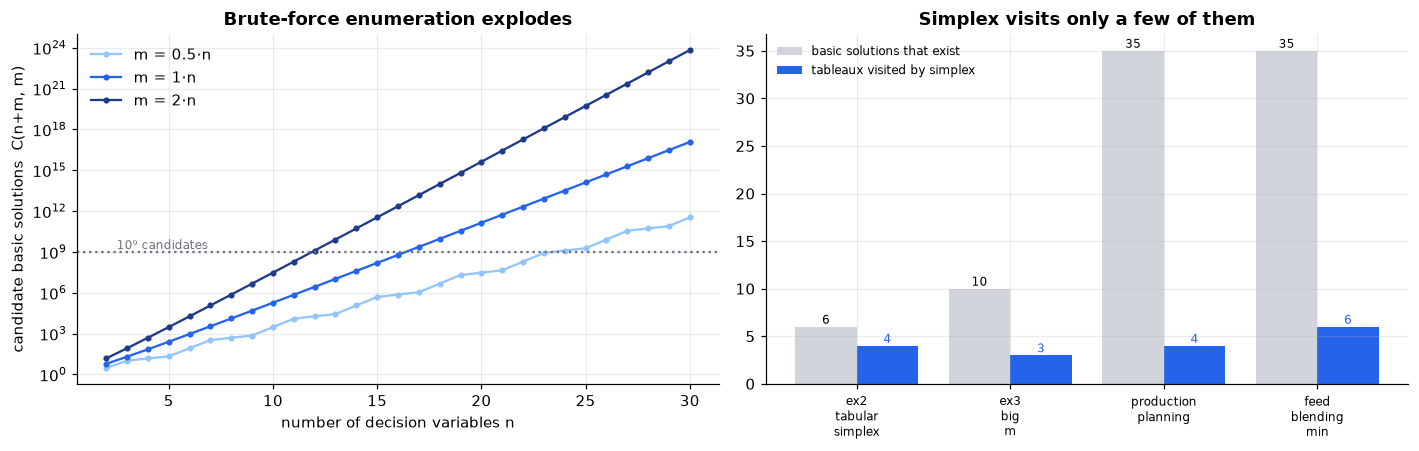

In [16]:
sizes = np.arange(2, 31)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for ratio, col in [(0.5, "#93c5fd"), (1, "#2563eb"), (2, "#1e3a8a")]:
    counts = [math.comb(int(n + max(1, round(ratio * n))), int(max(1, round(ratio * n)))) for n in sizes]
    ax[0].semilogy(sizes, counts, marker="o", ms=3, color=col, label=f"m = {ratio:g}·n")
ax[0].set_xlabel("number of decision variables n"); ax[0].set_ylabel("candidate basic solutions  C(n+m, m)")
ax[0].set_title("Brute-force enumeration explodes"); ax[0].legend()
ax[0].axhline(1e9, ls=":", color=MUTED); ax[0].text(2.5, 1.6e9, "10⁹ candidates", color=MUTED, fontsize=8)

names, visited, total = [], [], []
for f in ["ex2_tabular_simplex.json", "ex3_big_m.json", "production_planning.json", "feed_blending_min.json"]:
    p_ = load_problem(os.path.join(DATA_DIR, f)); r_ = simplex(p_); sf_ = r_.sf
    names.append(f.split(".")[0].replace("_", "\n")); visited.append(len(r_.bfs_history()))
    total.append(math.comb(sf_.N - len(sf_.idx("artificial")), sf_.m))
x = np.arange(len(names))
ax[1].bar(x - 0.2, total, 0.4, color="#d1d5db", label="basic solutions that exist")
ax[1].bar(x + 0.2, visited, 0.4, color="#2563eb", label="tableaux visited by simplex")
for i in x:
    ax[1].text(i - 0.2, total[i], total[i], ha="center", va="bottom", fontsize=8)
    ax[1].text(i + 0.2, visited[i], visited[i], ha="center", va="bottom", fontsize=8, color="#2563eb")
ax[1].set_xticks(x); ax[1].set_xticklabels(names, fontsize=8); ax[1].legend(fontsize=8)
ax[1].set_title("Simplex visits only a few of them")
plt.tight_layout(); plt.show()

## 3. LP terminologies (slide 4) — seen on Example 2
* **Feasible solution** – satisfies all constraints and non-negativity; the feasible set is **convex**.
* **Infeasible solution** – violates at least one constraint or non-negativity condition.
* **Basic solution** – the intersection of two (or more) constraint lines (in standard form: *m* basic variables, the rest 0).
* **Extreme points** – the corners of the feasible set = the **basic feasible solutions**.
* **Optimal solution** – if it exists, it occurs at one (or more) extreme points.

The table lists every basic solution of Example 2; the plot marks feasible ones (green, the extreme points) and infeasible ones (red ✕). The optimum Z = 70 is an extreme point.

In [17]:
p2 = load_problem("data/ex2_tabular_simplex.json")
sf2 = standardize(p2)
bs2 = show_basic_solutions(sf2)

Basic variables,X1,X2,Feasible?,Z,X3,X4,Optimal?
"X1, X2",2,1,True,50,0,0,False
"X1, X3",2.3333,0,False,46.6667,-1.3333,0,False
"X1, X4",1,0,True,20,0,4,False
"X2, X3",0,7,True,70,8,0,True
"X2, X4",0,-1,False,-10,0,8,False
"X3, X4",0,0,True,0,1,7,False


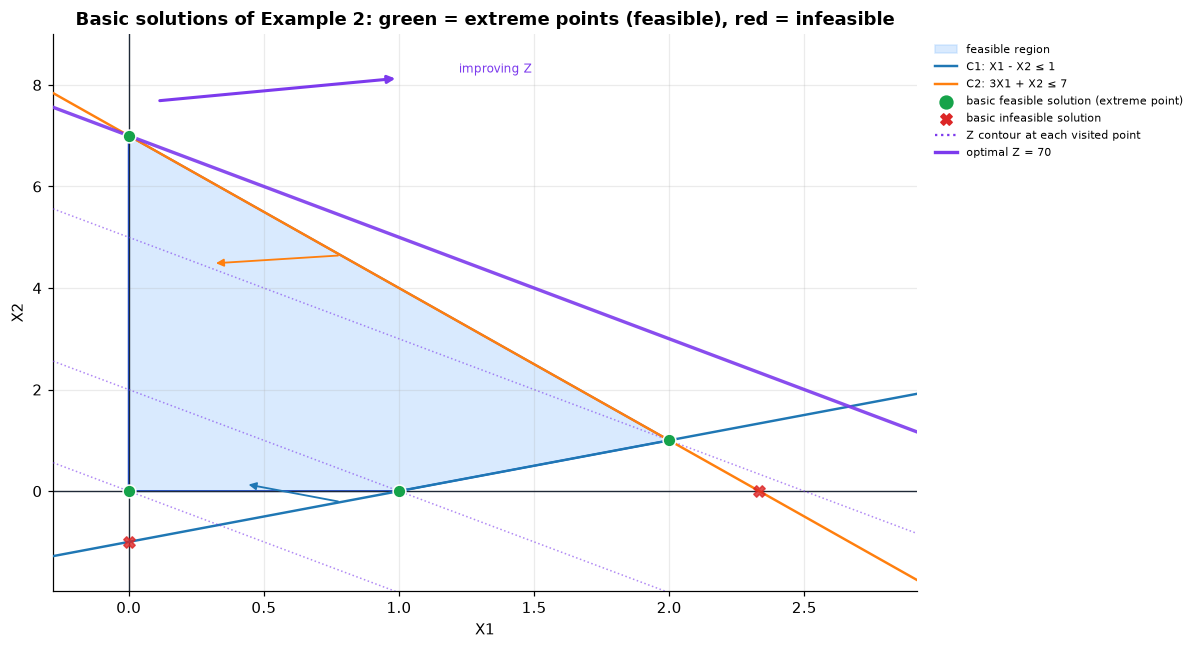

In [18]:
res2 = simplex(p2)
fig, ax = plt.subplots(figsize=(11, 6))
plot_region_2d(ax, res2, show_path=False)
ax.set_title("Basic solutions of Example 2: green = extreme points (feasible), red = infeasible")
plt.tight_layout(); plt.show()

## 4. Steps of the Simplex process (slide 5)
1. Begin the search at an **extreme point** (a basic feasible solution).
2. Determine whether moving to an **adjacent** extreme point can improve the objective. If not, the present solution is **optimal**.
3. Move to the adjacent extreme point which offers the **most improvement** (per unit of the entering variable).
4. Continue steps 2 and 3 until the optimum is found, or it can be shown that the problem is **unbounded** or **infeasible**.

The decision logic (slide 78) — the highlighted box is what happens after each iteration:

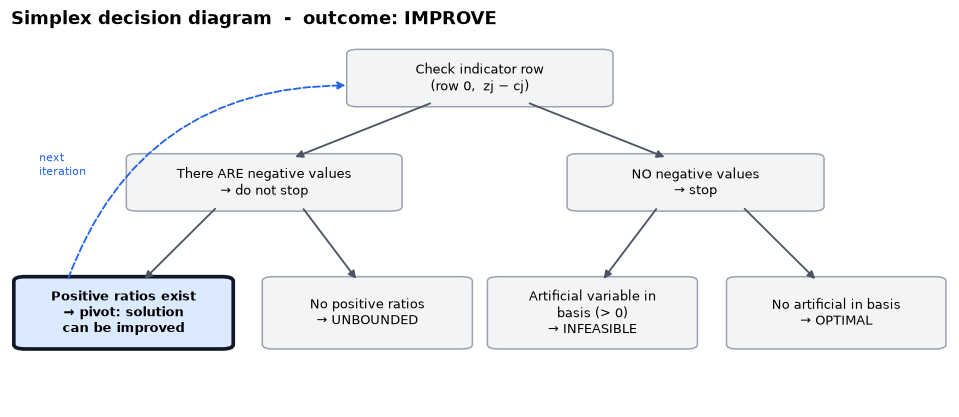

In [19]:
fig, ax = plt.subplots(figsize=(11, 4.4)); draw_flowchart(ax, 'improve'); plt.show()

## 5. Standard LP form — the lecture's conversion snippets
**Type I:** $X_1+2X_2\le 6 \;\Rightarrow\; X_1+2X_2+S_1=6$ &nbsp;&nbsp; **Type II:** $3X_1+2X_2-3X_3\ge 5\;\Rightarrow\;3X_1+2X_2-3X_3-S_2+R_1=5$

In [20]:
snip = LPProblem("Slide 7-8 snippets", "max", ["X1", "X2", "X3"], [1, 1, 1],
                 A=[[1, 2, 0], [3, 2, -3]], types=["<=", ">="], b=[6, 5])
show_standard_form(standardize(snip, naming="typed"))

#### Transformation steps
1. **C1** (Type I, ≤): add slack **S1** ≥ 0 (unused resource, cost 0) → S1 is the starting basic variable of this row.
2. **C2** (Type II, ≥): subtract surplus **S2** ≥ 0 (cost 0). Its column is −1, so it cannot start in the basis → an artificial variable is needed.
3. **C2**: add artificial **R1** ≥ 0 with objective coefficient **−M** (huge penalty) → it provides an immediately recognisable starting basic variable.

#### Standard form$$\begin{aligned}\text{Maximize}\quad & Z = X_{1} + X_{2} + X_{3} - M\,R_{1} \\
\text{subject to}\quad & \\
& X_{1} + 2X_{2} + S_{1} = 6 \qquad (\text{C1}) \\
& 3X_{1} + 2X_{2} - 3X_{3} - S_{2} + R_{1} = 5 \qquad (\text{C2}) \\
& X_{1}, X_{2}, X_{3}, S_{1}, S_{2}, R_{1} \ge 0\end{aligned}$$

Variable,Kind,Role,Objective coef.,Starts basic?
X1,decision,decision variable,1,
X2,decision,decision variable,1,
X3,decision,decision variable,1,
S1,slack,slack of C1,0,yes
S2,surplus,surplus of C2,0,
R1,artificial,artificial of C2,-M,yes


**Minimisation** (slide 9: multiply by −1 and maximise) and a **negative right-hand side** (the row is multiplied by −1 and the inequality flips) are handled automatically:

In [21]:
demo = LPProblem("Min with negative RHS", "min", ["X1", "X2"], [2, 3],
                 A=[[1, 1], [-1, 2]], types=[">=", "<="], b=[4, -2])
show_problem(demo); show_standard_form(standardize(demo))

**Min with negative RHS**

$$\begin{aligned}\text{Minimize}\quad & Z = 2X_{1} + 3X_{2} \\
\text{subject to}\quad & \\
& X_{1} + X_{2} \ge 4 \qquad (\text{C1}) \\
& -X_{1} + 2X_{2} \le -2 \qquad (\text{C2}) \\
& X_{1}, X_{2} \ge 0\end{aligned}$$

#### Transformation steps
1. Row **C2** had a negative RHS: multiplied by −1 (the inequality direction flips) so that every RHS is ≥ 0.
2. The objective is **minimisation** → multiply by −1 and **maximise** Z′ = −Z (lecture slide 9). The final answer is converted back with Z = −Z′.
3. **C1** (Type II, ≥): subtract surplus **X3** ≥ 0 (cost 0). Its column is −1, so it cannot start in the basis → an artificial variable is needed.
4. **C2** (Type II, ≥): subtract surplus **X4** ≥ 0 (cost 0). Its column is −1, so it cannot start in the basis → an artificial variable is needed.
5. **C1**: add artificial **X5** ≥ 0 with objective coefficient **−M** (huge penalty) → it provides an immediately recognisable starting basic variable.
6. **C2**: add artificial **X6** ≥ 0 with objective coefficient **−M** (huge penalty) → it provides an immediately recognisable starting basic variable.

#### Standard form$$\begin{aligned}\text{Maximize}\quad & Z' = -2X_{1} - 3X_{2} - M\,X_{5} - M\,X_{6} \\
\text{subject to}\quad & \\
& X_{1} + X_{2} - X_{3} + X_{5} = 4 \qquad (\text{C1}) \\
& X_{1} - 2X_{2} - X_{4} + X_{6} = 2 \qquad (\text{C2}) \\
& X_{1}, X_{2}, X_{3}, X_{4}, X_{5}, X_{6} \ge 0\end{aligned}$$

Variable,Kind,Role,Objective coef.,Starts basic?
X1,decision,decision variable,-2,
X2,decision,decision variable,-3,
X3,surplus,surplus of C1,0,
X4,surplus,surplus of C2,0,
X5,artificial,artificial of C1,-M,yes
X6,artificial,artificial of C2,-M,yes


## 6. Example 1 — converting both constraints and objective (slides 11–14)
$$\max z=7X_1-3X_2+5X_3\quad\text{s.t.}\quad X_1+X_2+X_3\ge 9,\;\; 3X_1+2X_2+X_3\le 12,\;\; X_1,X_2,X_3\ge 0$$
Using the $S$/$R$ notation of slide 12:

In [22]:
p1 = load_problem("data/ex1_standard_form.json")
show_problem(p1)
show_standard_form(standardize(p1, naming="typed"))

**Lecture Example 1 - Converting to Standard Form**  
*Lecture slides 11-14. Mixed >= / <= constraints; used to demonstrate slack, surplus and artificial variables. Solved here to completion as an extension (3 decision variables -> 3-D geometry).*

$$\begin{aligned}\text{Maximize}\quad & Z = 7X_{1} - 3X_{2} + 5X_{3} \\
\text{subject to}\quad & \\
& X_{1} + X_{2} + X_{3} \ge 9 \qquad (\text{C1}) \\
& 3X_{1} + 2X_{2} + X_{3} \le 12 \qquad (\text{C2}) \\
& X_{1}, X_{2}, X_{3} \ge 0\end{aligned}$$

#### Transformation steps
1. **C1** (Type II, ≥): subtract surplus **S1** ≥ 0 (cost 0). Its column is −1, so it cannot start in the basis → an artificial variable is needed.
2. **C2** (Type I, ≤): add slack **S2** ≥ 0 (unused resource, cost 0) → S2 is the starting basic variable of this row.
3. **C1**: add artificial **R1** ≥ 0 with objective coefficient **−M** (huge penalty) → it provides an immediately recognisable starting basic variable.

#### Standard form$$\begin{aligned}\text{Maximize}\quad & Z = 7X_{1} - 3X_{2} + 5X_{3} - M\,R_{1} \\
\text{subject to}\quad & \\
& X_{1} + X_{2} + X_{3} - S_{1} + R_{1} = 9 \qquad (\text{C1}) \\
& 3X_{1} + 2X_{2} + X_{3} + S_{2} = 12 \qquad (\text{C2}) \\
& X_{1}, X_{2}, X_{3}, S_{1}, S_{2}, R_{1} \ge 0\end{aligned}$$

Variable,Kind,Role,Objective coef.,Starts basic?
X1,decision,decision variable,7,
X2,decision,decision variable,-3,
X3,decision,decision variable,5,
S1,surplus,surplus of C1,0,
S2,slack,slack of C2,0,yes
R1,artificial,artificial of C1,-M,yes


…and with the $X$ numbering of slide 13 (here slack/surplus come before the artificial, so the artificial is $X_6$ rather than the slide's $X_5$ — only the labels differ):

$$\begin{aligned}\text{Maximize}\quad & Z = 7X_{1} - 3X_{2} + 5X_{3} - M\,X_{6} \\
\text{subject to}\quad & \\
& X_{1} + X_{2} + X_{3} - X_{4} + X_{6} = 9 \qquad (\text{C1}) \\
& 3X_{1} + 2X_{2} + X_{3} + X_{5} = 12 \qquad (\text{C2}) \\
& X_{1}, X_{2}, X_{3}, X_{4}, X_{5}, X_{6} \ge 0\end{aligned}$$

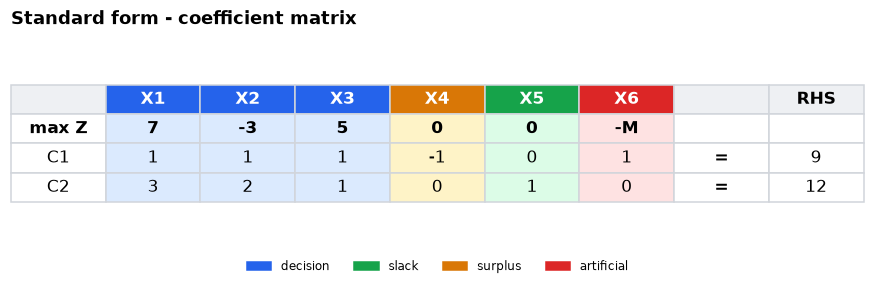

In [23]:
sf1 = standardize(p1)
display(Markdown(standard_form_latex(sf1)))
fig, ax = plt.subplots(figsize=(10, 2.6)); plot_standard_matrix(ax, sf1); plt.show()

**Extension — solving Example 1.** It has three decision variables, so the geometry is a 3-D polytope. The start (origin) is *not* feasible (it violates $X_1+X_2+X_3\ge 9$); the artificial variable carries the search into the feasible region.

**Initial tableau.** Basic variables: X6 = 9, X5 = 12. Non-basic (set to 0): X1, X2, X3, X4. The values of the basic variables are read directly from the RHS column.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS
Z,0,1,-7,3,-5,0,0,M,0
X6,1,0,1,1,1,-1,0,1,9
X5,2,0,3,2,1,0,1,0,12


**Big-M preparation.** the artificial basic variable(s) had coefficient M in row 0. Subtracting M × their rows makes those coefficients zero, so row 0 is ready for the optimality test.  
• Subtract M × R1 from R0  (make the coefficient of basic X6 zero)

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS
Z,0,1,-7-M,3-M,-5-M,M,0,0,-9M
X6,1,0,1,1,1,-1,0,1,9
X5,2,0,3,2,1,0,1,0,12


**Iteration 1 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X1** - it has the largest (in absolute value) negative coefficient in row 0 (-7-M).  
• Minimum ratio test (RHS ÷ positive entries of the X1-column): R1: 9, R2: 4.  
• **Leaving basic variable: X5** (row 2, smallest ratio). Pivot number = 3.

...

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS,Ratio
Z,0,1,0,9,0,-4,1,4+M,48,
X3,1,0,0,0.5,1,-1.5,-0.5,1.5,7.5,-ve
X1,2,0,2,1,0,1,1,-1,3,3


**Iteration 3 - eliminating X4 from the other rows** (to obtain 0 in every other row of the pivot column):  
• Add 4 × R2 to R0  
• Add 1.5 × R2 to R1  
X4 replaced X1 in the basis.  Current Z = 60.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS
Z,0,1,8,13,0,0,5,M,60
X3,1,0,3,2,1,0,1,0,12
X4,2,0,2,1,0,1,1,-1,3


**Final check.**  
• Optimal: row 0 has no negative coefficients. Z* = 60

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS
Z,0,1,8,13,0,0,5,M,60
X3,1,0,3,2,1,0,1,0,12
X4,2,0,2,1,0,1,1,-1,3


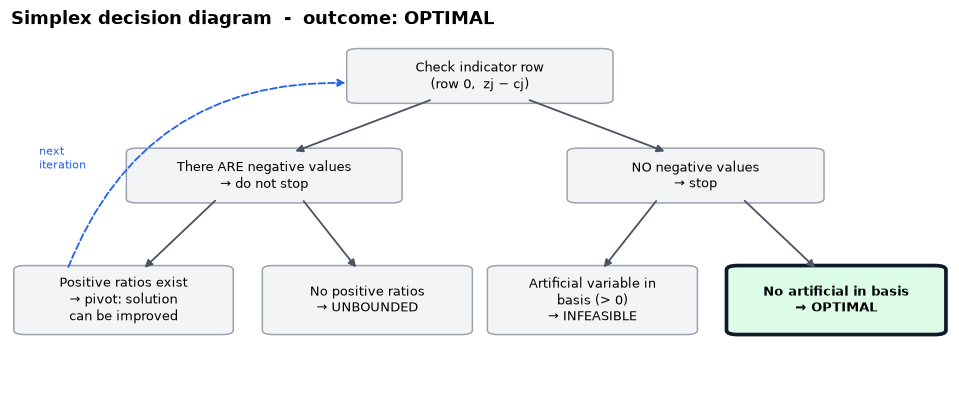

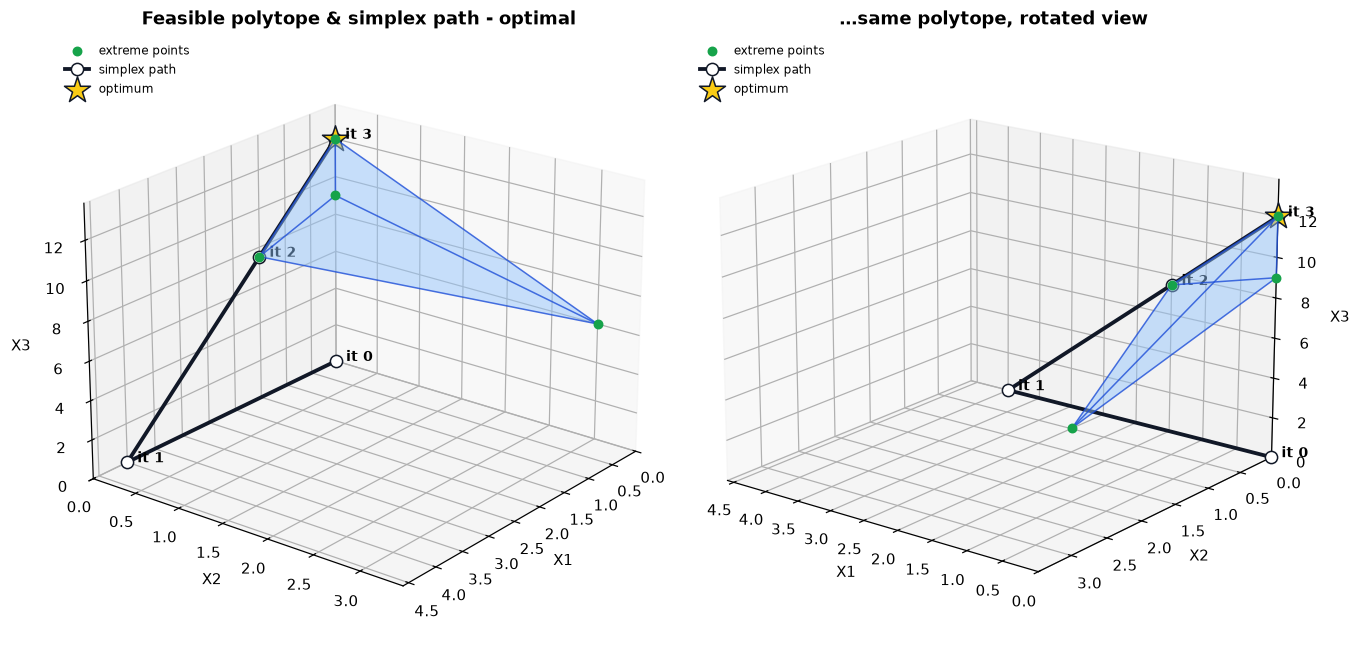

In [24]:
res1 = simplex(p1)
walkthrough(res1, charts=False)
plot_geometry(res1); plt.show()

## 7. Example 2 — the tabular Simplex method step by step (slides 15–57)
$$\max Z=20x_1+10x_2\quad\text{s.t.}\quad x_1-x_2\le1,\;\;3x_1+x_2\le7,\;\;x_1,x_2\ge0$$
Slack variables $x_3,x_4$ turn the model into the standard form of slide 17:
$$\begin{aligned}(0)\;&Z-20x_1-10x_2=0\\(1)\;&x_1-x_2+x_3=1\\(2)\;&3x_1+x_2+x_4=7\end{aligned}$$

In [25]:
res2 = simplex(p2)
show_problem(p2)
show_standard_form(res2.sf)

**Lecture Example 2 - Tabular Simplex**  
*Lecture slides 15-57. All <= constraints, slack variables give the starting basis. Three iterations to the optimum Z = 70.*

$$\begin{aligned}\text{Maximize}\quad & Z = 20X_{1} + 10X_{2} \\
\text{subject to}\quad & \\
& X_{1} - X_{2} \le 1 \qquad (\text{C1}) \\
& 3X_{1} + X_{2} \le 7 \qquad (\text{C2}) \\
& X_{1}, X_{2} \ge 0\end{aligned}$$

#### Transformation steps
1. **C1** (Type I, ≤): add slack **X3** ≥ 0 (unused resource, cost 0) → X3 is the starting basic variable of this row.
2. **C2** (Type I, ≤): add slack **X4** ≥ 0 (unused resource, cost 0) → X4 is the starting basic variable of this row.

#### Standard form$$\begin{aligned}\text{Maximize}\quad & Z = 20X_{1} + 10X_{2} \\
\text{subject to}\quad & \\
& X_{1} - X_{2} + X_{3} = 1 \qquad (\text{C1}) \\
& 3X_{1} + X_{2} + X_{4} = 7 \qquad (\text{C2}) \\
& X_{1}, X_{2}, X_{3}, X_{4} \ge 0\end{aligned}$$

Variable,Kind,Role,Objective coef.,Starts basic?
X1,decision,decision variable,20,
X2,decision,decision variable,10,
X3,slack,slack of C1,0,yes
X4,slack,slack of C2,0,yes


### 7.1 Walkthrough — every tableau of the slides
Each *selection* step shows the row-0 chart (entering variable) and the ratio chart (leaving variable); then the scaled pivot row and the eliminated tableau follow, exactly as in the slides.

**Initial tableau.** Basic variables: X3 = 1, X4 = 7. Non-basic (set to 0): X1, X2. The values of the basic variables are read directly from the RHS column.

Basic,Eq.,Z,X1,X2,X3,X4,RHS
Z,0,1,-20,-10,0,0,0
X3,1,0,1,-1,1,0,1
X4,2,0,3,1,0,1,7


**Iteration 1 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X1** - it has the largest (in absolute value) negative coefficient in row 0 (-20).  
• Minimum ratio test (RHS ÷ positive entries of the X1-column): R1: 1, R2: 2.3333.  
• **Leaving basic variable: X3** (row 1, smallest ratio). Pivot number = 1.

Basic,Eq.,Z,X1,X2,X3,X4,RHS,Ratio
Z,0,1,-20,-10,0,0,0,
X3,1,0,1,-1,1,0,1,1
X4,2,0,3,1,0,1,7,2.3333


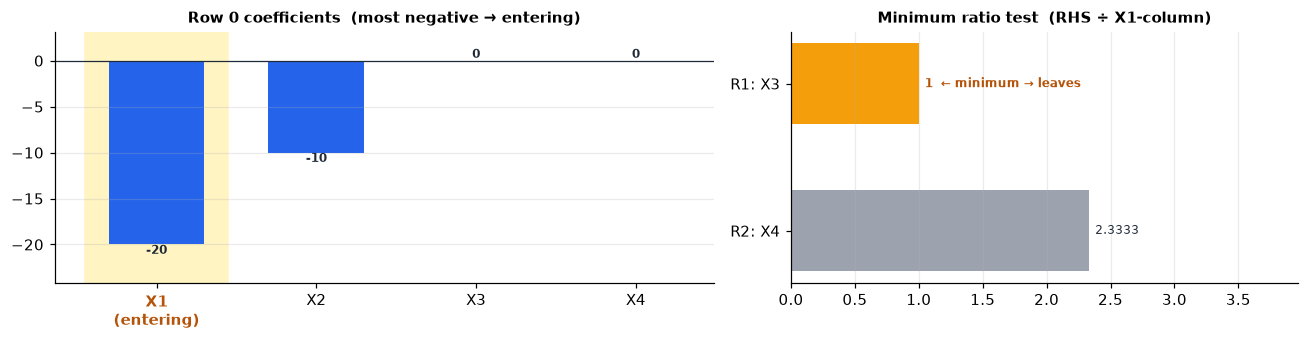

**Iteration 1 - scaling the pivot row.** Pivot number is already 1 - scaling not needed (normally divide the pivot row by the pivot number) → the pivot number becomes 1.

Basic,Eq.,Z,X1,X2,X3,X4,RHS,Ratio
Z,0,1,-20,-10,0,0,0,
X3,1,0,1,-1,1,0,1,1
X4,2,0,3,1,0,1,7,2.3333


**Iteration 1 - eliminating X1 from the other rows** (to obtain 0 in every other row of the pivot column):  
• Add 20 × R1 to R0  
• Subtract 3 × R1 from R2  
X1 replaced X3 in the basis.  Current Z = 20.

Basic,Eq.,Z,X1,X2,X3,X4,RHS
Z,0,1,0,-30,20,0,20
X1,1,0,1,-1,1,0,1
X4,2,0,0,4,-3,1,4


**Iteration 2 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X2** - it has the largest (in absolute value) negative coefficient in row 0 (-30).  
• Minimum ratio test (RHS ÷ positive entries of the X2-column): R1: -ve, R2: 1.  
• **Leaving basic variable: X4** (row 2, smallest ratio). Pivot number = 4.

Basic,Eq.,Z,X1,X2,X3,X4,RHS,Ratio
Z,0,1,0,-30,20,0,20,
X1,1,0,1,-1,1,0,1,-ve
X4,2,0,0,4,-3,1,4,1


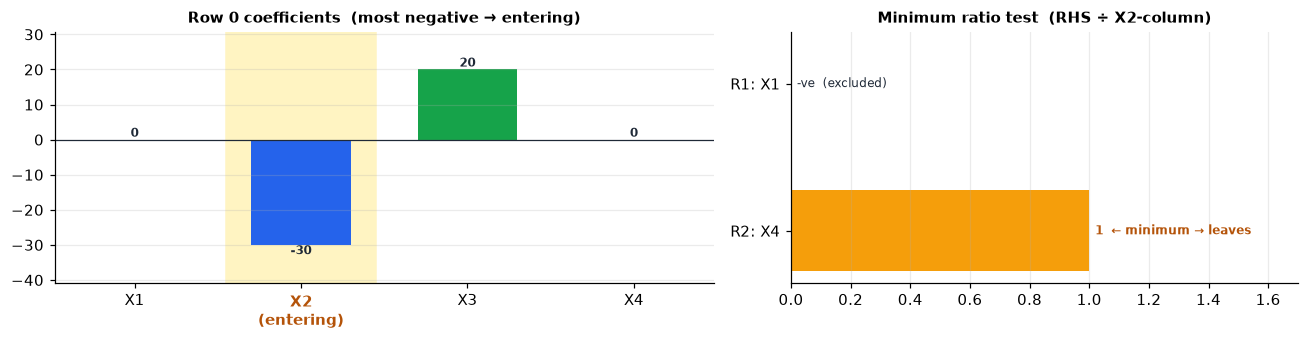

**Iteration 2 - scaling the pivot row.** Divide R2 by the pivot number 4 → the pivot number becomes 1.

Basic,Eq.,Z,X1,X2,X3,X4,RHS,Ratio
Z,0,1,0,-30,20,0,20,
X1,1,0,1,-1,1,0,1,-ve
X4,2,0,0,1,-0.75,0.25,1,1


**Iteration 2 - eliminating X2 from the other rows** (to obtain 0 in every other row of the pivot column):  
• Add 30 × R2 to R0  
• Add 1 × R2 to R1  
X2 replaced X4 in the basis.  Current Z = 50.

Basic,Eq.,Z,X1,X2,X3,X4,RHS
Z,0,1,0,0,-2.5,7.5,50
X1,1,0,1,0,0.25,0.25,2
X2,2,0,0,1,-0.75,0.25,1


**Iteration 3 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X3** - it has the largest (in absolute value) negative coefficient in row 0 (-2.5).  
• Minimum ratio test (RHS ÷ positive entries of the X3-column): R1: 8, R2: -ve.  
• **Leaving basic variable: X1** (row 1, smallest ratio). Pivot number = 0.25.

Basic,Eq.,Z,X1,X2,X3,X4,RHS,Ratio
Z,0,1,0,0,-2.5,7.5,50,
X1,1,0,1,0,0.25,0.25,2,8
X2,2,0,0,1,-0.75,0.25,1,-ve


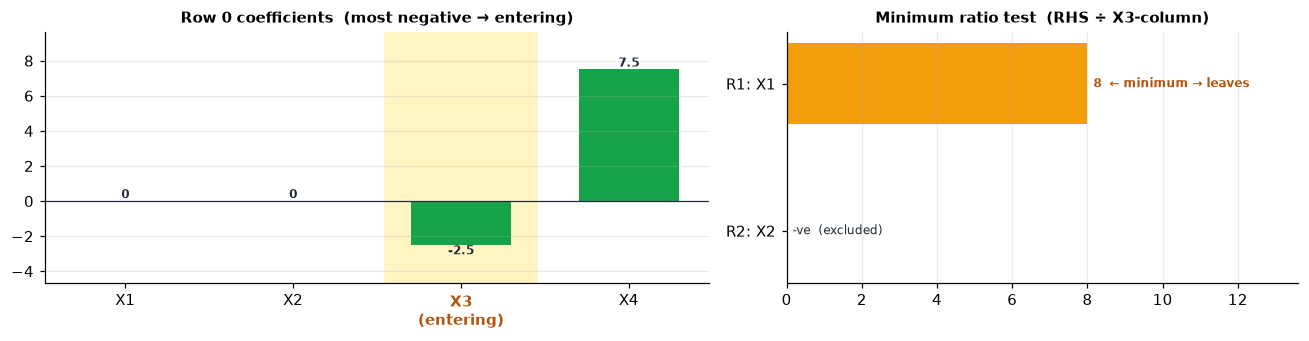

**Iteration 3 - scaling the pivot row.** Divide R1 by the pivot number 0.25 → the pivot number becomes 1.

Basic,Eq.,Z,X1,X2,X3,X4,RHS,Ratio
Z,0,1,0,0,-2.5,7.5,50,
X1,1,0,4,0,1,1,8,8
X2,2,0,0,1,-0.75,0.25,1,-ve


**Iteration 3 - eliminating X3 from the other rows** (to obtain 0 in every other row of the pivot column):  
• Add 2.5 × R1 to R0  
• Add 0.75 × R1 to R2  
X3 replaced X1 in the basis.  Current Z = 70.

Basic,Eq.,Z,X1,X2,X3,X4,RHS
Z,0,1,10,0,0,10,70
X3,1,0,4,0,1,1,8
X2,2,0,3,1,0,1,7


**Final check.**  
• Optimal: row 0 has no negative coefficients. Z* = 70

Basic,Eq.,Z,X1,X2,X3,X4,RHS
Z,0,1,10,0,0,10,70
X3,1,0,4,0,1,1,8
X2,2,0,3,1,0,1,7


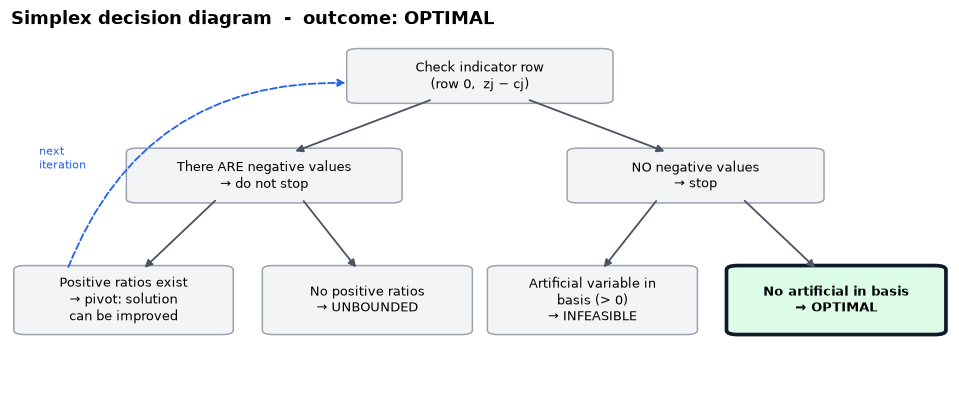

In [26]:
walkthrough(res2)

### 7.2 Geometry — the path from extreme point to adjacent extreme point
Iteration 0 at the origin (Z = 0) → (1, 0) with Z = 20 → (2, 1) with Z = 50 → (0, 7) with Z = 70. Iteration 3 brings the **slack** $x_3$ into the basis: constraint C1 stops being binding and the search slides along C2 to the optimum.

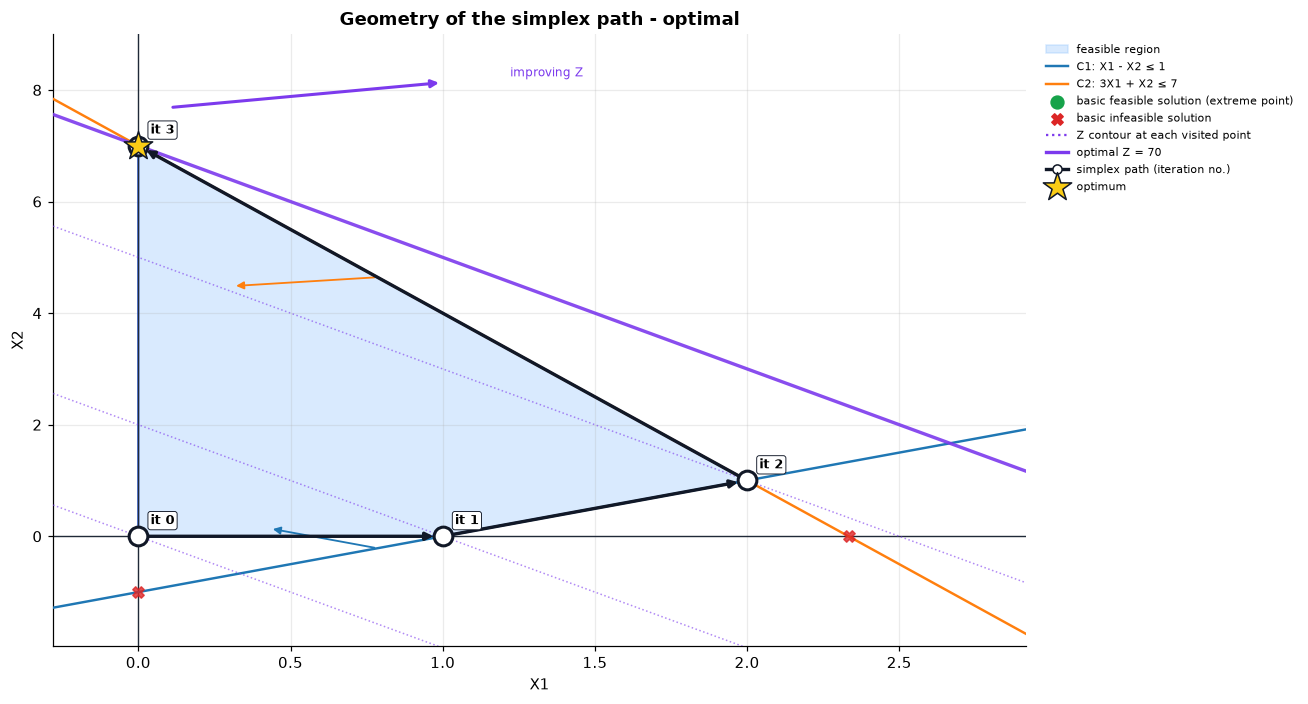

In [27]:
plot_geometry(res2); plt.show()

### 7.3 Summary dashboard

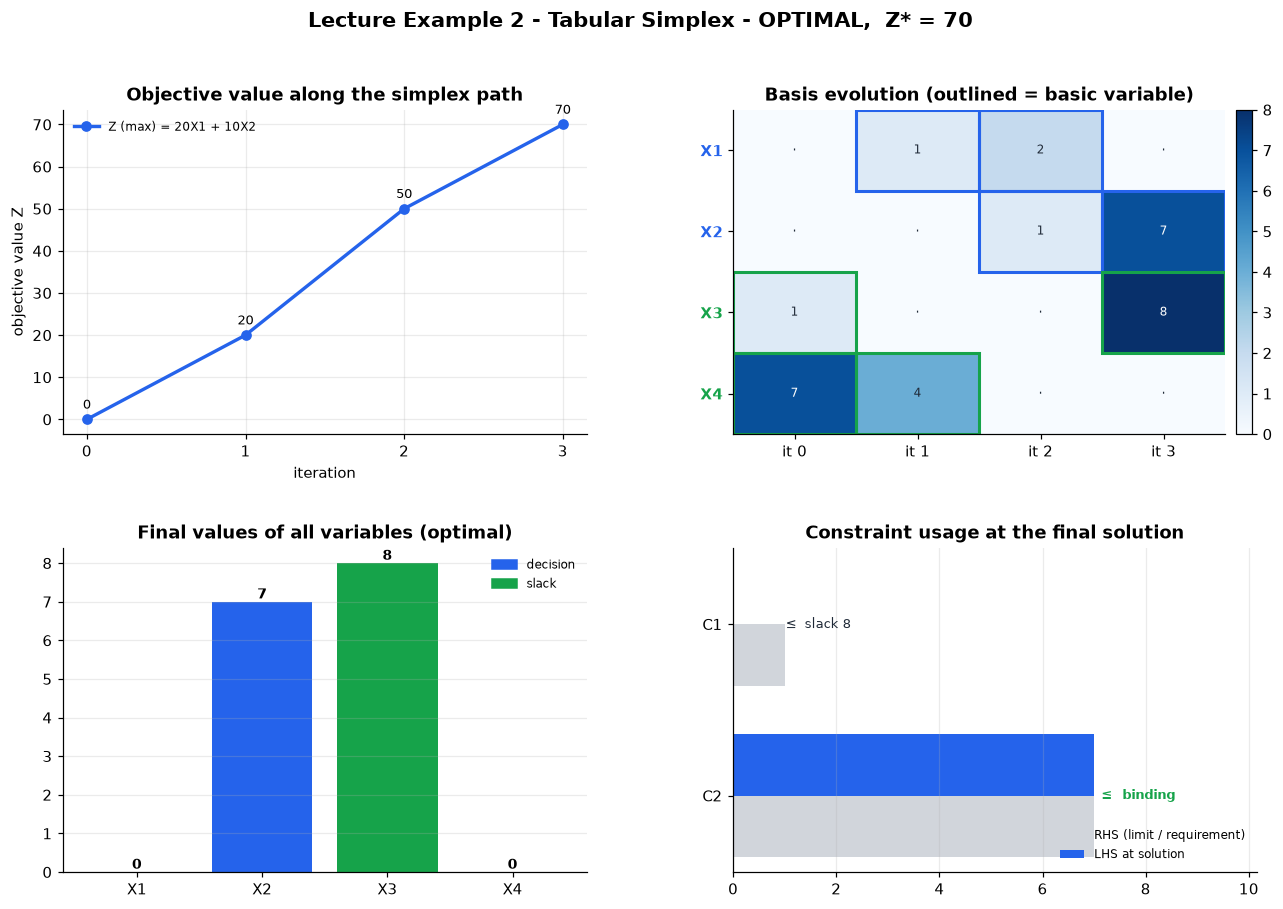

In [28]:
dashboard(res2); plt.show()

### 7.4 Verification and PDF report

In [29]:
df, ok = compare_with_scipy(res2); display(df)
path = export_pdf_report(res2); print("PDF written:", path)

,quantity,our tableau simplex,SciPy HiGHS
0,status,optimal,optimal
1,Z,70,70
2,X1,0,0
3,X2,7,7


PDF written: reports\ex2_tabular_simplex_report.pdf


## 8. Example 3 — Big-M with an artificial variable (slides 60–77)
$$\max z=4X_1+3X_2\quad\text{s.t.}\quad X_1+2X_2\le4,\;\;2X_1+X_2\ge6,\;\;X_2\le1$$
Standard form (slide 61): $\max z=4X_1+3X_2+0X_3+0X_4+0X_5-MX_6$ with
$X_1+2X_2+X_3=4,\;\;2X_1+X_2-X_4+X_6=6,\;\;X_2+X_5=1$.

The objective equation is valid, but a **basic** variable ($X_6$) has coefficient **M** in row 0, so row 0 is not yet ready for the optimality test. **Subtracting M × row 2** zeroes it — the Big-M preparation step (slides 62–63), which produces the entries $-4-2M$, $-3-M$ and RHS $-6M$.

> **Note on the slides.** In iteration 2 the entering variable is $X_4$ and the leaving variable is $X_3$ (row 1, ratio 2). The last two tableaux of the slides still label row 1 as “X3”; the correct basic variable of row 1 is **$X_4 = 2$**, as the tableaux below show. The optimum is $Z=16$ with $X_1=4$, $X_2=0$ ($X_4=2$ surplus, $X_5=1$ slack).

In [30]:
p3 = load_problem("data/ex3_big_m.json")
res3 = simplex(p3)
show_problem(p3); show_standard_form(res3.sf)

**Lecture Example 3 - Big-M with an Artificial Variable**  
*Lecture slides 60-77. A >= constraint requires a surplus and an artificial variable penalised by -M in the objective.*

$$\begin{aligned}\text{Maximize}\quad & Z = 4X_{1} + 3X_{2} \\
\text{subject to}\quad & \\
& X_{1} + 2X_{2} \le 4 \qquad (\text{C1}) \\
& 2X_{1} + X_{2} \ge 6 \qquad (\text{C2}) \\
& X_{2} \le 1 \qquad (\text{C3}) \\
& X_{1}, X_{2} \ge 0\end{aligned}$$

#### Transformation steps
1. **C1** (Type I, ≤): add slack **X3** ≥ 0 (unused resource, cost 0) → X3 is the starting basic variable of this row.
2. **C2** (Type II, ≥): subtract surplus **X4** ≥ 0 (cost 0). Its column is −1, so it cannot start in the basis → an artificial variable is needed.
3. **C3** (Type I, ≤): add slack **X5** ≥ 0 (unused resource, cost 0) → X5 is the starting basic variable of this row.
4. **C2**: add artificial **X6** ≥ 0 with objective coefficient **−M** (huge penalty) → it provides an immediately recognisable starting basic variable.

#### Standard form$$\begin{aligned}\text{Maximize}\quad & Z = 4X_{1} + 3X_{2} - M\,X_{6} \\
\text{subject to}\quad & \\
& X_{1} + 2X_{2} + X_{3} = 4 \qquad (\text{C1}) \\
& 2X_{1} + X_{2} - X_{4} + X_{6} = 6 \qquad (\text{C2}) \\
& X_{2} + X_{5} = 1 \qquad (\text{C3}) \\
& X_{1}, X_{2}, X_{3}, X_{4}, X_{5}, X_{6} \ge 0\end{aligned}$$

Variable,Kind,Role,Objective coef.,Starts basic?
X1,decision,decision variable,4,
X2,decision,decision variable,3,
X3,slack,slack of C1,0,yes
X4,surplus,surplus of C2,0,
X5,slack,slack of C3,0,yes
X6,artificial,artificial of C2,-M,yes


**Initial tableau.** Basic variables: X3 = 4, X6 = 6, X5 = 1. Non-basic (set to 0): X1, X2, X4. The values of the basic variables are read directly from the RHS column.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS
Z,0,1,-4,-3,0,0,0,M,0
X3,1,0,1,2,1,0,0,0,4
X6,2,0,2,1,0,-1,0,1,6
X5,3,0,0,1,0,0,1,0,1


**Big-M preparation.** the artificial basic variable(s) had coefficient M in row 0. Subtracting M × their rows makes those coefficients zero, so row 0 is ready for the optimality test.  
• Subtract M × R2 from R0  (make the coefficient of basic X6 zero)

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS
Z,0,1,-4-2M,-3-M,0,M,0,0,-6M
X3,1,0,1,2,1,0,0,0,4
X6,2,0,2,1,0,-1,0,1,6
X5,3,0,0,1,0,0,1,0,1


**Iteration 1 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X1** - it has the largest (in absolute value) negative coefficient in row 0 (-4-2M).  
• Minimum ratio test (RHS ÷ positive entries of the X1-column): R1: 4, R2: 3, R3: ∞.  
• **Leaving basic variable: X6** (row 2, smallest ratio). Pivot number = 2.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS,Ratio
Z,0,1,-4-2M,-3-M,0,M,0,0,-6M,
X3,1,0,1,2,1,0,0,0,4,4
X6,2,0,2,1,0,-1,0,1,6,3
X5,3,0,0,1,0,0,1,0,1,∞


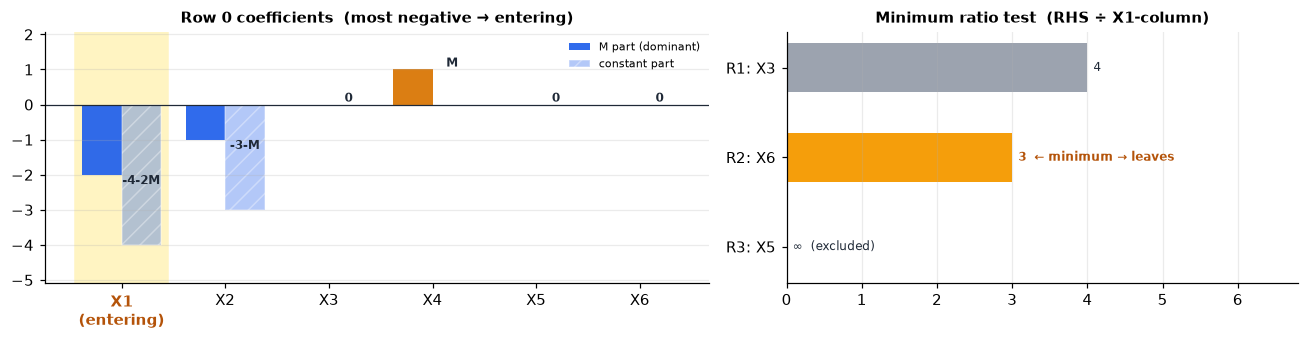

**Iteration 1 - scaling the pivot row.** Divide R2 by the pivot number 2 → the pivot number becomes 1.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS,Ratio
Z,0,1,-4-2M,-3-M,0,M,0,0,-6M,
X3,1,0,1,2,1,0,0,0,4,4
X6,2,0,1,0.5,0,-0.5,0,0.5,3,3
X5,3,0,0,1,0,0,1,0,1,∞


**Iteration 1 - eliminating X1 from the other rows** (to obtain 0 in every other row of the pivot column):  
• Add (4+2M) × R2 to R0  
• Subtract 1 × R2 from R1  
X1 replaced X6 in the basis.  Current Z = 12.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS
Z,0,1,0,-1,0,-2,0,2+M,12
X3,1,0,0,1.5,1,0.5,0,-0.5,1
X1,2,0,1,0.5,0,-0.5,0,0.5,3
X5,3,0,0,1,0,0,1,0,1


**Iteration 2 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X4** - it has the largest (in absolute value) negative coefficient in row 0 (-2).  
• Minimum ratio test (RHS ÷ positive entries of the X4-column): R1: 2, R2: -ve, R3: ∞.  
• **Leaving basic variable: X3** (row 1, smallest ratio). Pivot number = 0.5.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS,Ratio
Z,0,1,0,-1,0,-2,0,2+M,12,
X3,1,0,0,1.5,1,0.5,0,-0.5,1,2
X1,2,0,1,0.5,0,-0.5,0,0.5,3,-ve
X5,3,0,0,1,0,0,1,0,1,∞


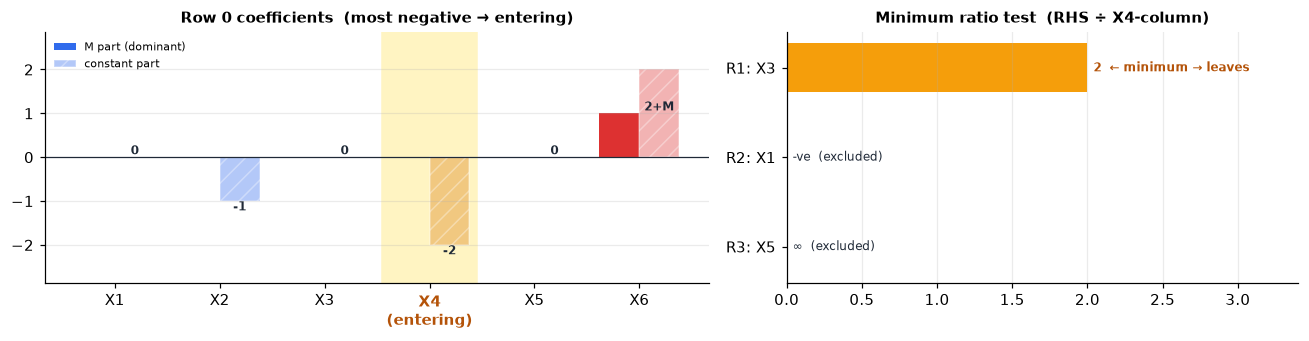

**Iteration 2 - scaling the pivot row.** Divide R1 by the pivot number 0.5 → the pivot number becomes 1.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS,Ratio
Z,0,1,0,-1,0,-2,0,2+M,12,
X3,1,0,0,3,2,1,0,-1,2,2
X1,2,0,1,0.5,0,-0.5,0,0.5,3,-ve
X5,3,0,0,1,0,0,1,0,1,∞


**Iteration 2 - eliminating X4 from the other rows** (to obtain 0 in every other row of the pivot column):  
• Add 2 × R1 to R0  
• Add 0.5 × R1 to R2  
X4 replaced X3 in the basis.  Current Z = 16.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS
Z,0,1,0,5,4,0,0,M,16
X4,1,0,0,3,2,1,0,-1,2
X1,2,0,1,2,1,0,0,0,4
X5,3,0,0,1,0,0,1,0,1


**Final check.**  
• Optimal: row 0 has no negative coefficients. Z* = 16

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS
Z,0,1,0,5,4,0,0,M,16
X4,1,0,0,3,2,1,0,-1,2
X1,2,0,1,2,1,0,0,0,4
X5,3,0,0,1,0,0,1,0,1


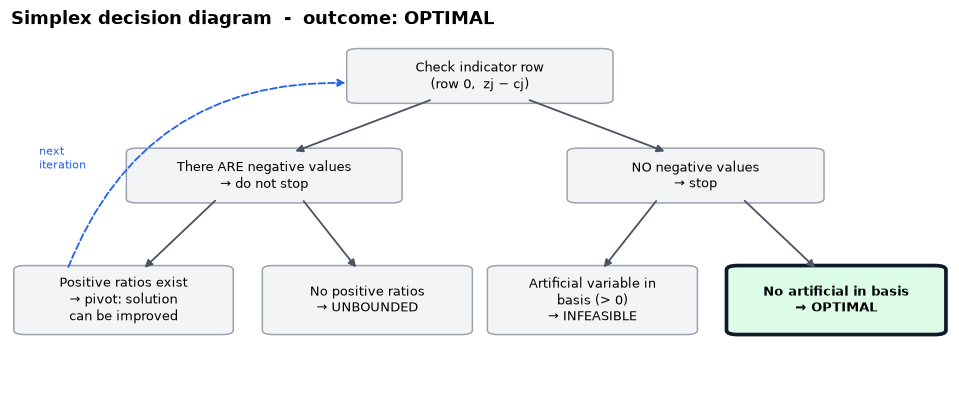

In [31]:
walkthrough(res3)

### 8.1 Geometry — starting *outside* the feasible region
The initial basis contains the artificial $X_6$, so iteration 0 sits at the origin, which violates $2X_1+X_2\ge6$. The first pivot removes $X_6$ and lands on the extreme point (3, 0); the second reaches the optimum (4, 0). The red bars in the dashboard show the artificial total dropping to 0.

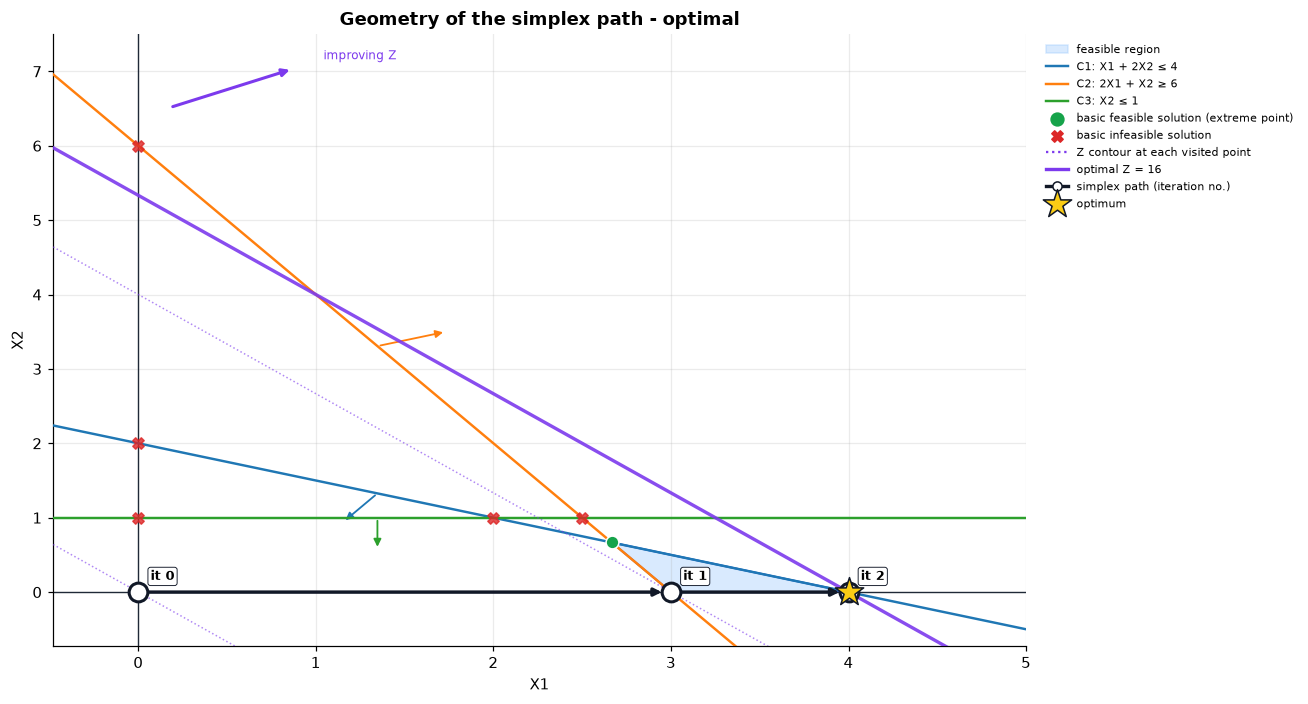

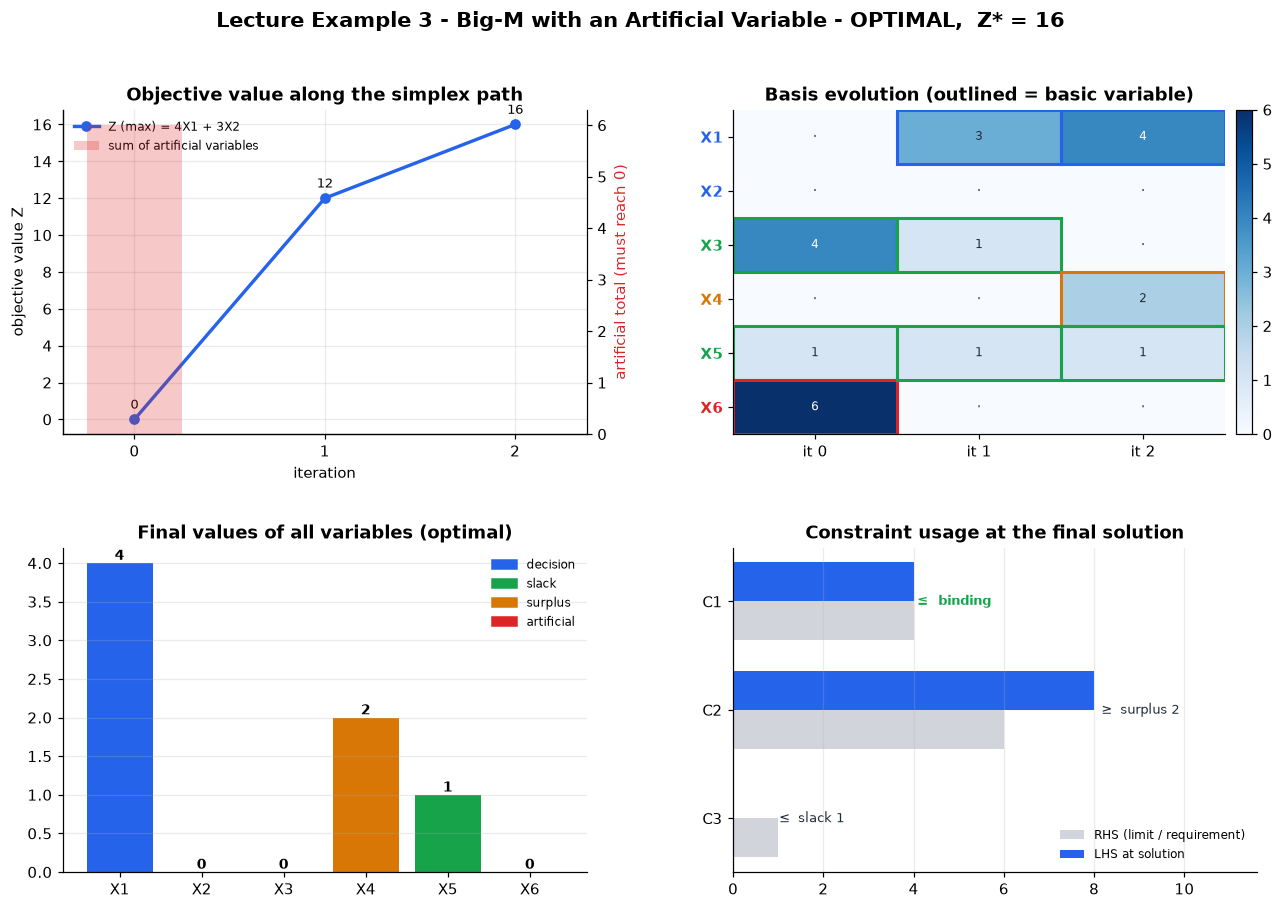

In [32]:
plot_geometry(res3); plt.show()
dashboard(res3); plt.show()

In [33]:
df, ok = compare_with_scipy(res3); display(df)
print("PDF written:", export_pdf_report(res3))

,quantity,our tableau simplex,SciPy HiGHS
0,status,optimal,optimal
1,Z,16,16
2,X1,4,4
3,X2,0,0


PDF written: reports\ex3_big_m_report.pdf


## 9. Summary — how the algorithm ends (slide 78)
We can summarise the Simplex algorithm as: **(1)** find the standard LP form, **(2)** construct the initial tableau (starting basic solution), **(3)** decide whether the solution is optimal, infeasible, unbounded, or can be improved:

| Row 0 (indicator row) | Further test | Conclusion |
|---|---|---|
| has negative values | some positive ratio exists | **pivot** — the solution can be improved |
| has negative values | **no** positive ratio | **unbounded** |
| no negative values | an artificial variable is basic at a positive level | **infeasible** |
| no negative values | no artificial variable in the basis | **optimal** |

Each branch has its own data file. (Two extras: a **minimisation** with an equality constraint, and **alternative optima** — a non-basic variable with zero in row 0 at the optimum.)

case_unbounded.json              -> UNBOUNDED   Unbounded: X3 has a negative row-0 coefficient but every entry of its column is ≤ 0, so it can increase forever while Z keeps improving.
case_infeasible.json             -> INFEASIBLE  Infeasible: row 0 has no negative values but artificial variable(s) X5 remain in the basis at a positive level.
case_minimization.json           -> OPTIMAL     Optimal: row 0 has no negative coefficients. Z* = 25 (converted back: Z = −Z′)
case_alternative_optima.json     -> OPTIMAL     Optimal: row 0 has no negative coefficients. Z* = 10


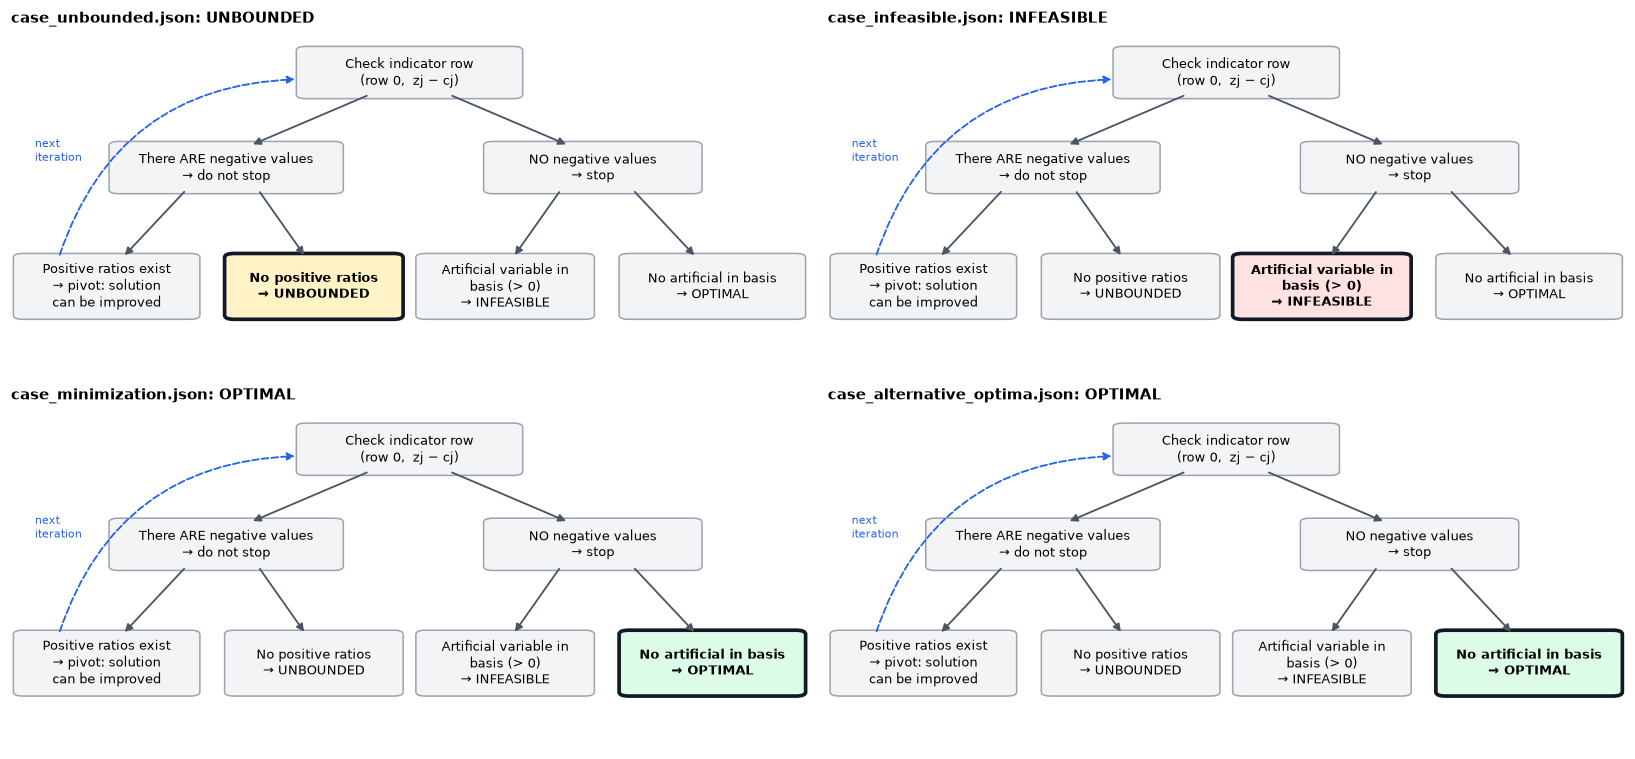

In [34]:
cases = ["case_unbounded.json", "case_infeasible.json", "case_minimization.json", "case_alternative_optima.json"]
case_results = {}
for f in cases:
    r = simplex(load_problem(os.path.join(DATA_DIR, f)))
    case_results[f] = r
    print(f"{f:32s} -> {r.status.upper():10s}  {r.messages[0]}")
fig, axs = plt.subplots(2, 2, figsize=(15, 7))
for ax, (f, r) in zip(axs.flat, case_results.items()):
    draw_flowchart(ax, r.status); ax.set_title(f"{f}: {r.status.upper()}", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

### 9.1 Unbounded
$X_2$ has a negative row-0 coefficient but every entry of its column is ≤ 0: nothing limits it, Z grows forever. The feasible region is open (shown clipped).

**Initial tableau.** Basic variables: X3 = 10, X4 = 40. Non-basic (set to 0): X1, X2. The values of the basic variables are read directly from the RHS column.

Basic,Eq.,Z,X1,X2,X3,X4,RHS
Z,0,1,-2,-1,0,0,0
X3,1,0,1,-1,1,0,10
X4,2,0,2,0,0,1,40


**Iteration 1 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X1** - it has the largest (in absolute value) negative coefficient in row 0 (-2).  
• Minimum ratio test (RHS ÷ positive entries of the X1-column): R1: 10, R2: 20.  
• **Leaving basic variable: X3** (row 1, smallest ratio). Pivot number = 1.

Basic,Eq.,Z,X1,X2,X3,X4,RHS,Ratio
Z,0,1,-2,-1,0,0,0,
X3,1,0,1,-1,1,0,10,10
X4,2,0,2,0,0,1,40,20


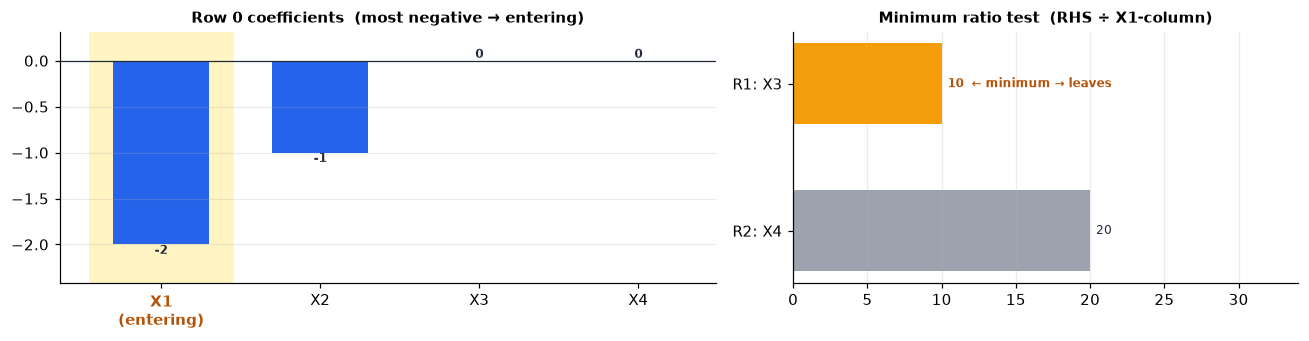

**Iteration 1 - scaling the pivot row.** Pivot number is already 1 - scaling not needed (normally divide the pivot row by the pivot number) → the pivot number becomes 1.

Basic,Eq.,Z,X1,X2,X3,X4,RHS,Ratio
Z,0,1,-2,-1,0,0,0,
X3,1,0,1,-1,1,0,10,10
X4,2,0,2,0,0,1,40,20


**Iteration 1 - eliminating X1 from the other rows** (to obtain 0 in every other row of the pivot column):  
• Add 2 × R1 to R0  
• Subtract 2 × R1 from R2  
X1 replaced X3 in the basis.  Current Z = 20.

Basic,Eq.,Z,X1,X2,X3,X4,RHS
Z,0,1,0,-3,2,0,20
X1,1,0,1,-1,1,0,10
X4,2,0,0,2,-2,1,20


**Iteration 2 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X2** - it has the largest (in absolute value) negative coefficient in row 0 (-3).  
• Minimum ratio test (RHS ÷ positive entries of the X2-column): R1: -ve, R2: 10.  
• **Leaving basic variable: X4** (row 2, smallest ratio). Pivot number = 2.

Basic,Eq.,Z,X1,X2,X3,X4,RHS,Ratio
Z,0,1,0,-3,2,0,20,
X1,1,0,1,-1,1,0,10,-ve
X4,2,0,0,2,-2,1,20,10


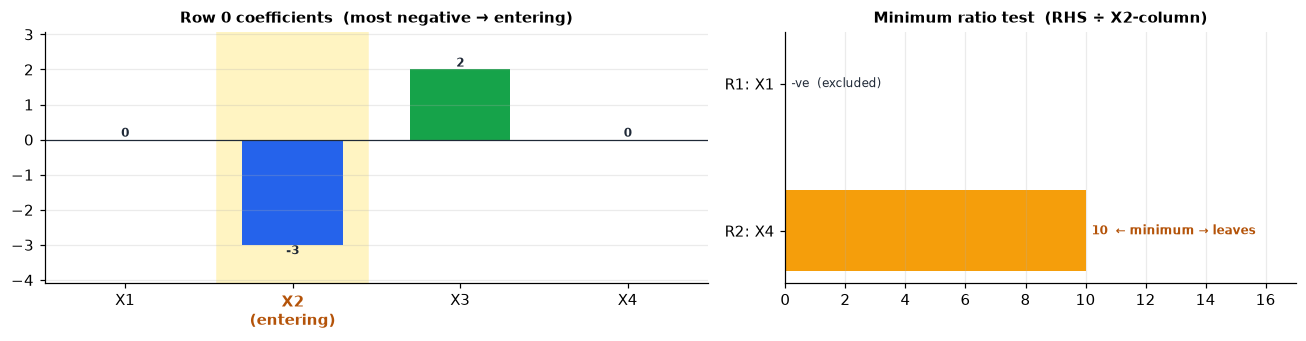

**Iteration 2 - scaling the pivot row.** Divide R2 by the pivot number 2 → the pivot number becomes 1.

Basic,Eq.,Z,X1,X2,X3,X4,RHS,Ratio
Z,0,1,0,-3,2,0,20,
X1,1,0,1,-1,1,0,10,-ve
X4,2,0,0,1,-1,0.5,10,10


**Iteration 2 - eliminating X2 from the other rows** (to obtain 0 in every other row of the pivot column):  
• Add 3 × R2 to R0  
• Add 1 × R2 to R1  
X2 replaced X4 in the basis.  Current Z = 50.

Basic,Eq.,Z,X1,X2,X3,X4,RHS
Z,0,1,0,0,-1,1.5,50
X1,1,0,1,0,0,0.5,20
X2,2,0,0,1,-1,0.5,10


**Iteration 3 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X3** - it has the largest (in absolute value) negative coefficient in row 0 (-1).  
• **No positive entry in the pivot column → no ratio → the problem is UNBOUNDED.**

Basic,Eq.,Z,X1,X2,X3,X4,RHS,Ratio
Z,0,1,0,0,-1,1.5,50,
X1,1,0,1,0,0,0.5,20,∞
X2,2,0,0,1,-1,0.5,10,-ve


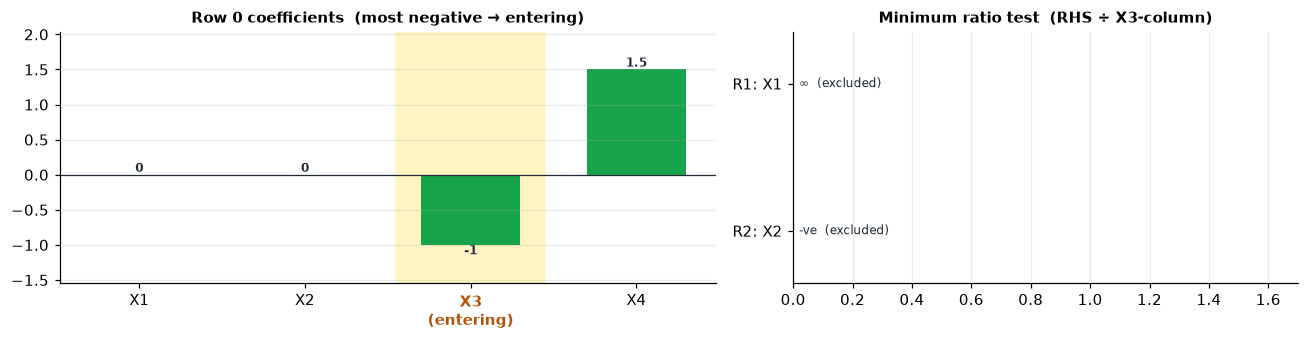

**Final check.**  
• Unbounded: X3 has a negative row-0 coefficient but every entry of its column is ≤ 0, so it can increase forever while Z keeps improving.

Basic,Eq.,Z,X1,X2,X3,X4,RHS,Ratio
Z,0,1,0,0,-1,1.5,50,
X1,1,0,1,0,0,0.5,20,∞
X2,2,0,0,1,-1,0.5,10,-ve


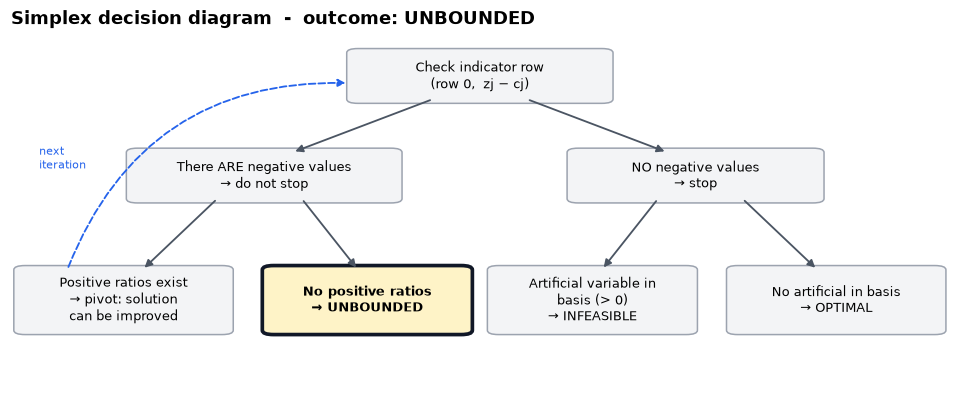

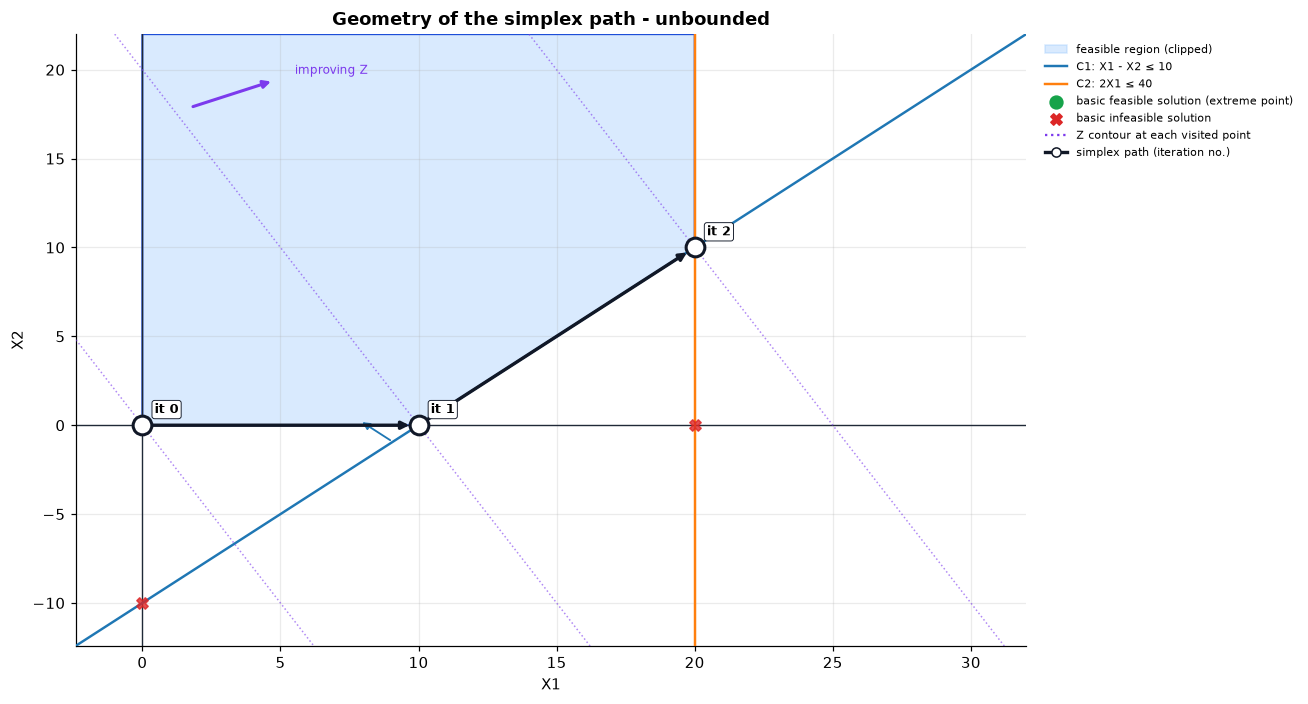

PDF: reports\case_unbounded_report.pdf


In [35]:
r = case_results["case_unbounded.json"]
walkthrough(r); plot_geometry(r); plt.show()
print("PDF:", export_pdf_report(r))

### 9.2 Infeasible
Row 0 has no negative values, yet the artificial variable stays basic at a positive level. The two shaded half-planes never overlap.

**Initial tableau.** Basic variables: X3 = 2, X5 = 12. Non-basic (set to 0): X1, X2, X4. The values of the basic variables are read directly from the RHS column.

Basic,Eq.,Z,X1,X2,X3,X4,X5,RHS
Z,0,1,-3,-2,0,0,M,0
X3,1,0,2,1,1,0,0,2
X5,2,0,3,4,0,-1,1,12


**Big-M preparation.** the artificial basic variable(s) had coefficient M in row 0. Subtracting M × their rows makes those coefficients zero, so row 0 is ready for the optimality test.  
• Subtract M × R2 from R0  (make the coefficient of basic X5 zero)

Basic,Eq.,Z,X1,X2,X3,X4,X5,RHS
Z,0,1,-3-3M,-2-4M,0,M,0,-12M
X3,1,0,2,1,1,0,0,2
X5,2,0,3,4,0,-1,1,12


**Iteration 1 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X2** - it has the largest (in absolute value) negative coefficient in row 0 (-2-4M).  
• Minimum ratio test (RHS ÷ positive entries of the X2-column): R1: 2, R2: 3.  
• **Leaving basic variable: X3** (row 1, smallest ratio). Pivot number = 1.

Basic,Eq.,Z,X1,X2,X3,X4,X5,RHS,Ratio
Z,0,1,-3-3M,-2-4M,0,M,0,-12M,
X3,1,0,2,1,1,0,0,2,2
X5,2,0,3,4,0,-1,1,12,3


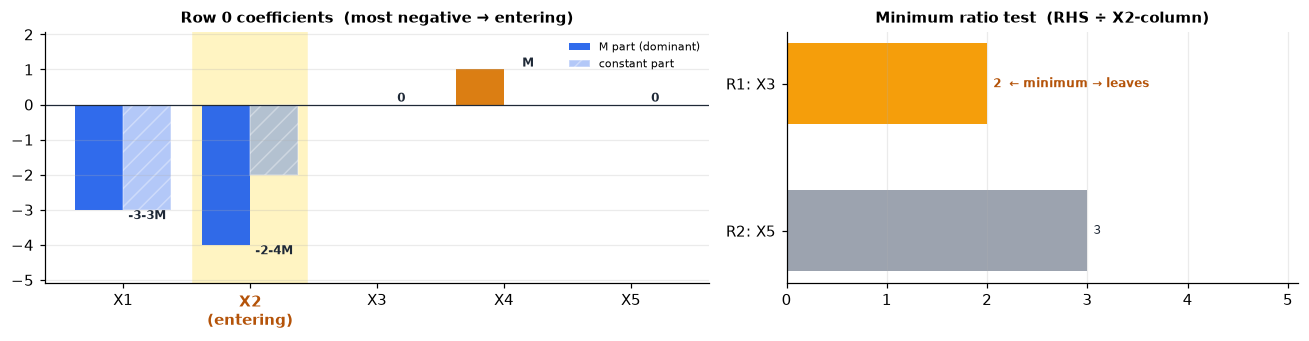

**Iteration 1 - scaling the pivot row.** Pivot number is already 1 - scaling not needed (normally divide the pivot row by the pivot number) → the pivot number becomes 1.

Basic,Eq.,Z,X1,X2,X3,X4,X5,RHS,Ratio
Z,0,1,-3-3M,-2-4M,0,M,0,-12M,
X3,1,0,2,1,1,0,0,2,2
X5,2,0,3,4,0,-1,1,12,3


**Iteration 1 - eliminating X2 from the other rows** (to obtain 0 in every other row of the pivot column):  
• Add (2+4M) × R1 to R0  
• Subtract 4 × R1 from R2  
X2 replaced X3 in the basis.  Current Z = 4-4M.

Basic,Eq.,Z,X1,X2,X3,X4,X5,RHS
Z,0,1,1+5M,0,2+4M,M,0,4-4M
X2,1,0,2,1,1,0,0,2
X5,2,0,-5,0,-4,-1,1,4


**Final check.**  
• Infeasible: row 0 has no negative values but artificial variable(s) X5 remain in the basis at a positive level.

Basic,Eq.,Z,X1,X2,X3,X4,X5,RHS
Z,0,1,1+5M,0,2+4M,M,0,4-4M
X2,1,0,2,1,1,0,0,2
X5,2,0,-5,0,-4,-1,1,4


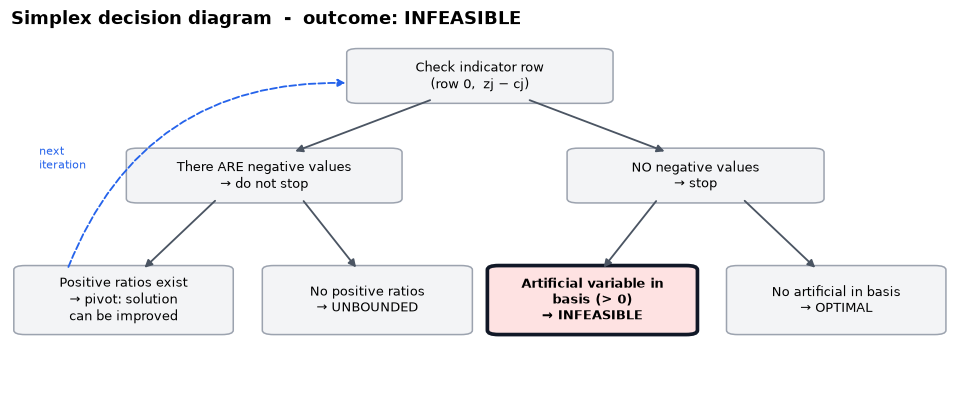

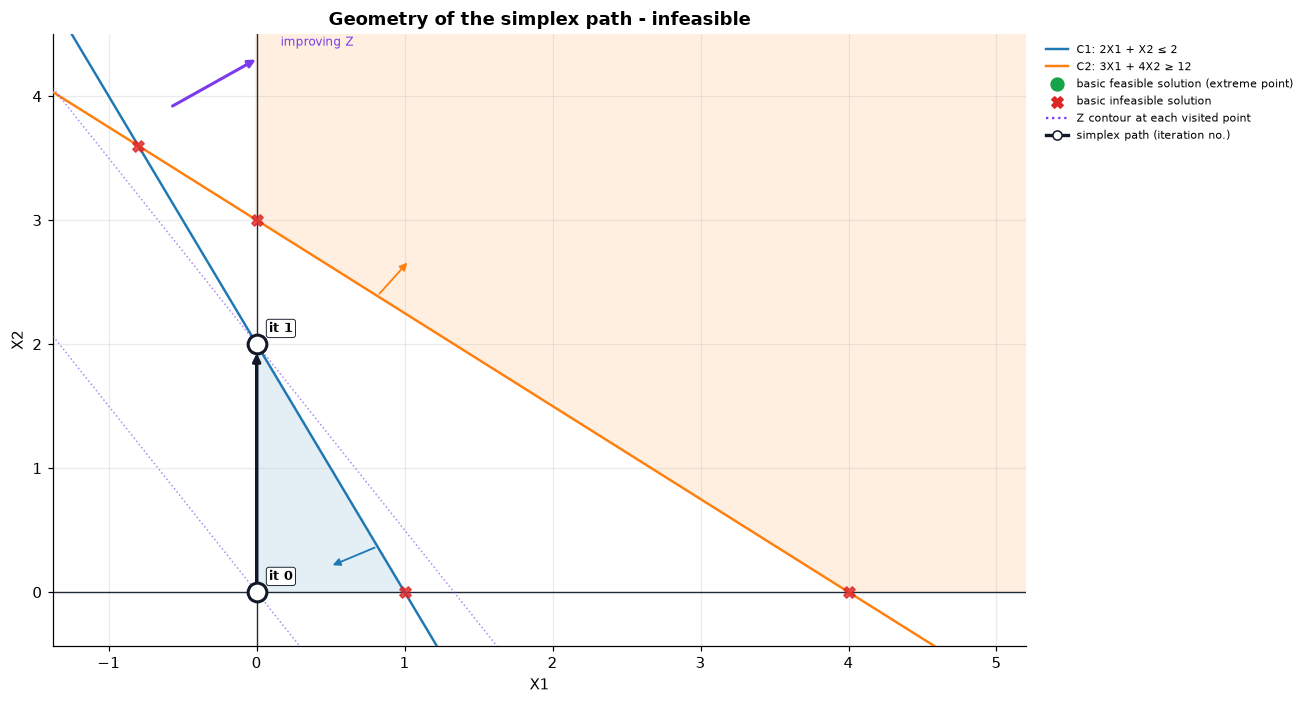

PDF: reports\case_infeasible_report.pdf


In [36]:
r = case_results["case_infeasible.json"]
walkthrough(r); plot_geometry(r); plt.show()
print("PDF:", export_pdf_report(r))

### 9.3 Minimisation with an equality constraint
Multiply by −1, maximise $Z'=-Z$, and convert back at the end. Two artificial variables are needed (one for ≥, one for =).

#### Transformation steps
1. The objective is **minimisation** → multiply by −1 and **maximise** Z′ = −Z (lecture slide 9). The final answer is converted back with Z = −Z′.
2. **C1** (Type I, ≤): add slack **X3** ≥ 0 (unused resource, cost 0) → X3 is the starting basic variable of this row.
3. **C2** (Type II, ≥): subtract surplus **X4** ≥ 0 (cost 0). Its column is −1, so it cannot start in the basis → an artificial variable is needed.
4. **C3** (=): already an equation, but it has no obvious basic variable → an artificial variable is needed.
5. **C2**: add artificial **X5** ≥ 0 with objective coefficient **−M** (huge penalty) → it provides an immediately recognisable starting basic variable.
6. **C3**: add artificial **X6** ≥ 0 with objective coefficient **−M** (huge penalty) → it provides an immediately recognisable starting basic variable.

#### Standard form$$\begin{aligned}\text{Maximize}\quad & Z' = -2X_{1} - 3X_{2} - M\,X_{5} - M\,X_{6} \\
\text{subject to}\quad & \\
& 0.5X_{1} + 0.25X_{2} + X_{3} = 4 \qquad (\text{C1}) \\
& X_{1} + 3X_{2} - X_{4} + X_{5} = 20 \qquad (\text{C2}) \\
& X_{1} + X_{2} + X_{6} = 10 \qquad (\text{C3}) \\
& X_{1}, X_{2}, X_{3}, X_{4}, X_{5}, X_{6} \ge 0\end{aligned}$$

Variable,Kind,Role,Objective coef.,Starts basic?
X1,decision,decision variable,-2,
X2,decision,decision variable,-3,
X3,slack,slack of C1,0,yes
X4,surplus,surplus of C2,0,
X5,artificial,artificial of C2,-M,yes
X6,artificial,artificial of C3,-M,yes


**Initial tableau.** Basic variables: X3 = 4, X5 = 20, X6 = 10. Non-basic (set to 0): X1, X2, X4. The values of the basic variables are read directly from the RHS column.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS
Z,0,1,2,3,0,0,M,M,0
X3,1,0,0.5,0.25,1,0,0,0,4
X5,2,0,1,3,0,-1,1,0,20
X6,3,0,1,1,0,0,0,1,10


**Big-M preparation.** the artificial basic variable(s) had coefficient M in row 0. Subtracting M × their rows makes those coefficients zero, so row 0 is ready for the optimality test.  
• Subtract M × R2 from R0  (make the coefficient of basic X5 zero)  
• Subtract M × R3 from R0  (make the coefficient of basic X6 zero)

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS
Z,0,1,2-2M,3-4M,0,M,0,0,-30M
X3,1,0,0.5,0.25,1,0,0,0,4
X5,2,0,1,3,0,-1,1,0,20
X6,3,0,1,1,0,0,0,1,10


**Iteration 1 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X2** - it has the largest (in absolute value) negative coefficient in row 0 (3-4M).  
• Minimum ratio test (RHS ÷ positive entries of the X2-column): R1: 16, R2: 6.6667, R3: 10.  
• **Leaving basic variable: X5** (row 2, smallest ratio). Pivot number = 3.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS,Ratio
Z,0,1,2-2M,3-4M,0,M,0,0,-30M,
X3,1,0,0.5,0.25,1,0,0,0,4,16
X5,2,0,1,3,0,-1,1,0,20,6.6667
X6,3,0,1,1,0,0,0,1,10,10


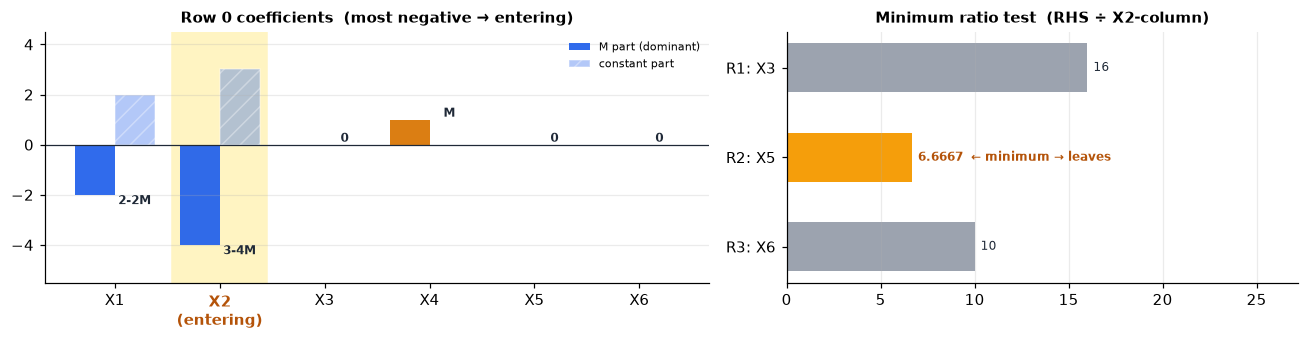

**Iteration 1 - scaling the pivot row.** Divide R2 by the pivot number 3 → the pivot number becomes 1.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS,Ratio
Z,0,1,2-2M,3-4M,0,M,0,0,-30M,
X3,1,0,0.5,0.25,1,0,0,0,4,16
X5,2,0,0.3333,1,0,-0.3333,0.3333,0,6.6667,6.6667
X6,3,0,1,1,0,0,0,1,10,10


**Iteration 1 - eliminating X2 from the other rows** (to obtain 0 in every other row of the pivot column):  
• Add (-3+4M) × R2 to R0  
• Subtract 0.25 × R2 from R1  
• Subtract 1 × R2 from R3  
X2 replaced X5 in the basis.  Current Z = -20-3.3333M.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS
Z,0,1,1-0.6667M,0,0,1-0.3333M,-1+1.3333M,0,-20-3.3333M
X3,1,0,0.4167,0,1,0.0833,-0.0833,0,2.3333
X2,2,0,0.3333,1,0,-0.3333,0.3333,0,6.6667
X6,3,0,0.6667,0,0,0.3333,-0.3333,1,3.3333


**Iteration 2 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X1** - it has the largest (in absolute value) negative coefficient in row 0 (1-0.6667M).  
• Minimum ratio test (RHS ÷ positive entries of the X1-column): R1: 5.6, R2: 20, R3: 5.  
• **Leaving basic variable: X6** (row 3, smallest ratio). Pivot number = 0.6667.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS,Ratio
Z,0,1,1-0.6667M,0,0,1-0.3333M,-1+1.3333M,0,-20-3.3333M,
X3,1,0,0.4167,0,1,0.0833,-0.0833,0,2.3333,5.6
X2,2,0,0.3333,1,0,-0.3333,0.3333,0,6.6667,20
X6,3,0,0.6667,0,0,0.3333,-0.3333,1,3.3333,5


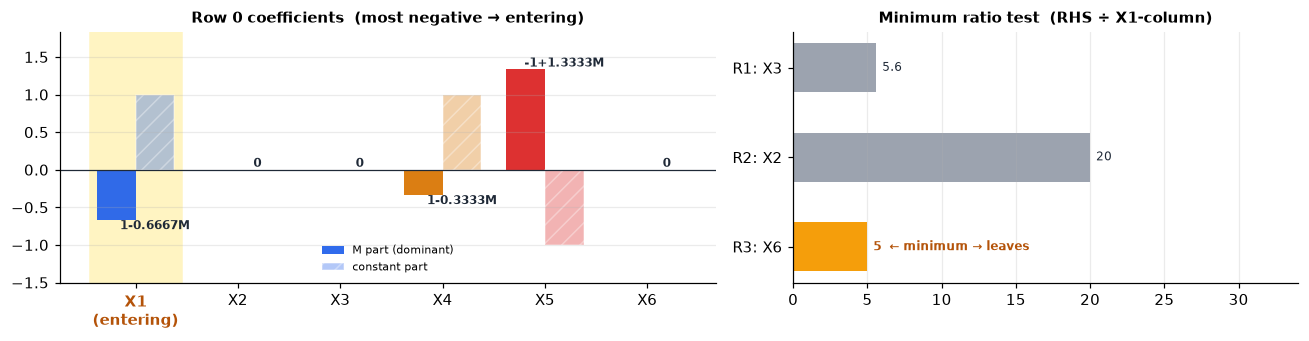

**Iteration 2 - scaling the pivot row.** Divide R3 by the pivot number 0.6667 → the pivot number becomes 1.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS,Ratio
Z,0,1,1-0.6667M,0,0,1-0.3333M,-1+1.3333M,0,-20-3.3333M,
X3,1,0,0.4167,0,1,0.0833,-0.0833,0,2.3333,5.6
X2,2,0,0.3333,1,0,-0.3333,0.3333,0,6.6667,20
X6,3,0,1,0,0,0.5,-0.5,1.5,5,5


**Iteration 2 - eliminating X1 from the other rows** (to obtain 0 in every other row of the pivot column):  
• Add (-1+0.6667M) × R3 to R0  
• Subtract 0.4167 × R3 from R1  
• Subtract 0.3333 × R3 from R2  
X1 replaced X6 in the basis.  Current Z = -25.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS
Z,0,1,0,0,0,0.5,-0.5+M,-1.5+M,-25
X3,1,0,0,0,1,-0.125,0.125,-0.625,0.25
X2,2,0,0,1,0,-0.5,0.5,-0.5,5
X1,3,0,1,0,0,0.5,-0.5,1.5,5


**Final check.**  
• Optimal: row 0 has no negative coefficients. Z* = 25 (converted back: Z = −Z′)

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,RHS
Z,0,1,0,0,0,0.5,-0.5+M,-1.5+M,-25
X3,1,0,0,0,1,-0.125,0.125,-0.625,0.25
X2,2,0,0,1,0,-0.5,0.5,-0.5,5
X1,3,0,1,0,0,0.5,-0.5,1.5,5


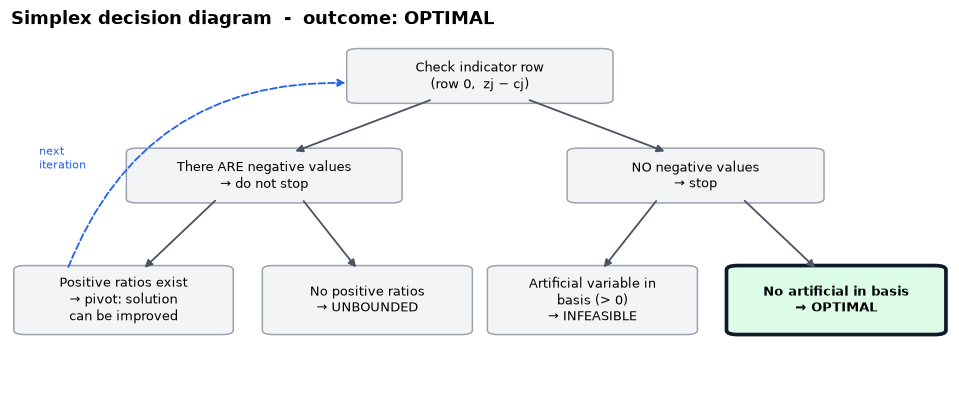

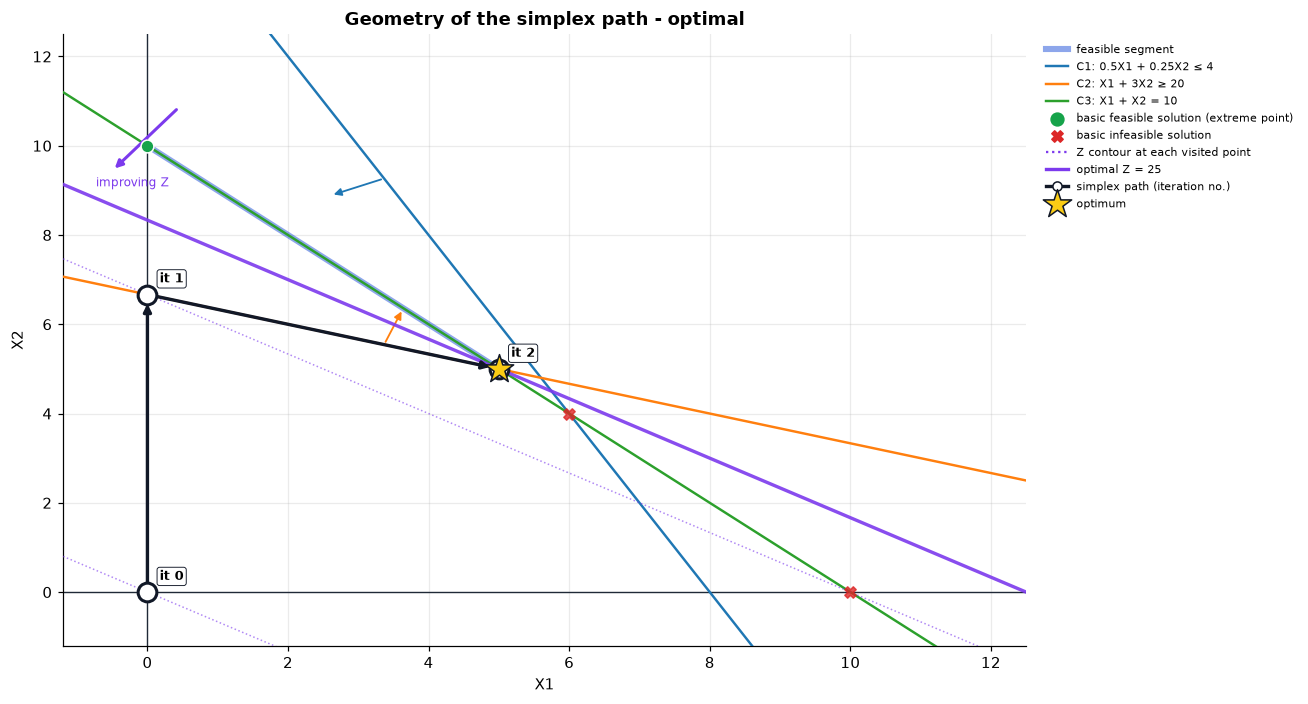

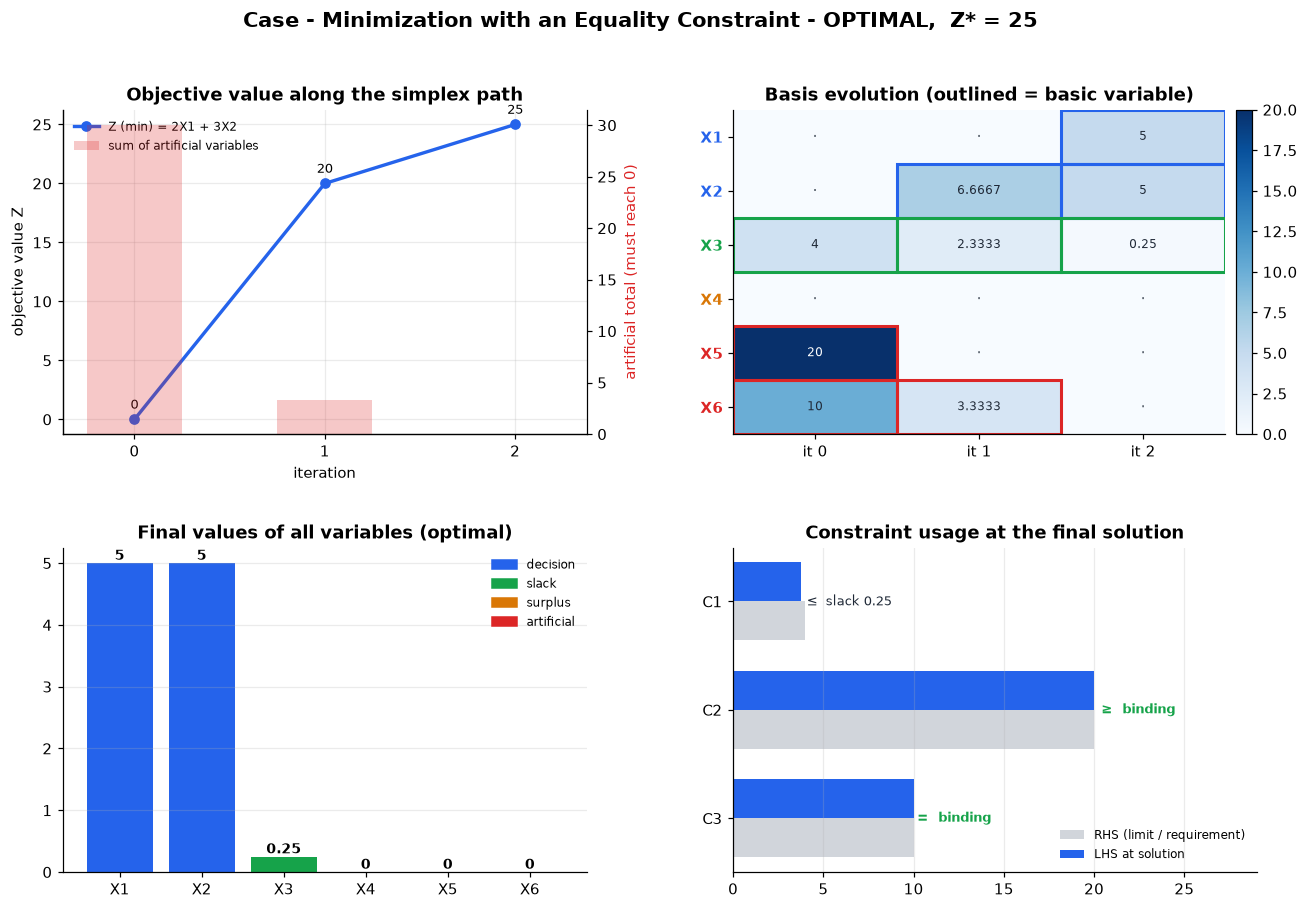

PDF: reports\case_minimization_report.pdf


In [37]:
r = case_results["case_minimization.json"]
show_standard_form(r.sf); walkthrough(r); plot_geometry(r); plt.show(); dashboard(r); plt.show()
print("PDF:", export_pdf_report(r))

### 9.4 Alternative optimal solutions
The objective $2X_1+4X_2$ is parallel to $X_1+2X_2\le5$: the whole edge is optimal. At the final tableau $X_1$ is non-basic with **0** in row 0.

**Initial tableau.** Basic variables: X3 = 5, X4 = 4. Non-basic (set to 0): X1, X2. The values of the basic variables are read directly from the RHS column.

Basic,Eq.,Z,X1,X2,X3,X4,RHS
Z,0,1,-2,-4,0,0,0
X3,1,0,1,2,1,0,5
X4,2,0,1,1,0,1,4


**Iteration 1 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X2** - it has the largest (in absolute value) negative coefficient in row 0 (-4).  
• Minimum ratio test (RHS ÷ positive entries of the X2-column): R1: 2.5, R2: 4.  
• **Leaving basic variable: X3** (row 1, smallest ratio). Pivot number = 2.

Basic,Eq.,Z,X1,X2,X3,X4,RHS,Ratio
Z,0,1,-2,-4,0,0,0,
X3,1,0,1,2,1,0,5,2.5
X4,2,0,1,1,0,1,4,4


**Iteration 1 - scaling the pivot row.** Divide R1 by the pivot number 2 → the pivot number becomes 1.

Basic,Eq.,Z,X1,X2,X3,X4,RHS,Ratio
Z,0,1,-2,-4,0,0,0,
X3,1,0,0.5,1,0.5,0,2.5,2.5
X4,2,0,1,1,0,1,4,4


**Iteration 1 - eliminating X2 from the other rows** (to obtain 0 in every other row of the pivot column):  
• Add 4 × R1 to R0  
• Subtract 1 × R1 from R2  
X2 replaced X3 in the basis.  Current Z = 10.

Basic,Eq.,Z,X1,X2,X3,X4,RHS
Z,0,1,0,0,2,0,10
X2,1,0,0.5,1,0.5,0,2.5
X4,2,0,0.5,0,-0.5,1,1.5


**Final check.**  
• Optimal: row 0 has no negative coefficients. Z* = 10  
• Alternative optima: non-basic X1 has a zero coefficient in row 0 - bringing it in changes the solution but not Z.

Basic,Eq.,Z,X1,X2,X3,X4,RHS
Z,0,1,0,0,2,0,10
X2,1,0,0.5,1,0.5,0,2.5
X4,2,0,0.5,0,-0.5,1,1.5


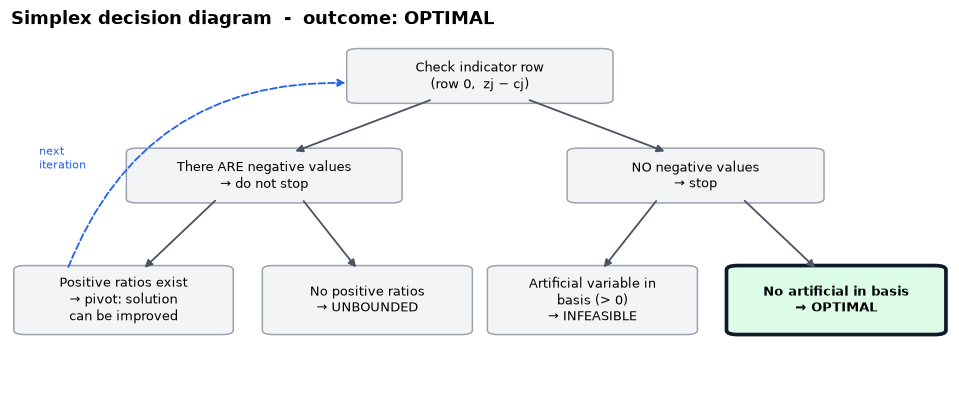

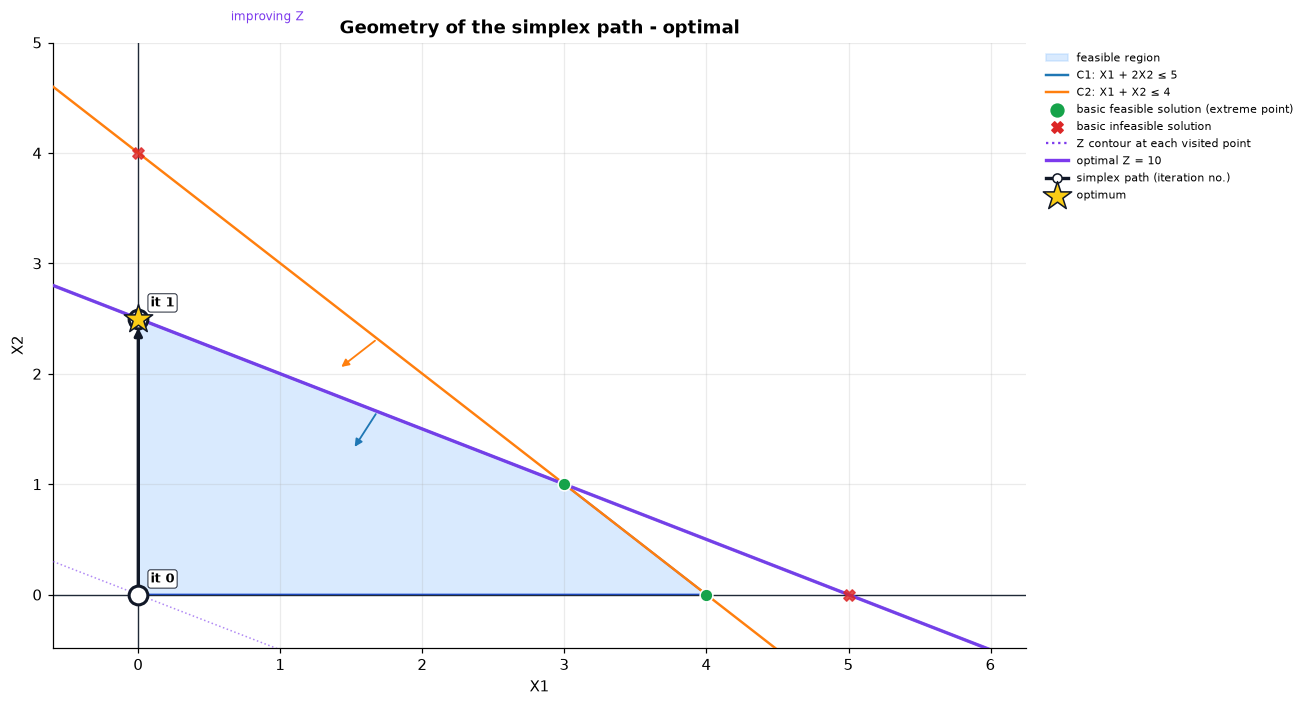

['Optimal: row 0 has no negative coefficients. Z* = 10', 'Alternative optima: non-basic X1 has a zero coefficient in row 0 - bringing it in changes the solution but not Z.']
PDF: reports\case_alternative_optima_report.pdf


In [38]:
r = case_results["case_alternative_optima.json"]
walkthrough(r, charts=False); plot_geometry(r); plt.show()
print(r.messages)
print("PDF:", export_pdf_report(r))

## 10. Practice problems
### 10.1 Three-product production plan (3-D)
One call of `solve_file()` does everything: model, standard form, all tableaux, 3-D polytope with the path, dashboard, verification and the PDF.

**Practice - Three-Product Production Plan**  
*A workshop makes products A, B, C (X1, X2, X3 units/week). Profit per unit 30, 40, 35. Machining, assembly and material capacities are limited, and a contract requires at least 10 units of B.*

$$\begin{aligned}\text{Maximize}\quad & Z = 30X_{1} + 40X_{2} + 35X_{3} \\
\text{subject to}\quad & \\
& 2X_{1} + 3X_{2} + 2X_{3} \le 120 \qquad (\text{Machining (h)}) \\
& 4X_{1} + 2X_{2} + 3X_{3} \le 160 \qquad (\text{Assembly (h)}) \\
& 3X_{1} + 2X_{2} + 4X_{3} \le 140 \qquad (\text{Material (kg)}) \\
& X_{2} \ge 10 \qquad (\text{Contract B}) \\
& X_{1}, X_{2}, X_{3} \ge 0\end{aligned}$$

#### Transformation steps
1. **Machining (h)** (Type I, ≤): add slack **X4** ≥ 0 (unused resource, cost 0) → X4 is the starting basic variable of this row.
2. **Assembly (h)** (Type I, ≤): add slack **X5** ≥ 0 (unused resource, cost 0) → X5 is the starting basic variable of this row.
3. **Material (kg)** (Type I, ≤): add slack **X6** ≥ 0 (unused resource, cost 0) → X6 is the starting basic variable of this row.
4. **Contract B** (Type II, ≥): subtract surplus **X7** ≥ 0 (cost 0). Its column is −1, so it cannot start in the basis → an artificial variable is needed.
5. **Contract B**: add artificial **X8** ≥ 0 with objective coefficient **−M** (huge penalty) → it provides an immediately recognisable starting basic variable.

#### Standard form$$\begin{aligned}\text{Maximize}\quad & Z = 30X_{1} + 40X_{2} + 35X_{3} - M\,X_{8} \\
\text{subject to}\quad & \\
& 2X_{1} + 3X_{2} + 2X_{3} + X_{4} = 120 \qquad (\text{Machining (h)}) \\
& 4X_{1} + 2X_{2} + 3X_{3} + X_{5} = 160 \qquad (\text{Assembly (h)}) \\
& 3X_{1} + 2X_{2} + 4X_{3} + X_{6} = 140 \qquad (\text{Material (kg)}) \\
& X_{2} - X_{7} + X_{8} = 10 \qquad (\text{Contract B}) \\
& X_{1}, X_{2}, X_{3}, X_{4}, X_{5}, X_{6}, X_{7}, X_{8} \ge 0\end{aligned}$$

Variable,Kind,Role,Objective coef.,Starts basic?
X1,decision,decision variable,30,
X2,decision,decision variable,40,
X3,decision,decision variable,35,
X4,slack,slack of Machining (h),0,yes
X5,slack,slack of Assembly (h),0,yes
X6,slack,slack of Material (kg),0,yes
X7,surplus,surplus of Contract B,0,
X8,artificial,artificial of Contract B,-M,yes


...

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,RHS
Z,0,1,-30,-40,-35,0,0,0,0,M,0
X4,1,0,2,3,2,1,0,0,0,0,120
X5,2,0,4,2,3,0,1,0,0,0,160
X6,3,0,3,2,4,0,0,1,0,0,140
X8,4,0,0,1,0,0,0,0,-1,1,10


**Big-M preparation.** the artificial basic variable(s) had coefficient M in row 0. Subtracting M × their rows makes those coefficients zero, so row 0 is ready for the optimality test.  
• Subtract M × R4 from R0  (make the coefficient of basic X8 zero)

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,RHS
Z,0,1,-30,-40-M,-35,0,0,0,M,0,-10M
X4,1,0,2,3,2,1,0,0,0,0,120
X5,2,0,4,2,3,0,1,0,0,0,160
X6,3,0,3,2,4,0,0,1,0,0,140
X8,4,0,0,1,0,0,0,0,-1,1,10


**Iteration 1 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X2** - it has the largest (in absolute value) negative coefficient in row 0 (-40-M).  
• Minimum ratio test (RHS ÷ positive entries of the X2-column): R1: 40, R2: 80, R3: 70, R4: 10.  
• **Leaving basic variable: X8** (row 4, smallest ratio). Pivot number = 1.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,RHS,Ratio
Z,0,1,-30,-40-M,-35,0,0,0,M,0,-10M,
X4,1,0,2,3,2,1,0,0,0,0,120,40
X5,2,0,4,2,3,0,1,0,0,0,160,80
X6,3,0,3,2,4,0,0,1,0,0,140,70
X8,4,0,0,1,0,0,0,0,-1,1,10,10


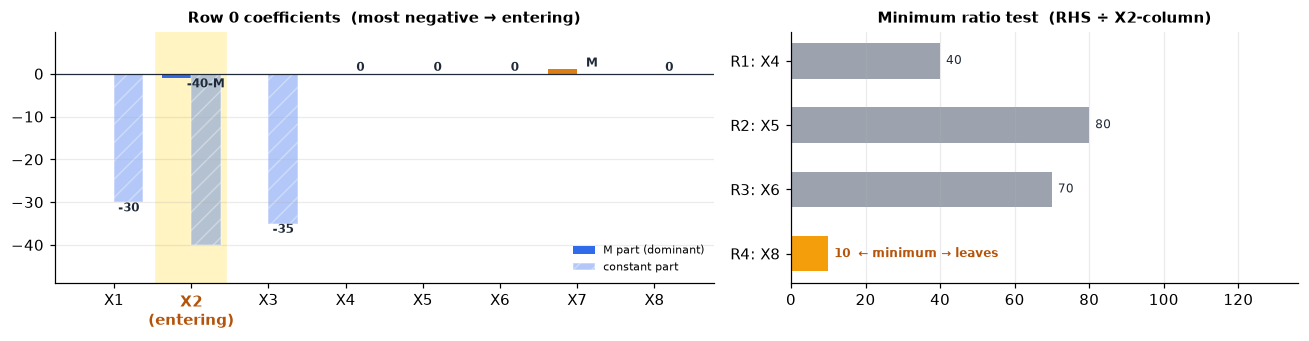

**Iteration 1 - scaling the pivot row.** Pivot number is already 1 - scaling not needed (normally divide the pivot row by the pivot number) → the pivot number becomes 1.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,RHS,Ratio
Z,0,1,-30,-40-M,-35,0,0,0,M,0,-10M,
X4,1,0,2,3,2,1,0,0,0,0,120,40
X5,2,0,4,2,3,0,1,0,0,0,160,80
X6,3,0,3,2,4,0,0,1,0,0,140,70
X8,4,0,0,1,0,0,0,0,-1,1,10,10


**Iteration 1 - eliminating X2 from the other rows** (to obtain 0 in every other row of the pivot column):  
• Add (40+M) × R4 to R0  
• Subtract 3 × R4 from R1  
• Subtract 2 × R4 from R2  
• Subtract 2 × R4 from R3  
X2 replaced X8 in the basis.  Current Z = 400.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,RHS
Z,0,1,-30,0,-35,0,0,0,-40,40+M,400
X4,1,0,2,0,2,1,0,0,3,-3,90
X5,2,0,4,0,3,0,1,0,2,-2,140
X6,3,0,3,0,4,0,0,1,2,-2,120
X2,4,0,0,1,0,0,0,0,-1,1,10


**Iteration 2 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X7** - it has the largest (in absolute value) negative coefficient in row 0 (-40).  
• Minimum ratio test (RHS ÷ positive entries of the X7-column): R1: 30, R2: 70, R3: 60, R4: -ve.  
• **Leaving basic variable: X4** (row 1, smallest ratio). Pivot number = 3.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,RHS,Ratio
Z,0,1,-30,0,-35,0,0,0,-40,40+M,400,
X4,1,0,2,0,2,1,0,0,3,-3,90,30
X5,2,0,4,0,3,0,1,0,2,-2,140,70
X6,3,0,3,0,4,0,0,1,2,-2,120,60
X2,4,0,0,1,0,0,0,0,-1,1,10,-ve


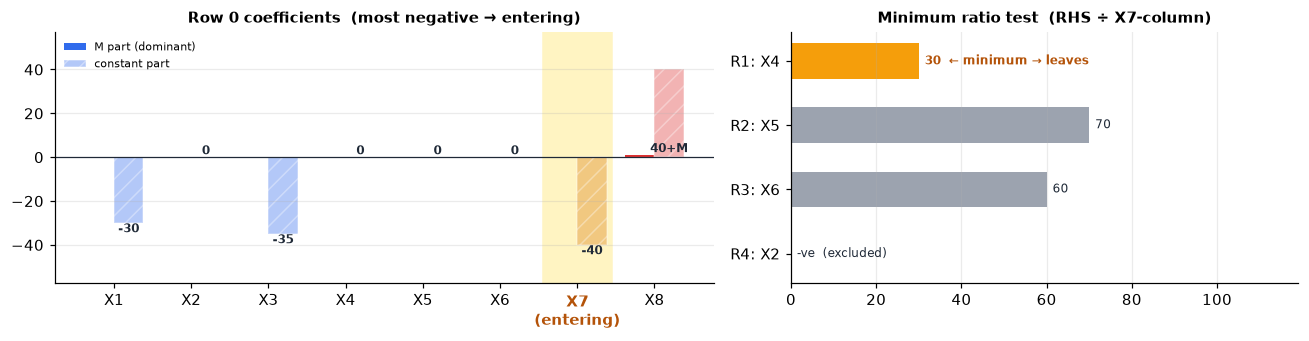

**Iteration 2 - scaling the pivot row.** Divide R1 by the pivot number 3 → the pivot number becomes 1.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,RHS,Ratio
Z,0,1,-30,0,-35,0,0,0,-40,40+M,400,
X4,1,0,0.6667,0,0.6667,0.3333,0,0,1,-1,30,30
X5,2,0,4,0,3,0,1,0,2,-2,140,70
X6,3,0,3,0,4,0,0,1,2,-2,120,60
X2,4,0,0,1,0,0,0,0,-1,1,10,-ve


**Iteration 2 - eliminating X7 from the other rows** (to obtain 0 in every other row of the pivot column):  
• Add 40 × R1 to R0  
• Subtract 2 × R1 from R2  
• Subtract 2 × R1 from R3  
• Add 1 × R1 to R4  
X7 replaced X4 in the basis.  Current Z = 1600.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,RHS
Z,0,1,-3.3333,0,-8.3333,13.3333,0,0,0,M,1600
X7,1,0,0.6667,0,0.6667,0.3333,0,0,1,-1,30
X5,2,0,2.6667,0,1.6667,-0.6667,1,0,0,0,80
X6,3,0,1.6667,0,2.6667,-0.6667,0,1,0,0,60
X2,4,0,0.6667,1,0.6667,0.3333,0,0,0,0,40


**Iteration 3 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X3** - it has the largest (in absolute value) negative coefficient in row 0 (-8.3333).  
• Minimum ratio test (RHS ÷ positive entries of the X3-column): R1: 45, R2: 48, R3: 22.5, R4: 60.  
• **Leaving basic variable: X6** (row 3, smallest ratio). Pivot number = 2.6667.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,RHS,Ratio
Z,0,1,-3.3333,0,-8.3333,13.3333,0,0,0,M,1600,
X7,1,0,0.6667,0,0.6667,0.3333,0,0,1,-1,30,45
X5,2,0,2.6667,0,1.6667,-0.6667,1,0,0,0,80,48
X6,3,0,1.6667,0,2.6667,-0.6667,0,1,0,0,60,22.5
X2,4,0,0.6667,1,0.6667,0.3333,0,0,0,0,40,60


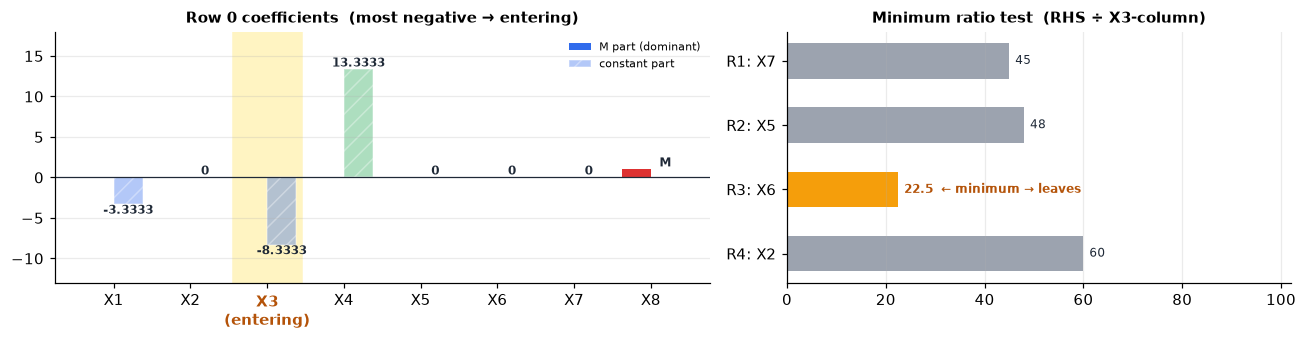

**Iteration 3 - scaling the pivot row.** Divide R3 by the pivot number 2.6667 → the pivot number becomes 1.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,RHS,Ratio
Z,0,1,-3.3333,0,-8.3333,13.3333,0,0,0,M,1600,
X7,1,0,0.6667,0,0.6667,0.3333,0,0,1,-1,30,45
X5,2,0,2.6667,0,1.6667,-0.6667,1,0,0,0,80,48
X6,3,0,0.625,0,1,-0.25,0,0.375,0,0,22.5,22.5
X2,4,0,0.6667,1,0.6667,0.3333,0,0,0,0,40,60


**Iteration 3 - eliminating X3 from the other rows** (to obtain 0 in every other row of the pivot column):  
• Add 8.3333 × R3 to R0  
• Subtract 0.6667 × R3 from R1  
• Subtract 1.6667 × R3 from R2  
• Subtract 0.6667 × R3 from R4  
X3 replaced X6 in the basis.  Current Z = 1787.5.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,RHS
Z,0,1,1.875,0,0,11.25,0,3.125,0,M,1787.5
X7,1,0,0.25,0,0,0.5,0,-0.25,1,-1,15
X5,2,0,1.625,0,0,-0.25,1,-0.625,0,0,42.5
X3,3,0,0.625,0,1,-0.25,0,0.375,0,0,22.5
X2,4,0,0.25,1,0,0.5,0,-0.25,0,0,25


**Final check.**  
• Optimal: row 0 has no negative coefficients. Z* = 1787.5

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,RHS
Z,0,1,1.875,0,0,11.25,0,3.125,0,M,1787.5
X7,1,0,0.25,0,0,0.5,0,-0.25,1,-1,15
X5,2,0,1.625,0,0,-0.25,1,-0.625,0,0,42.5
X3,3,0,0.625,0,1,-0.25,0,0.375,0,0,22.5
X2,4,0,0.25,1,0,0.5,0,-0.25,0,0,25


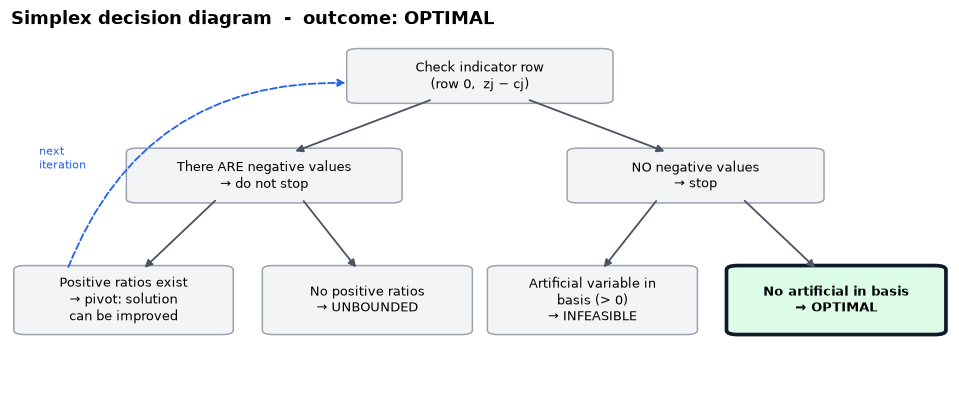

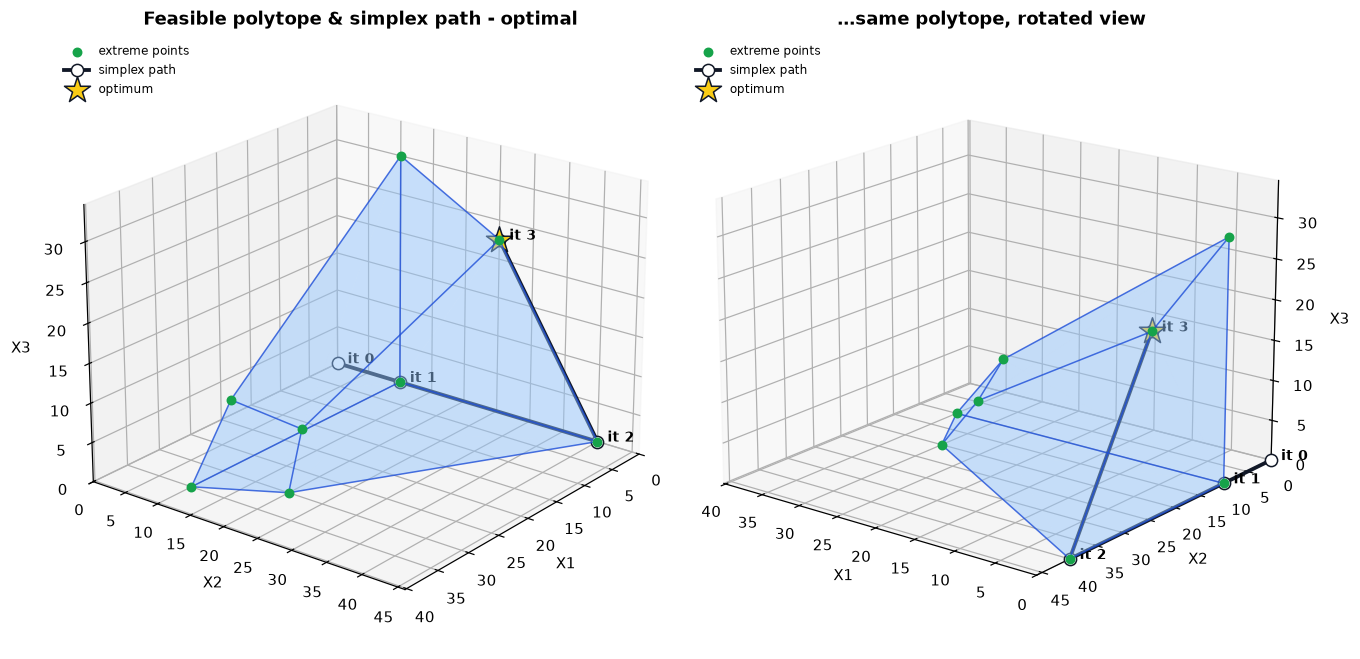

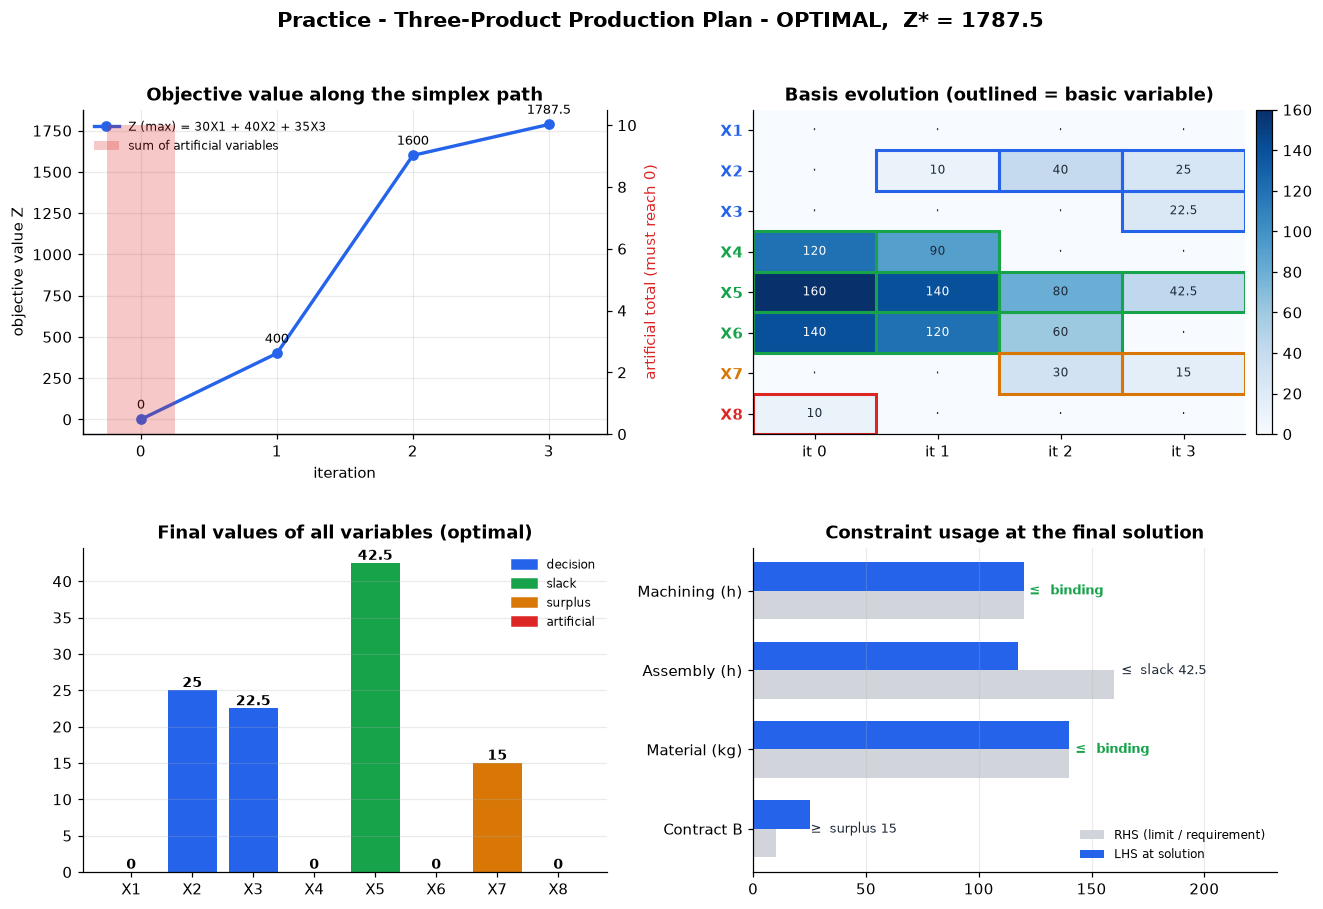

quantity,our tableau simplex,SciPy HiGHS
status,optimal,optimal
Z,1787.5,1787.5
X1,0,0
X2,25,25
X3,22.5,22.5


> Optimal: row 0 has no negative coefficients. Z* = 1787.5

📄 PDF report written to `reports\production_planning_report.pdf`

In [39]:
res_pp = solve_file("data/production_planning.json")

### 10.2 Four-ingredient blending (minimise cost, 4 variables)
No geometric picture is possible with four variables, but the tableau charts, basis-evolution heatmap and constraint-usage chart still tell the whole story.

**Practice - Four-Ingredient Blending (Minimize Cost)**  
*Blend 100 kg of feed from four ingredients (X1..X4 kg) at minimum cost ($/kg 0.30, 0.25, 0.40, 0.20) meeting protein and fibre specs and an availability limit on ingredient 3. Four variables: no geometric plot, but every tableau chart still applies.*

$$\begin{aligned}\text{Minimize}\quad & Z = 0.3X_{1} + 0.25X_{2} + 0.4X_{3} + 0.2X_{4} \\
\text{subject to}\quad & \\
& 0.2X_{1} + 0.3X_{2} + 0.4X_{3} + 0.1X_{4} \ge 22 \qquad (\text{Protein (kg)}) \\
& 0.05X_{1} + 0.1X_{2} + 0.02X_{3} + 0.15X_{4} \le 8 \qquad (\text{Fibre (kg)}) \\
& X_{1} + X_{2} + X_{3} + X_{4} = 100 \qquad (\text{Total (kg)}) \\
& X_{3} \le 30 \qquad (\text{X3 availability}) \\
& X_{1}, X_{2}, X_{3}, X_{4} \ge 0\end{aligned}$$

#### Transformation steps
1. The objective is **minimisation** → multiply by −1 and **maximise** Z′ = −Z (lecture slide 9). The final answer is converted back with Z = −Z′.
2. **Protein (kg)** (Type II, ≥): subtract surplus **X5** ≥ 0 (cost 0). Its column is −1, so it cannot start in the basis → an artificial variable is needed.
3. **Fibre (kg)** (Type I, ≤): add slack **X6** ≥ 0 (unused resource, cost 0) → X6 is the starting basic variable of this row.
4. **Total (kg)** (=): already an equation, but it has no obvious basic variable → an artificial variable is needed.
5. **X3 availability** (Type I, ≤): add slack **X7** ≥ 0 (unused resource, cost 0) → X7 is the starting basic variable of this row.
6. **Protein (kg)**: add artificial **X8** ≥ 0 with objective coefficient **−M** (huge penalty) → it provides an immediately recognisable starting basic variable.
7. **Total (kg)**: add artificial **X9** ≥ 0 with objective coefficient **−M** (huge penalty) → it provides an immediately recognisable starting basic variable.

#### Standard form$$\begin{aligned}\text{Maximize}\quad & Z' = -0.3X_{1} - 0.25X_{2} - 0.4X_{3} - 0.2X_{4} - M\,X_{8} - M\,X_{9} \\
\text{subject to}\quad & \\
& 0.2X_{1} + 0.3X_{2} + 0.4X_{3} + 0.1X_{4} - X_{5} + X_{8} = 22 \qquad (\text{Protein (kg)}) \\
& 0.05X_{1} + 0.1X_{2} + 0.02X_{3} + 0.15X_{4} + X_{6} = 8 \qquad (\text{Fibre (kg)}) \\
& X_{1} + X_{2} + X_{3} + X_{4} + X_{9} = 100 \qquad (\text{Total (kg)}) \\
& X_{3} + X_{7} = 30 \qquad (\text{X3 availability}) \\
& X_{1}, X_{2}, X_{3}, X_{4}, X_{5}, X_{6}, X_{7}, X_{8}, X_{9} \ge 0\end{aligned}$$

Variable,Kind,Role,Objective coef.,Starts basic?
X1,decision,decision variable,-0.3,
X2,decision,decision variable,-0.25,
X3,decision,decision variable,-0.4,
X4,decision,decision variable,-0.2,
X5,surplus,surplus of Protein (kg),0,
X6,slack,slack of Fibre (kg),0,yes
X7,slack,slack of X3 availability,0,yes
X8,artificial,artificial of Protein (kg),-M,yes
X9,artificial,artificial of Total (kg),-M,yes


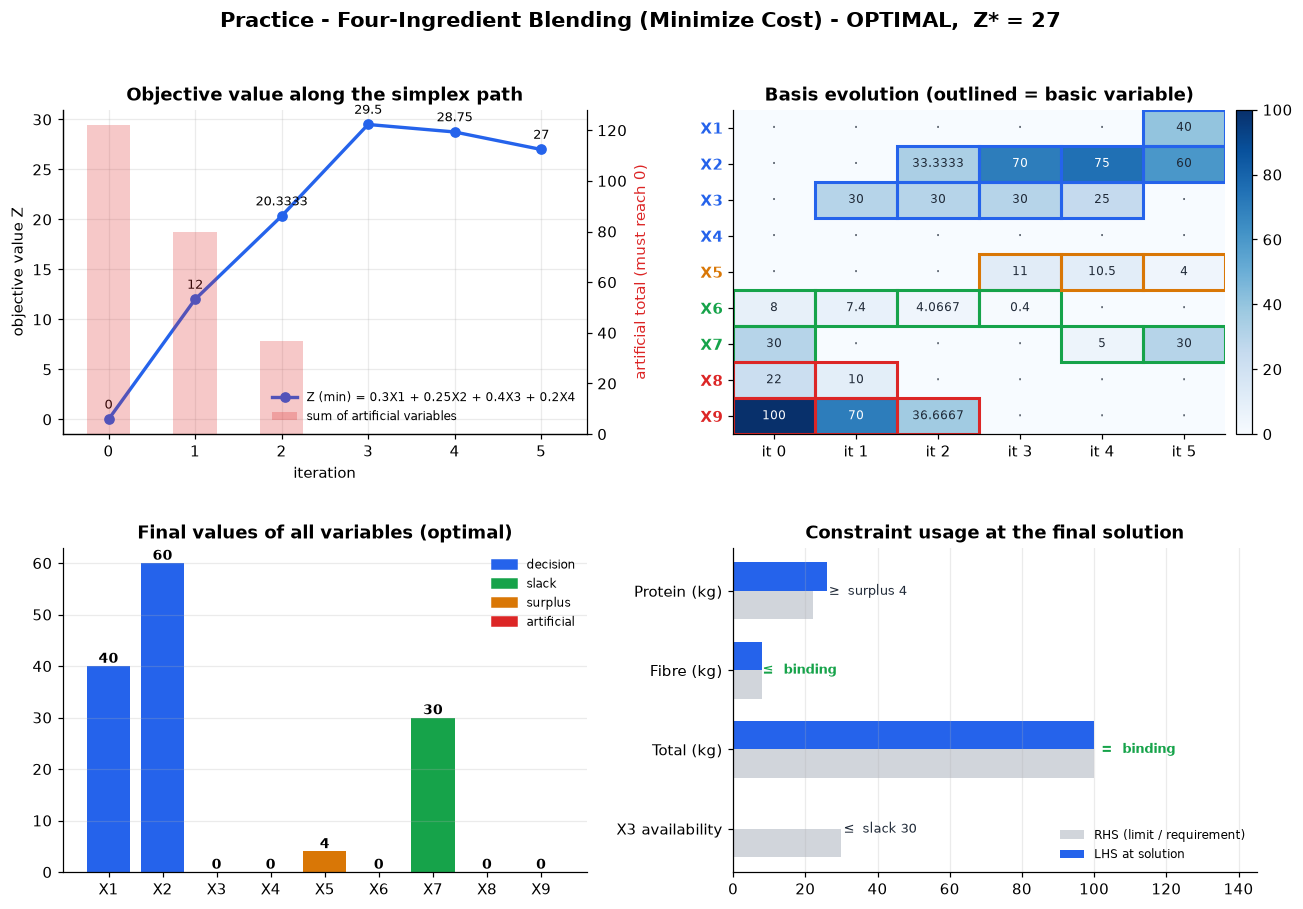

quantity,our tableau simplex,SciPy HiGHS
status,optimal,optimal
Z,27,27
X1,40,53.3333
X2,60,33.3333
X3,0,0
X4,0,13.3333


> Optimal: row 0 has no negative coefficients. Z* = 27 (converted back: Z = −Z′)

> Alternative optima: non-basic X4 has a zero coefficient in row 0 - bringing it in changes the solution but not Z.

📄 PDF report written to `reports\feed_blending_min_report.pdf`

**Initial tableau.** Basic variables: X8 = 22, X6 = 8, X9 = 100, X7 = 30. Non-basic (set to 0): X1, X2, X3, X4, X5. The values of the basic variables are read directly from the RHS column.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,X9,RHS
Z,0,1,0.3,0.25,0.4,0.2,0,0,0,M,M,0
X8,1,0,0.2,0.3,0.4,0.1,-1,0,0,1,0,22
X6,2,0,0.05,0.1,0.02,0.15,0,1,0,0,0,8
X9,3,0,1,1,1,1,0,0,0,0,1,100
X7,4,0,0,0,1,0,0,0,1,0,0,30


**Big-M preparation.** the artificial basic variable(s) had coefficient M in row 0. Subtracting M × their rows makes those coefficients zero, so row 0 is ready for the optimality test.  
• Subtract M × R1 from R0  (make the coefficient of basic X8 zero)  
• Subtract M × R3 from R0  (make the coefficient of basic X9 zero)

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,X9,RHS
Z,0,1,0.3-1.2M,0.25-1.3M,0.4-1.4M,0.2-1.1M,M,0,0,0,0,-122M
X8,1,0,0.2,0.3,0.4,0.1,-1,0,0,1,0,22
X6,2,0,0.05,0.1,0.02,0.15,0,1,0,0,0,8
X9,3,0,1,1,1,1,0,0,0,0,1,100
X7,4,0,0,0,1,0,0,0,1,0,0,30


**Iteration 1 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X3** - it has the largest (in absolute value) negative coefficient in row 0 (0.4-1.4M).  
• Minimum ratio test (RHS ÷ positive entries of the X3-column): R1: 55, R2: 400, R3: 100, R4: 30.  
• **Leaving basic variable: X7** (row 4, smallest ratio). Pivot number = 1.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,X9,RHS,Ratio
Z,0,1,0.3-1.2M,0.25-1.3M,0.4-1.4M,0.2-1.1M,M,0,0,0,0,-122M,
X8,1,0,0.2,0.3,0.4,0.1,-1,0,0,1,0,22,55
X6,2,0,0.05,0.1,0.02,0.15,0,1,0,0,0,8,400
X9,3,0,1,1,1,1,0,0,0,0,1,100,100
X7,4,0,0,0,1,0,0,0,1,0,0,30,30


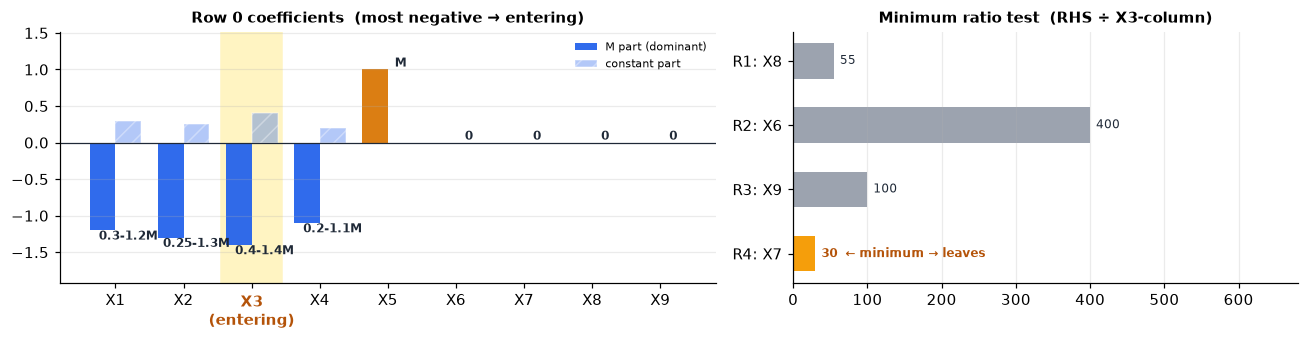

**Iteration 1 - scaling the pivot row.** Pivot number is already 1 - scaling not needed (normally divide the pivot row by the pivot number) → the pivot number becomes 1.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,X9,RHS,Ratio
Z,0,1,0.3-1.2M,0.25-1.3M,0.4-1.4M,0.2-1.1M,M,0,0,0,0,-122M,
X8,1,0,0.2,0.3,0.4,0.1,-1,0,0,1,0,22,55
X6,2,0,0.05,0.1,0.02,0.15,0,1,0,0,0,8,400
X9,3,0,1,1,1,1,0,0,0,0,1,100,100
X7,4,0,0,0,1,0,0,0,1,0,0,30,30


**Iteration 1 - eliminating X3 from the other rows** (to obtain 0 in every other row of the pivot column):  
• Add (-0.4+1.4M) × R4 to R0  
• Subtract 0.4 × R4 from R1  
• Subtract 0.02 × R4 from R2  
• Subtract 1 × R4 from R3  
X3 replaced X7 in the basis.  Current Z = -12-80M.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,X9,RHS
Z,0,1,0.3-1.2M,0.25-1.3M,0,0.2-1.1M,M,0,-0.4+1.4M,0,0,-12-80M
X8,1,0,0.2,0.3,0,0.1,-1,0,-0.4,1,0,10
X6,2,0,0.05,0.1,0,0.15,0,1,-0.02,0,0,7.4
X9,3,0,1,1,0,1,0,0,-1,0,1,70
X3,4,0,0,0,1,0,0,0,1,0,0,30


**Iteration 2 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X2** - it has the largest (in absolute value) negative coefficient in row 0 (0.25-1.3M).  
• Minimum ratio test (RHS ÷ positive entries of the X2-column): R1: 33.3333, R2: 74, R3: 70, R4: ∞.  
• **Leaving basic variable: X8** (row 1, smallest ratio). Pivot number = 0.3.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,X9,RHS,Ratio
Z,0,1,0.3-1.2M,0.25-1.3M,0,0.2-1.1M,M,0,-0.4+1.4M,0,0,-12-80M,
X8,1,0,0.2,0.3,0,0.1,-1,0,-0.4,1,0,10,33.3333
X6,2,0,0.05,0.1,0,0.15,0,1,-0.02,0,0,7.4,74
X9,3,0,1,1,0,1,0,0,-1,0,1,70,70
X3,4,0,0,0,1,0,0,0,1,0,0,30,∞


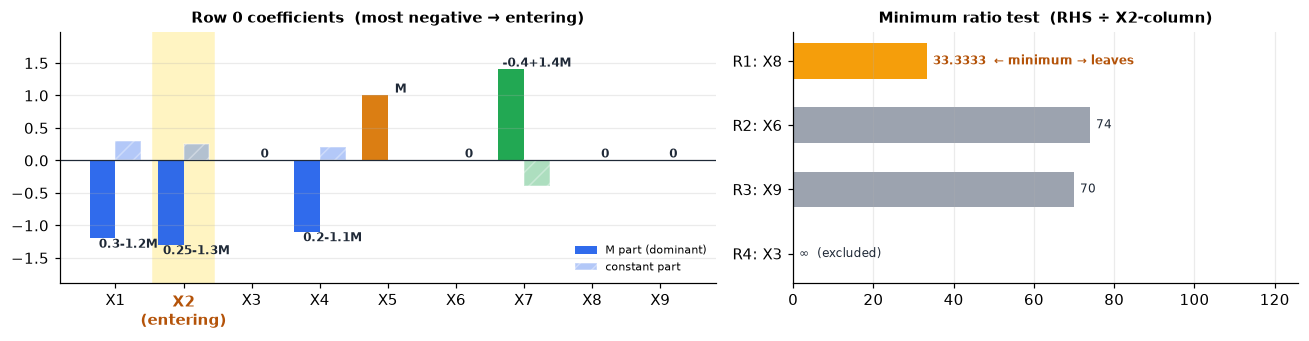

**Iteration 2 - scaling the pivot row.** Divide R1 by the pivot number 0.3 → the pivot number becomes 1.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,X9,RHS,Ratio
Z,0,1,0.3-1.2M,0.25-1.3M,0,0.2-1.1M,M,0,-0.4+1.4M,0,0,-12-80M,
X8,1,0,0.6667,1,0,0.3333,-3.3333,0,-1.3333,3.3333,0,33.3333,33.3333
X6,2,0,0.05,0.1,0,0.15,0,1,-0.02,0,0,7.4,74
X9,3,0,1,1,0,1,0,0,-1,0,1,70,70
X3,4,0,0,0,1,0,0,0,1,0,0,30,∞


**Iteration 2 - eliminating X2 from the other rows** (to obtain 0 in every other row of the pivot column):  
• Add (-0.25+1.3M) × R1 to R0  
• Subtract 0.1 × R1 from R2  
• Subtract 1 × R1 from R3  
X2 replaced X8 in the basis.  Current Z = -20.3333-36.6667M.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,X9,RHS
Z,0,1,0.1333-0.3333M,0,0,0.1167-0.6667M,0.8333-3.3333M,0,-0.0667-0.3333M,-0.8333+4.3333M,0,-20.3333-36.6667M
X2,1,0,0.6667,1,0,0.3333,-3.3333,0,-1.3333,3.3333,0,33.3333
X6,2,0,-0.0167,0,0,0.1167,0.3333,1,0.1133,-0.3333,0,4.0667
X9,3,0,0.3333,0,0,0.6667,3.3333,0,0.3333,-3.3333,1,36.6667
X3,4,0,0,0,1,0,0,0,1,0,0,30


**Iteration 3 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X5** - it has the largest (in absolute value) negative coefficient in row 0 (0.8333-3.3333M).  
• Minimum ratio test (RHS ÷ positive entries of the X5-column): R1: -ve, R2: 12.2, R3: 11, R4: ∞.  
• **Leaving basic variable: X9** (row 3, smallest ratio). Pivot number = 3.3333.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,X9,RHS,Ratio
Z,0,1,0.1333-0.3333M,0,0,0.1167-0.6667M,0.8333-3.3333M,0,-0.0667-0.3333M,-0.8333+4.3333M,0,-20.3333-36.6667M,
X2,1,0,0.6667,1,0,0.3333,-3.3333,0,-1.3333,3.3333,0,33.3333,-ve
X6,2,0,-0.0167,0,0,0.1167,0.3333,1,0.1133,-0.3333,0,4.0667,12.2
X9,3,0,0.3333,0,0,0.6667,3.3333,0,0.3333,-3.3333,1,36.6667,11
X3,4,0,0,0,1,0,0,0,1,0,0,30,∞


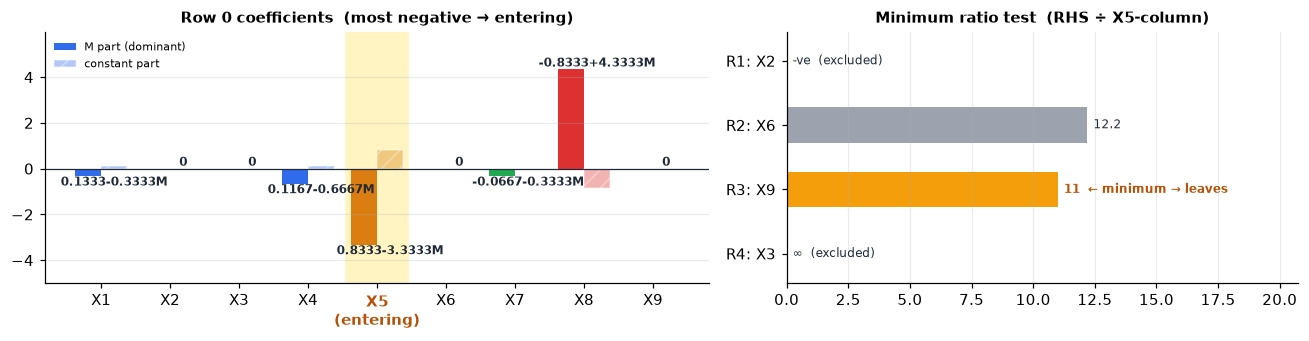

**Iteration 3 - scaling the pivot row.** Divide R3 by the pivot number 3.3333 → the pivot number becomes 1.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,X9,RHS,Ratio
Z,0,1,0.1333-0.3333M,0,0,0.1167-0.6667M,0.8333-3.3333M,0,-0.0667-0.3333M,-0.8333+4.3333M,0,-20.3333-36.6667M,
X2,1,0,0.6667,1,0,0.3333,-3.3333,0,-1.3333,3.3333,0,33.3333,-ve
X6,2,0,-0.0167,0,0,0.1167,0.3333,1,0.1133,-0.3333,0,4.0667,12.2
X9,3,0,0.1,0,0,0.2,1,0,0.1,-1,0.3,11,11
X3,4,0,0,0,1,0,0,0,1,0,0,30,∞


**Iteration 3 - eliminating X5 from the other rows** (to obtain 0 in every other row of the pivot column):  
• Add (-0.8333+3.3333M) × R3 to R0  
• Add 3.3333 × R3 to R1  
• Subtract 0.3333 × R3 from R2  
X5 replaced X9 in the basis.  Current Z = -29.5.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,X9,RHS
Z,0,1,0.05,0,0,-0.05,0,0,-0.15,M,-0.25+M,-29.5
X2,1,0,1,1,0,1,0,0,-1,0,1,70
X6,2,0,-0.05,0,0,0.05,0,1,0.08,0,-0.1,0.4
X5,3,0,0.1,0,0,0.2,1,0,0.1,-1,0.3,11
X3,4,0,0,0,1,0,0,0,1,0,0,30


**Iteration 4 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X7** - it has the largest (in absolute value) negative coefficient in row 0 (-0.15).  
• Minimum ratio test (RHS ÷ positive entries of the X7-column): R1: -ve, R2: 5, R3: 110, R4: 30.  
• **Leaving basic variable: X6** (row 2, smallest ratio). Pivot number = 0.08.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,X9,RHS,Ratio
Z,0,1,0.05,0,0,-0.05,0,0,-0.15,M,-0.25+M,-29.5,
X2,1,0,1,1,0,1,0,0,-1,0,1,70,-ve
X6,2,0,-0.05,0,0,0.05,0,1,0.08,0,-0.1,0.4,5
X5,3,0,0.1,0,0,0.2,1,0,0.1,-1,0.3,11,110
X3,4,0,0,0,1,0,0,0,1,0,0,30,30


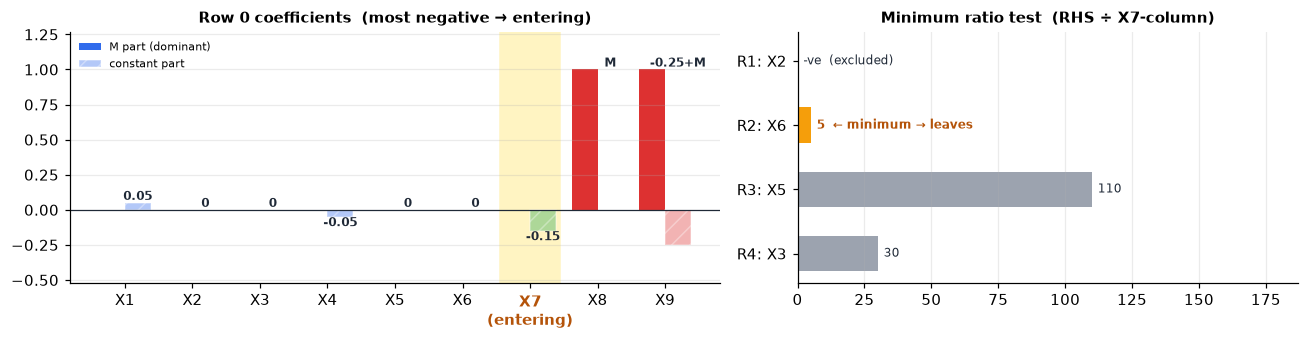

**Iteration 4 - scaling the pivot row.** Divide R2 by the pivot number 0.08 → the pivot number becomes 1.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,X9,RHS,Ratio
Z,0,1,0.05,0,0,-0.05,0,0,-0.15,M,-0.25+M,-29.5,
X2,1,0,1,1,0,1,0,0,-1,0,1,70,-ve
X6,2,0,-0.625,0,0,0.625,0,12.5,1,0,-1.25,5,5
X5,3,0,0.1,0,0,0.2,1,0,0.1,-1,0.3,11,110
X3,4,0,0,0,1,0,0,0,1,0,0,30,30


**Iteration 4 - eliminating X7 from the other rows** (to obtain 0 in every other row of the pivot column):  
• Add 0.15 × R2 to R0  
• Add 1 × R2 to R1  
• Subtract 0.1 × R2 from R3  
• Subtract 1 × R2 from R4  
X7 replaced X6 in the basis.  Current Z = -28.75.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,X9,RHS
Z,0,1,-0.0437,0,0,0.0437,0,1.875,0,M,-0.4375+M,-28.75
X2,1,0,0.375,1,0,1.625,0,12.5,0,0,-0.25,75
X7,2,0,-0.625,0,0,0.625,0,12.5,1,0,-1.25,5
X5,3,0,0.1625,0,0,0.1375,1,-1.25,0,-1,0.425,10.5
X3,4,0,0.625,0,1,-0.625,0,-12.5,0,0,1.25,25


**Iteration 5 - selecting variables.**  
• Is the current solution optimal? **No** - row 0 has at least one negative coefficient.  
• **Entering basic variable: X1** - it has the largest (in absolute value) negative coefficient in row 0 (-0.0437).  
• Minimum ratio test (RHS ÷ positive entries of the X1-column): R1: 200, R2: -ve, R3: 64.6154, R4: 40.  
• **Leaving basic variable: X3** (row 4, smallest ratio). Pivot number = 0.625.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,X9,RHS,Ratio
Z,0,1,-0.0437,0,0,0.0437,0,1.875,0,M,-0.4375+M,-28.75,
X2,1,0,0.375,1,0,1.625,0,12.5,0,0,-0.25,75,200
X7,2,0,-0.625,0,0,0.625,0,12.5,1,0,-1.25,5,-ve
X5,3,0,0.1625,0,0,0.1375,1,-1.25,0,-1,0.425,10.5,64.6154
X3,4,0,0.625,0,1,-0.625,0,-12.5,0,0,1.25,25,40


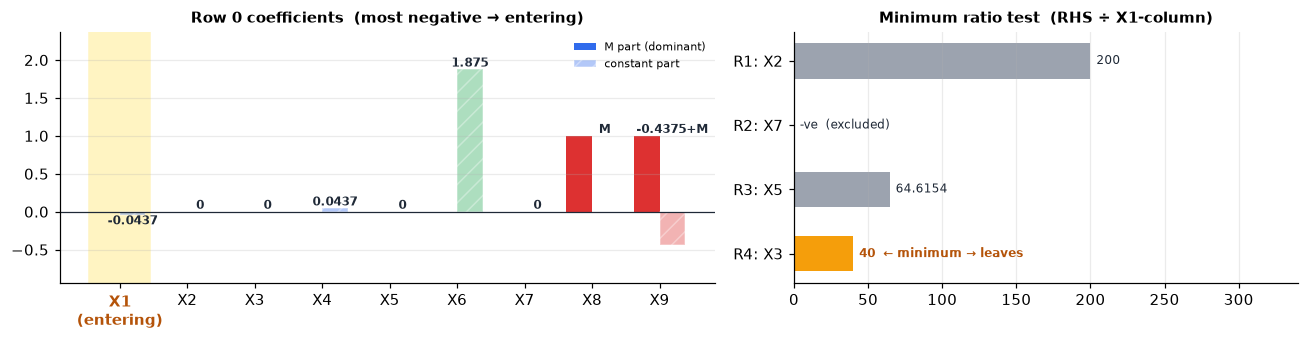

**Iteration 5 - scaling the pivot row.** Divide R4 by the pivot number 0.625 → the pivot number becomes 1.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,X9,RHS,Ratio
Z,0,1,-0.0437,0,0,0.0437,0,1.875,0,M,-0.4375+M,-28.75,
X2,1,0,0.375,1,0,1.625,0,12.5,0,0,-0.25,75,200
X7,2,0,-0.625,0,0,0.625,0,12.5,1,0,-1.25,5,-ve
X5,3,0,0.1625,0,0,0.1375,1,-1.25,0,-1,0.425,10.5,64.6154
X3,4,0,1,0,1.6,-1,0,-20,0,0,2,40,40


**Iteration 5 - eliminating X1 from the other rows** (to obtain 0 in every other row of the pivot column):  
• Add 0.0437 × R4 to R0  
• Subtract 0.375 × R4 from R1  
• Add 0.625 × R4 to R2  
• Subtract 0.1625 × R4 from R3  
X1 replaced X3 in the basis.  Current Z = -27.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,X9,RHS
Z,0,1,0,0,0.07,0,0,1,0,M,-0.35+M,-27
X2,1,0,0,1,-0.6,2,0,20,0,0,-1,60
X7,2,0,0,0,1,0,0,0,1,0,0,30
X5,3,0,0,0,-0.26,0.3,1,2,0,-1,0.1,4
X1,4,0,1,0,1.6,-1,0,-20,0,0,2,40


**Final check.**  
• Optimal: row 0 has no negative coefficients. Z* = 27 (converted back: Z = −Z′)  
• Alternative optima: non-basic X4 has a zero coefficient in row 0 - bringing it in changes the solution but not Z.

Basic,Eq.,Z,X1,X2,X3,X4,X5,X6,X7,X8,X9,RHS
Z,0,1,0,0,0.07,0,0,1,0,M,-0.35+M,-27
X2,1,0,0,1,-0.6,2,0,20,0,0,-1,60
X7,2,0,0,0,1,0,0,0,1,0,0,30
X5,3,0,0,0,-0.26,0.3,1,2,0,-1,0.1,4
X1,4,0,1,0,1.6,-1,0,-20,0,0,2,40


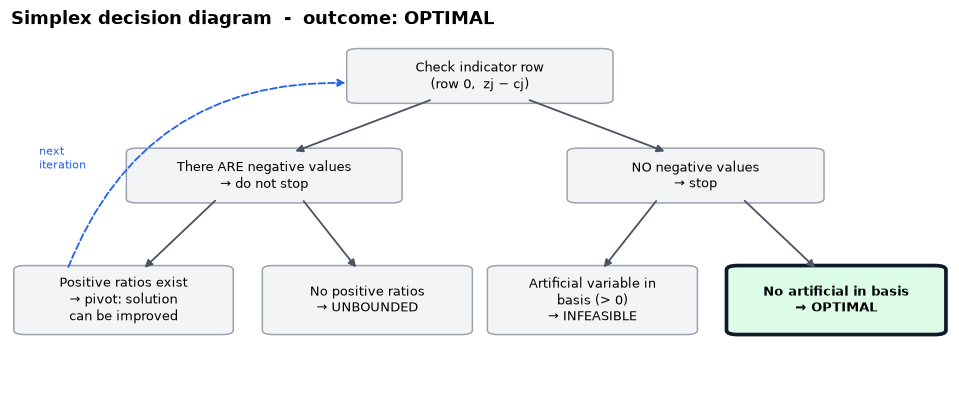

In [40]:
res_feed = solve_file("data/feed_blending_min.json", steps=False)
walkthrough(res_feed, charts=True)

### 10.3 Loading from CSV
The same Example 2 stored as a spreadsheet-friendly CSV gives the same answer:

In [41]:
r_csv = simplex(load_problem("data/ex2_tabular_simplex.csv"))
print(r_csv.status, "Z =", fnum(r_csv.z), {k: fnum(v) for k, v in r_csv.x_decision.items()})

optimal Z = 70 {'X1': '0', 'X2': '7'}


## 11. Batch: solve every file in `data/` and export all PDF reports

In [42]:
import glob
rows = []
for f in sorted(glob.glob(os.path.join(DATA_DIR, "*.json"))):
    r = simplex(load_problem(f))
    out = export_pdf_report(r)
    _, ok = compare_with_scipy(r)
    rows.append({"file": os.path.basename(f), "status": r.status, "Z*": fnum(r.z) if r.status == "optimal" else "-",
                 "iterations": r.iterations, "verified": "✔" if ok else "✘", "report": out})
summary = pd.DataFrame(rows); display(summary)

,file,status,Z*,iterations,verified,report
0,case_alternative_optima.json,optimal,10,1,✔,reports\case_alternative_optima_report.pdf
1,case_infeasible.json,infeasible,-,1,✔,reports\case_infeasible_report.pdf
2,case_minimization.json,optimal,25,2,✔,reports\case_minimization_report.pdf
3,case_unbounded.json,unbounded,-,2,✔,reports\case_unbounded_report.pdf
4,ex1_standard_form.json,optimal,60,3,✔,reports\ex1_standard_form_report.pdf
5,ex2_tabular_simplex.json,optimal,70,3,✔,reports\ex2_tabular_simplex_report.pdf
6,ex3_big_m.json,optimal,16,2,✔,reports\ex3_big_m_report.pdf
7,feed_blending_min.json,optimal,27,5,✔,reports\feed_blending_min_report.pdf
8,production_planning.json,optimal,1787.5,3,✔,reports\production_planning_report.pdf


## 12. Solve your own model
1. Copy any file in `data/` and edit it (or build an `LPProblem` directly in code).
2. Set `MY_FILE` below and run the cell. Options: `rule="bland"` (anti-cycling), `naming="typed"` (S/R names), `steps=False` (skip the long walkthrough), `report=False` (no PDF).

**Lecture Example 2 - Tabular Simplex**  
*Lecture slides 15-57. All <= constraints, slack variables give the starting basis. Three iterations to the optimum Z = 70.*

$$\begin{aligned}\text{Maximize}\quad & Z = 20X_{1} + 10X_{2} \\
\text{subject to}\quad & \\
& X_{1} - X_{2} \le 1 \qquad (\text{C1}) \\
& 3X_{1} + X_{2} \le 7 \qquad (\text{C2}) \\
& X_{1}, X_{2} \ge 0\end{aligned}$$

#### Transformation steps
1. **C1** (Type I, ≤): add slack **X3** ≥ 0 (unused resource, cost 0) → X3 is the starting basic variable of this row.
2. **C2** (Type I, ≤): add slack **X4** ≥ 0 (unused resource, cost 0) → X4 is the starting basic variable of this row.

#### Standard form$$\begin{aligned}\text{Maximize}\quad & Z = 20X_{1} + 10X_{2} \\
\text{subject to}\quad & \\
& X_{1} - X_{2} + X_{3} = 1 \qquad (\text{C1}) \\
& 3X_{1} + X_{2} + X_{4} = 7 \qquad (\text{C2}) \\
& X_{1}, X_{2}, X_{3}, X_{4} \ge 0\end{aligned}$$

Variable,Kind,Role,Objective coef.,Starts basic?
X1,decision,decision variable,20,
X2,decision,decision variable,10,
X3,slack,slack of C1,0,yes
X4,slack,slack of C2,0,yes


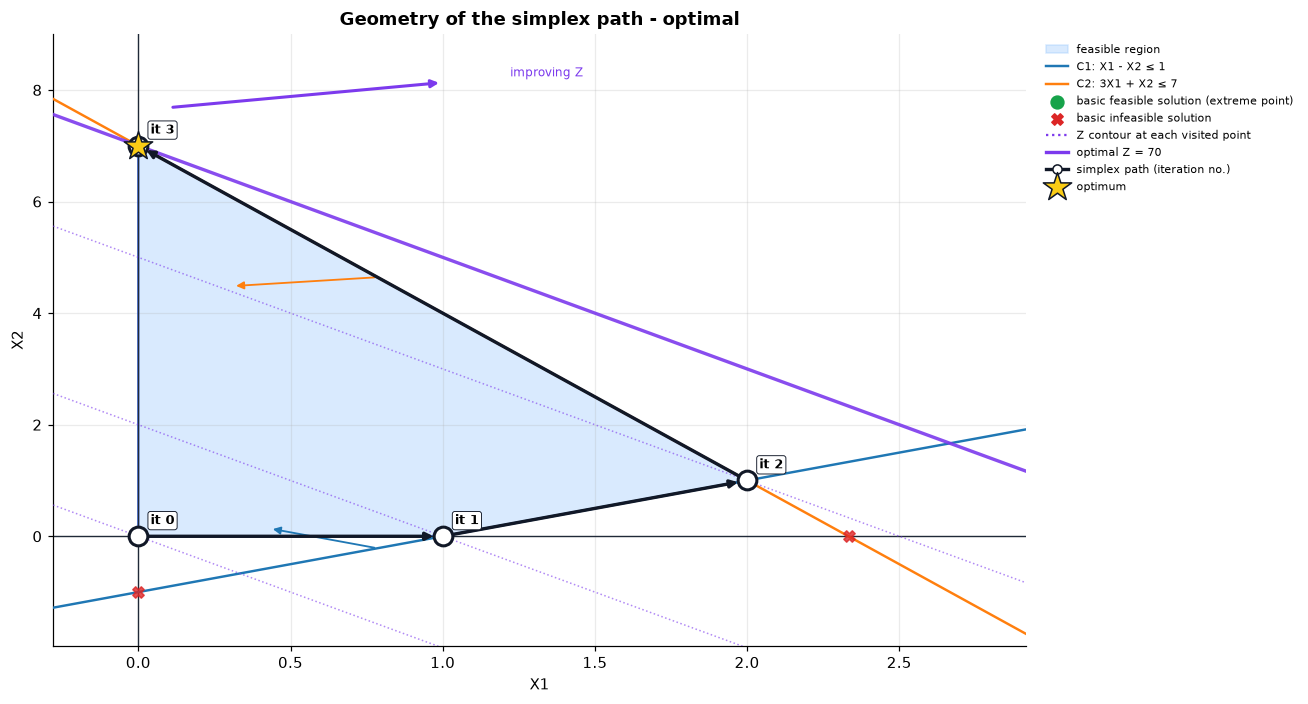

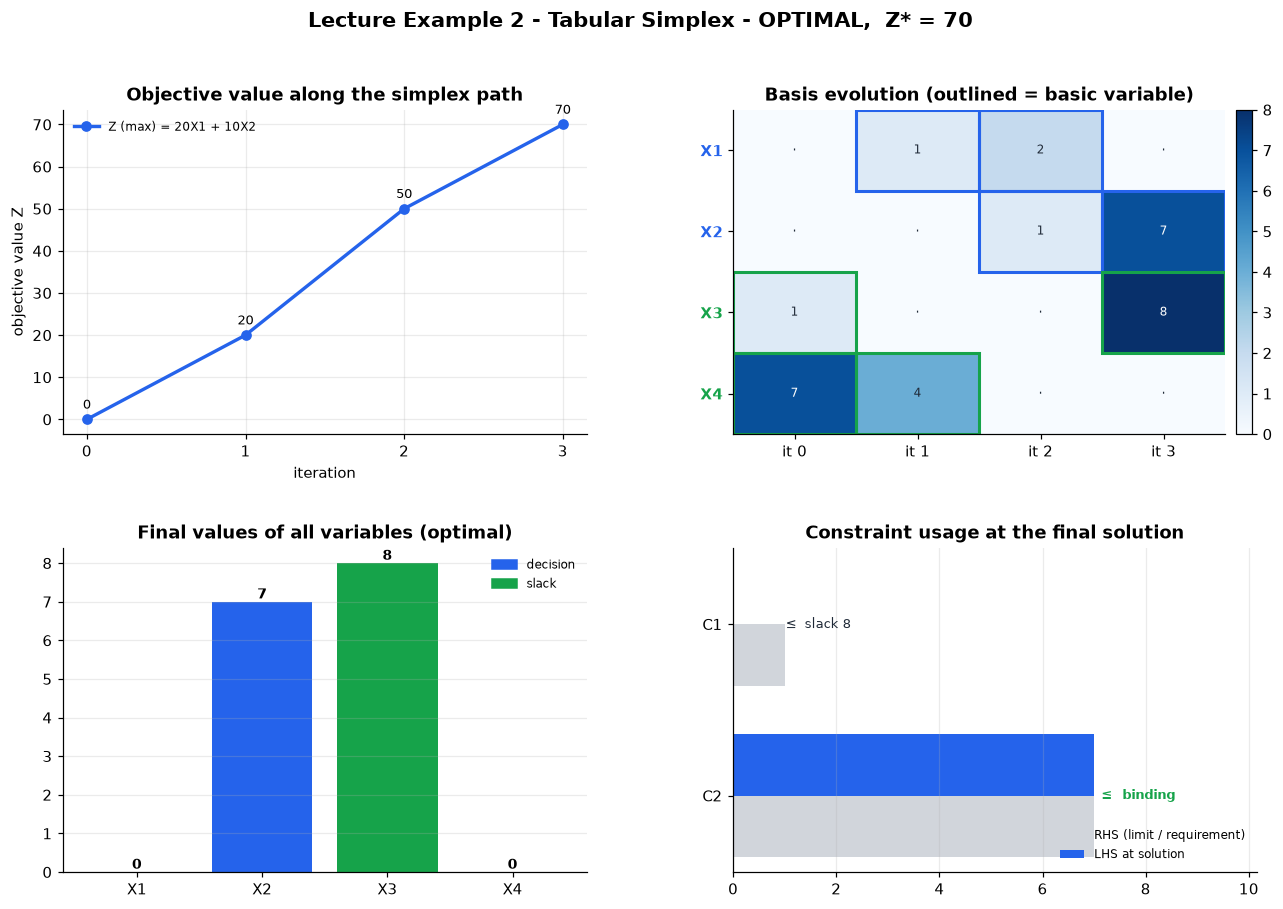

quantity,our tableau simplex,SciPy HiGHS
status,optimal,optimal
Z,70,70
X1,0,0
X2,7,7


> Optimal: row 0 has no negative coefficients. Z* = 70

📄 PDF report written to `reports\ex2_tabular_simplex_report.pdf`

In [43]:
MY_FILE = "data/ex2_tabular_simplex.json"
my_res = solve_file(MY_FILE, rule="dantzig", naming="indexed", steps=False, report=True)